In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
cd drive/MyDrive/Kai/envtest/

/content/drive/MyDrive/Kai/envtest


In [3]:

from preprocess_data import load_and_preprocess_data
stock_data, marco_df, industry_df = load_and_preprocess_data()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [4]:
len(stock_data['2330'].columns)

39

In [5]:
stock_data['2330'].columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA10', 'MA20',
       'MA30', 'MACD', 'MACDsignal', 'MACDhist', 'RSI14', 'OBV',
       'VolumeReturn', 'TurnoverReturn', 'SimpleReturn_Open',
       'SimpleReturn_High', 'SimpleReturn_Low', 'SimpleReturn_Close',
       'HistoricalVolatility', 'GARCHVolatility', 'date', 'post_count',
       'total_engagement', 'avg_sentiment', 'positive_posts', 'negative_posts',
       'neutral_posts', 'market_sentiment', 'content_volume',
       'sentiment_volatility', 'sentiment_ma3', 'sentiment_ma7',
       'sentiment_change', 'market_heat', 'heat_ma7', 'mentions_2330',
       'sentiment_2330'],
      dtype='object')

In [7]:
marco_df.columns

Index(['Date', 'CPI_logdiff', 'Core_CPI_logdiff', 'PPI_logdiff',
       'Industrial_Production_Index_logdiff', 'Retail_Sales_MoM_logdiff',
       'Inventory_Sales_Ratio_logdiff', 'M2_Money_Supply_logdiff',
       'USD_Index_logdiff', 'USDJPY_logdiff', 'USDCNY_logdiff',
       'Crude_Oil_Price_logdiff', 'Gold_Price_logdiff',
       'PPI_Electronic_Components_logdiff', 'Total_Vehicle_Sales_logdiff',
       'Durable_Goods_Orders_logdiff', 'Retail_Sales_Ex_Auto_logdiff',
       'Nonresidential_Investment_logdiff',
       'Initial_Jobless_Claims_log1p_diff'],
      dtype='object')

In [9]:
industry_df.columns

Index(['Date', 'SOXX_Semiconductor_ETF_pct_chg',
       'SOXX_Semiconductor_ETF_logdiff', 'SOXX_Semiconductor_ETF_diff',
       'SMH_Semiconductor_ETF_pct_chg', 'SMH_Semiconductor_ETF_logdiff',
       'SMH_Semiconductor_ETF_diff', 'Copper_Futures_pct_chg',
       'Copper_Futures_logdiff', 'Copper_Futures_diff',
       'WTI_Crude_Oil_pct_chg', 'WTI_Crude_Oil_logdiff', 'WTI_Crude_Oil_diff',
       'Brent_Crude_Oil_pct_chg', 'Brent_Crude_Oil_logdiff',
       'Brent_Crude_Oil_diff', 'Iron_Ore_62pct_pct_chg',
       'Iron_Ore_62pct_logdiff', 'Iron_Ore_62pct_diff',
       'Dry_Bulk_Shipping_ETF_pct_chg', 'Dry_Bulk_Shipping_ETF_logdiff',
       'Dry_Bulk_Shipping_ETF_diff', 'Global_Shipping_ETF_pct_chg',
       'Global_Shipping_ETF_logdiff', 'Global_Shipping_ETF_diff',
       'Global_Steel_ETF_pct_chg', 'Global_Steel_ETF_logdiff',
       'Global_Steel_ETF_diff', 'USD_TWD_pct_chg', 'USD_TWD_logdiff',
       'USD_TWD_diff', 'US_Dollar_Index_pct_chg', 'US_Dollar_Index_logdiff',
       'US_Dollar

In [ ]:
# stock_data['2330'].columns, marco_df.columns, industry_df.columns

# ENV

In [7]:
import pandas as pd
import numpy as np
import gym
from gym import spaces
from typing import Tuple, Dict, Optional
from sklearn.preprocessing import StandardScaler

class SingleStockEnv(gym.Env):
    def __init__(
        self,
        stock_df: pd.DataFrame,
        marco_df: pd.DataFrame,
        industry_df: pd.DataFrame,
        ticker: str,
        ticker_to_idx: Dict[str, int],
        start_date: Optional[pd.Timestamp] = None,
        end_date: Optional[pd.Timestamp] = None,
        sequence_length: int = 1,
        tax_rate: float = 0.003,
        buy_fee_rate: float = 0.001425,
        sell_fee_rate: float = 0.001425,
        penalty_config: Dict[str, float] = None,
        min_holding_days: int = 0,
        stop_loss_pct: float = 0.20,
        cooldown_days_after_force_sell: int = 0,
        take_profit_pct: Optional[float] = None,
        max_holding_days: Optional[int] = None,
    ):
        super().__init__()
        self.stock_df = stock_df.copy()
        self.marco_df = marco_df.copy()
        self.industry_df = industry_df.copy()
        self.ticker = ticker
        self.ticker_to_idx = ticker_to_idx
        self.start_date = start_date
        self.end_date = end_date
        self.sequence_length = sequence_length
        self.tax_rate = tax_rate
        self.buy_fee_rate = buy_fee_rate
        self.sell_fee_rate = sell_fee_rate
        self.min_holding_days = int(min_holding_days)
        self.stop_loss_pct = float(stop_loss_pct)
        self.cooldown_days_after_force_sell = int(cooldown_days_after_force_sell)
        self.cooldown_remaining = 0
        self.take_profit_pct = None if take_profit_pct is None else float(take_profit_pct)
        self.max_holding_days = None if max_holding_days is None else int(max_holding_days)

        default_penalties = {'trade_penalty': 0.0, 'large_loss_penalty': 0.0, 'overtrade_penalty': 0.0}
        self.penalty_config = penalty_config if penalty_config else default_penalties
        self.trade_penalty = self.penalty_config.get('trade_penalty', 0.0)
        self.large_loss_penalty = self.penalty_config.get('large_loss_penalty', 0.0)
        self.overtrade_penalty = self.penalty_config.get('overtrade_penalty', 0.0)

        # 觀測欄位定義（固定）
        self._stock_cols = [
            'Close', 'High', 'Low', 'Open', 'Volume', 'MA10', 'MA20', 'MA30', 'MACD',
            'MACD_signal', 'RSI14', 'OBV', 'post_count', 'avg_sentiment', 'avg_neg_sentiment',
            'avg_pos_sentiment', 'count_neg_sentiment', 'count_pos_sentiment'
        ]
        self._macro_cols = ['cpi_logdiff', 'ppi_logdiff', 'unemployment_rate', 'm1b_logdiff', 'm2_logdiff']
        self._industry_cols = ['taiex_logdiff', 'semiconductor_logdiff']
        self._position_cols = ['position', 'holding_days', 'unrealized_pnl', 'relative_taiex']

        # scaler
        self.stock_scaler = StandardScaler()
        self.macro_scaler = StandardScaler()
        self.industry_scaler = StandardScaler()

        # 對齊欄位
        self._align_columns()

        # 準備數據
        self._prepare_data()

        # 空間
        feature_dim = len(self._stock_cols) + len(self._macro_cols) + len(self._industry_cols) + len(self._position_cols) + len(self.ticker_to_idx)
        self.action_space = spaces.Discrete(3)  # 0: sell, 1: hold, 2: buy
        if self.sequence_length > 1:
            self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.sequence_length, feature_dim), dtype=np.float32)
        else:
            self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(feature_dim,), dtype=np.float32)

        # 狀態初始化
        self.current_step = 0
        self.position = 0
        self.entry_price = None  # raw price
        self.entry_date = None
        self.holding_days = 0
        self.cumulative_return = 1.0
        self.total_transaction_costs = 0.0
        self.total_tax_paid = 0.0
        self.total_fees_paid = 0.0
        self.transaction_count = 0
        self.step_returns = []
        self.trade_flags = []
        self.done = False
        self._close_idx = self._stock_cols.index('Close')

    def _ensure_date(self, df: pd.DataFrame, name: str) -> pd.DataFrame:
        if 'date' not in df.columns:
            if 'Date' in df.columns:
                df = df.rename(columns={'Date':'date'})
            elif isinstance(df.index, pd.DatetimeIndex):
                df = df.copy()
                df['date'] = df.index
            else:
                raise KeyError(f"{name} 缺少 date/Date 欄位")
        df['date'] = pd.to_datetime(df['date'])
        return df

    def _align_columns(self):
        # date
        self.stock_df = self._ensure_date(self.stock_df, 'stock_df')
        self.marco_df = self._ensure_date(self.marco_df, 'marco_df')
        self.industry_df = self._ensure_date(self.industry_df, 'industry_df')

        # stock 欄位
        s = self.stock_df
        if 'MACDsignal' in s.columns and 'MACD_signal' not in s.columns:
            s.rename(columns={'MACDsignal':'MACD_signal'}, inplace=True)

        # sentiment 補充
        if 'avg_pos_sentiment' not in s.columns:
            s['avg_pos_sentiment'] = np.clip(s.get('avg_sentiment', 0.0), 0, None)
        if 'avg_neg_sentiment' not in s.columns:
            s['avg_neg_sentiment'] = np.clip(-s.get('avg_sentiment', 0.0), 0, None)
        if 'count_pos_sentiment' not in s.columns:
            s['count_pos_sentiment'] = s.get('positive_posts', 0).fillna(0).astype(int)
        if 'count_neg_sentiment' not in s.columns:
            s['count_neg_sentiment'] = s.get('negative_posts', 0).fillna(0).astype(int)
        if 'post_count' not in s.columns:
            s['post_count'] = (s.get('positive_posts', 0).fillna(0).astype(int) +
                               s.get('negative_posts', 0).fillna(0).astype(int))

        # 缺欄補 0
        for col in self._stock_cols:
            if col not in s.columns:
                s[col] = 0.0

        # marco 欄位
        m = self.marco_df
        m.rename(columns={
            'CPI_logdiff':'cpi_logdiff',
            'PPI_logdiff':'ppi_logdiff',
            'M2_Money_Supply_logdiff':'m2_logdiff',
            'M1B_logdiff':'m1b_logdiff'
        }, inplace=True, errors='ignore')
        for col in self._macro_cols:
            if col not in m.columns:
                m[col] = 0.0

        # industry 欄位
        i = self.industry_df
        if 'TAIEX_logdiff' in i.columns and 'taiex_logdiff' not in i.columns:
            i.rename(columns={'TAIEX_logdiff':'taiex_logdiff'}, inplace=True)
        if 'PHLX_Semiconductor_Index_logdiff' in i.columns and 'semiconductor_logdiff' not in i.columns:
            i.rename(columns={'PHLX_Semiconductor_Index_logdiff':'semiconductor_logdiff'}, inplace=True)
        if 'semiconductor_logdiff' not in i.columns:
            alt = [c for c in i.columns if ('SOXX' in c or 'SMH' in c or 'Semiconductor' in c) and 'logdiff' in c]
            if alt:
                i['semiconductor_logdiff'] = i[alt[0]]
        for col in self._industry_cols:
            if col not in i.columns:
                i[col] = 0.0

    def _prepare_data(self):
        # 排序與填補
        self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
        self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
        self.industry_df = self.industry_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')

        # 對齊日期
        common_dates = sorted(set(self.stock_df['date']).intersection(self.marco_df['date']).intersection(self.industry_df['date']))
        if self.start_date or self.end_date:
            common_dates = [d for d in common_dates if (self.start_date is None or d >= self.start_date) and (self.end_date is None or d <= self.end_date)]
        self.common_dates = common_dates
        self.daily_data = {}

        # 擬合 scaler
        stock_data = []
        macro_data = []
        industry_data = []
        for d in common_dates:
            srow = self.stock_df.loc[self.stock_df['date'] == d]
            if not srow.empty:
                stock_data.append([float(srow.iloc[0].get(col, 0.0)) for col in self._stock_cols])
            mrow = self.marco_df.loc[self.marco_df['date'] == d]
            if not mrow.empty:
                macro_data.append([float(mrow.iloc[0].get(col, 0.0)) for col in self._macro_cols])
            irow = self.industry_df.loc[self.industry_df['date'] == d]
            if not irow.empty:
                industry_data.append([float(irow.iloc[0].get(col, 0.0)) for col in self._industry_cols])

        if stock_data:
            self.stock_scaler.fit(stock_data)
        if macro_data:
            self.macro_scaler.fit(macro_data)
        if industry_data:
            self.industry_scaler.fit(industry_data)

        # 準備每日 features
        for d in common_dates:
            self.daily_data[d] = self._get_daily_features(d)

    def _get_daily_features(self, date: pd.Timestamp) -> Dict:
        daily = {'date': date}

        srow_df = self.stock_df.loc[self.stock_df['date'] == date]
        if not srow_df.empty:
            srow = srow_df.iloc[0]
            stock_vec = [float(srow.get(c, 0.0)) for c in self._stock_cols]
            stock_vec = self.stock_scaler.transform([stock_vec])[0].tolist()
            raw_close = float(srow.get('Close', np.nan))
            raw_open = float(srow.get('Open', np.nan))
            raw_high = float(srow.get('High', np.nan))
            raw_low = float(srow.get('Low', np.nan))
            raw_volume = float(srow.get('Volume', np.nan))
        else:
            stock_vec = [0.0] * len(self._stock_cols)
            raw_close = raw_open = raw_high = raw_low = raw_volume = np.nan

        daily['stock_vec'] = stock_vec
        daily['raw_close'] = raw_close
        daily['raw_open'] = raw_open
        daily['raw_high'] = raw_high
        daily['raw_low'] = raw_low
        daily['raw_volume'] = raw_volume

        mrow_df = self.marco_df.loc[self.marco_df['date'] == date]
        if not mrow_df.empty:
            mrow = mrow_df.iloc[0]
            macro_vec = [float(mrow.get(c, 0.0)) for c in self._macro_cols]
            macro_vec = self.macro_scaler.transform([macro_vec])[0].tolist()
        else:
            macro_vec = [0.0] * len(self._macro_cols)
        daily['macro_vec'] = macro_vec

        irow_df = self.industry_df.loc[self.industry_df['date'] == date]
        if not irow_df.empty:
            irow = irow_df.iloc[0]
            industry_vec = [float(irow.get(c, 0.0)) for c in self._industry_cols]
            industry_vec = self.industry_scaler.transform([industry_vec])[0].tolist()
        else:
            industry_vec = [0.0] * len(self._industry_cols)
        daily['industry_vec'] = industry_vec

        return daily

    def _calculate_transaction_cost(self, price: float, is_buy: bool) -> float:
        fee = self.buy_fee_rate if is_buy else self.sell_fee_rate
        tax = 0.0 if is_buy else self.tax_rate
        return fee + tax  # 比例

    def _get_observation(self) -> np.ndarray:
        if self.current_step < self.sequence_length:
            states = [self.daily_data[self.common_dates[0]] for _ in range(self.sequence_length - self.current_step)]
            states += [self.daily_data[self.common_dates[i]] for i in range(self.current_step + 1)]
        else:
            states = [self.daily_data[self.common_dates[i]] for i in range(self.current_step - self.sequence_length + 1, self.current_step + 1)]

        obs_list = []
        for st in states:
            raw_close = st.get('raw_close', np.nan)
            if self.position == 1 and self.entry_price and np.isfinite(raw_close):
                unrealized = (raw_close - self.entry_price) / self.entry_price
            else:
                unrealized = 0.0
            position_vec = [
                float(self.position),
                float(self.holding_days),
                float(unrealized),
                st['industry_vec'][0] if len(st['industry_vec']) > 0 else 0.0
            ]
            one_hot = [0.0] * len(self.ticker_to_idx)
            one_hot[self.ticker_to_idx[self.ticker]] = 1.0

            vec = st['stock_vec'] + st['macro_vec'] + st['industry_vec'] + position_vec + one_hot
            obs_list.append(vec)

        if self.sequence_length > 1:
            return np.array(obs_list, dtype=np.float32)
        return np.array(obs_list[-1], dtype=np.float32)

    def reset(self) -> np.ndarray:
        self.current_step = 0
        self.position = 0
        self.entry_price = None
        self.entry_date = None
        self.holding_days = 0
        self.cumulative_return = 1.0
        self.total_transaction_costs = 0.0
        self.total_tax_paid = 0.0
        self.total_fees_paid = 0.0
        self.transaction_count = 0
        self.step_returns = []
        self.trade_flags = []
        self.done = False
        self.cooldown_remaining = 0
        return self._get_observation()

    def _realized_pnl_ratio(self, exit_price: float) -> float:
        if self.entry_price is None or self.entry_price <= 0 or not np.isfinite(exit_price):
            return 0.0
        return float((exit_price - self.entry_price) / self.entry_price)

    def step(self, action: int) -> Tuple[np.ndarray, float, bool, Dict]:
        if self.current_step >= len(self.common_dates) - 1:
            self.done = True
            return self._get_observation(), 0.0, self.done, {}

        execution_date = self.common_dates[self.current_step]
        observation_date = self.common_dates[self.current_step + 1]
        exec_data = self.daily_data[execution_date]
        next_data = self.daily_data[observation_date]

        reward = 0.0
        step_ret = 0.0  # 平倉結算制：持有期間不計即時報酬
        total_cost = 0.0
        action_executed = False
        traded_flag = 0
        is_forced_sell = False
        blocked_by_cooldown = False

        exec_raw = exec_data.get('raw_close', np.nan)
        next_raw = next_data.get('raw_close', np.nan)

        event = "hold"
        event_price = None
        realized_pnl = None  # 只有在賣出/強制賣出時計算

        # 觸發停損/停利/最大持有天數的強制賣出（先於一般動作）
        if self.position == 1 and np.isfinite(exec_raw) and self.entry_price is not None and self.entry_price > 0:
            dd = (exec_raw - self.entry_price) / self.entry_price
            trigger_force = False
            reason = None

            if dd <= -self.stop_loss_pct:
                trigger_force = True
                reason = "stop_loss"
            if (not trigger_force) and (self.take_profit_pct is not None) and (dd >= self.take_profit_pct):
                trigger_force = True
                reason = "take_profit"
            if (not trigger_force) and (self.max_holding_days is not None) and (self.holding_days >= self.max_holding_days):
                trigger_force = True
                reason = "max_holding"

            if trigger_force:
                # 平倉收益（一次性）
                pnl = self._realized_pnl_ratio(exec_raw)
                reward += pnl
                self.cumulative_return *= (1 + pnl)
                realized_pnl = pnl

                # 交易成本（賣出）
                cost = self._calculate_transaction_cost(exec_raw, is_buy=False)
                reward -= cost
                total_cost += cost
                self.cumulative_return *= (1 - cost)
                self.total_transaction_costs += cost
                self.total_tax_paid += self.tax_rate
                self.total_fees_paid += self.sell_fee_rate

                # 狀態更新
                self.position = 0
                self.entry_price = None
                self.entry_date = None
                self.holding_days = 0
                self.transaction_count += 1

                # 冷卻期
                self.cooldown_remaining = self.cooldown_days_after_force_sell

                action_executed = True
                traded_flag = 1
                is_forced_sell = True
                event = "force_sell" if reason == "stop_loss" else ("tp_sell" if reason == "take_profit" else "time_sell")
                event_price = float(exec_raw)

        # 若沒有被強制賣出，才執行一般動作
        if not action_executed:
            # 賣出（需滿足最小持有天數）
            if action == 0 and self.position == 1 and np.isfinite(exec_raw):
                if self.holding_days >= self.min_holding_days:
                    # 平倉收益
                    pnl = self._realized_pnl_ratio(exec_raw)
                    reward += pnl
                    self.cumulative_return *= (1 + pnl)
                    realized_pnl = pnl

                    # 賣出成本
                    cost = self._calculate_transaction_cost(exec_raw, is_buy=False)
                    reward -= cost
                    total_cost += cost
                    self.cumulative_return *= (1 - cost)
                    self.total_transaction_costs += cost
                    self.total_tax_paid += self.tax_rate
                    self.total_fees_paid += self.sell_fee_rate

                    self.position = 0
                    self.entry_price = None
                    self.entry_date = None
                    self.holding_days = 0
                    self.transaction_count += 1

                    action_executed = True
                    traded_flag = 1
                    event = "sell"
                    event_price = float(exec_raw)
                else:
                    event = "hold"

            # 買入（冷卻期禁止）
            elif action == 2 and self.position == 0 and np.isfinite(exec_raw):
                if self.cooldown_remaining <= 0:
                    # 買入成本
                    cost = self._calculate_transaction_cost(exec_raw, is_buy=True)
                    reward -= cost
                    total_cost += cost
                    self.cumulative_return *= (1 - cost)
                    self.total_transaction_costs += cost
                    self.total_tax_paid += 0.0
                    self.total_fees_paid += self.buy_fee_rate

                    self.position = 1
                    self.entry_price = exec_raw
                    self.entry_date = execution_date
                    self.holding_days = 0
                    self.transaction_count += 1

                    action_executed = True
                    traded_flag = 1
                    event = "buy"
                    event_price = float(exec_raw)
                else:
                    blocked_by_cooldown = True
                    event = "hold"

            else:
                event = "hold"

        # 更新持有天數與冷卻天數
        if self.position == 1:
            self.holding_days += 1
        if self.cooldown_remaining > 0:
            self.cooldown_remaining -= 1

        # 懲罰：強制賣出與被冷卻阻擋的買入不算 trade_penalty
        if self.trade_penalty > 0 and action_executed and not is_forced_sell:
            reward -= self.trade_penalty
        # 平倉結算制下，large_loss_penalty 只在實現虧損很大時處罰（可調整閾值）
        if self.large_loss_penalty > 0 and realized_pnl is not None and realized_pnl < -0.05:
            reward -= self.large_loss_penalty
        if self.overtrade_penalty > 0:
            recent_trades = sum(self.trade_flags[-5:]) + traded_flag
            if recent_trades > 2:
                reward -= self.overtrade_penalty * (recent_trades - 2)

        self.step_returns.append(step_ret)
        self.trade_flags.append(traded_flag)
        self.current_step += 1
        if self.current_step >= (len(self.common_dates) - 2):
            self.done = True

        info = {
            'ticker': self.ticker,
            'position': self.position,
            'step_return': step_ret,  # 逐步為 0（平倉制）
            'cumulative_return': self.cumulative_return,
            'transaction_cost': total_cost,
            'action': action,
            'observation_date': observation_date,
            'reward': float(reward),
            'holding_days': self.holding_days,
            'equity': self.cumulative_return,
            'roi': self.cumulative_return - 1.0,
            'raw_close': float(exec_raw) if np.isfinite(exec_raw) else None,
            'event': event,
            'event_price': event_price,
            'realized_pnl': realized_pnl,                 # 新增：平倉當筆的實現盈虧（比例）
            'cooldown_remaining': self.cooldown_remaining, # 新增：剩餘冷卻天數
            'blocked_by_cooldown': blocked_by_cooldown     # 新增：當步買入是否被冷卻阻擋
        }
        return self._get_observation(), float(reward), self.done, info

    def render(self, mode='human'):
        print(f"Step: {self.current_step}, Ticker: {self.ticker}, Position: {self.position}, "
              f"Cumulative Return: {self.cumulative_return:.4f}, ROI: {self.cumulative_return - 1.0:.4f}, "
              f"Transaction Count: {self.transaction_count}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Test Env

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from preprocess_data import load_and_preprocess_data

def check_missing_values(stock_data: dict, marco_df: pd.DataFrame, industry_df: pd.DataFrame) -> bool:
    required_stock_cols = [
        'date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA10', 'MA20', 'MA30', 'MACD',
        'MACD_signal', 'RSI14', 'OBV', 'post_count', 'avg_sentiment',
        'avg_neg_sentiment', 'avg_pos_sentiment', 'count_neg_sentiment', 'count_pos_sentiment'
    ]
    required_macro_cols = ['date', 'cpi_logdiff', 'ppi_logdiff', 'unemployment_rate', 'm1b_logdiff', 'm2_logdiff']
    required_industry_cols = ['date', 'taiex_logdiff', 'semiconductor_logdiff']

    all_valid = True

    for ticker, df in stock_data.items():
        if 'Date' in df.columns and 'date' not in df.columns:
            df.rename(columns={'Date': 'date'}, inplace=True)

        # 統一 MACD 標記
        if 'MACDsignal' in df.columns and 'MACD_signal' not in df.columns:
            df.rename(columns={'MACDsignal': 'MACD_signal'}, inplace=True)

        # sentiment 補齊
        if 'avg_pos_sentiment' not in df.columns:
            df['avg_pos_sentiment'] = 0.0
        if 'avg_neg_sentiment' not in df.columns:
            df['avg_neg_sentiment'] = 0.0
        if 'count_pos_sentiment' not in df.columns:
            df['count_pos_sentiment'] = df.get('positive_posts', pd.Series(0, index=df.index))
        if 'count_neg_sentiment' not in df.columns:
            df['count_neg_sentiment'] = df.get('negative_posts', pd.Series(0, index=df.index))

        stock_data[ticker] = df

        if not isinstance(df, pd.DataFrame):
            print(f"錯誤：{ticker} 的 stock_df 不是 DataFrame")
            all_valid = False
            continue
        if not all(col in df.columns for col in required_stock_cols):
            missing_cols = [c for c in required_stock_cols if c not in df.columns]
            print(f"錯誤：{ticker} 的 stock_df 缺少必要欄位：{missing_cols}")
            all_valid = False
            continue
        missing = df[required_stock_cols].isnull().sum()
        if missing.sum() > 0:
            print(f"錯誤：{ticker} 的 stock_df 包含缺失值：\n{missing[missing > 0]}")
            all_valid = False
        else:
            print(f"{ticker} 的 stock_df 無缺失值")

    if not isinstance(marco_df, pd.DataFrame):
        print("錯誤：marco_df 不是 DataFrame")
        all_valid = False
    else:
        if 'Date' in marco_df.columns and 'date' not in marco_df.columns:
            marco_df.rename(columns={'Date': 'date'}, inplace=True)
        marco_df.rename(columns={
            'CPI_logdiff': 'cpi_logdiff',
            'PPI_logdiff': 'ppi_logdiff',
            'M2_Money_Supply_logdiff': 'm2_logdiff',
            'M1B_logdiff': 'm1b_logdiff'
        }, inplace=True, errors='ignore')

        if not all(col in marco_df.columns for col in required_macro_cols):
            missing = [c for c in required_macro_cols if c not in marco_df.columns]
            print(f"錯誤：marco_df 缺少必要欄位：{missing}")
            all_valid = False
        else:
            missing = marco_df[required_macro_cols].isnull().sum()
            if missing.sum() > 0:
                print(f"錯誤：marco_df 包含缺失值：\n{missing[missing > 0]}")
                all_valid = False
            else:
                print("marco_df 無缺失值")

    if not isinstance(industry_df, pd.DataFrame):
        print("錯誤：industry_df 不是 DataFrame")
        all_valid = False
    else:
        if 'Date' in industry_df.columns and 'date' not in industry_df.columns:
            industry_df.rename(columns={'Date': 'date'}, inplace=True)
        if not all(col in industry_df.columns for col in required_industry_cols):
            missing = [c for c in required_industry_cols if c not in industry_df.columns]
            print(f"錯誤：industry_df 缺少必要欄位：{missing}")
            all_valid = False
        else:
            missing = industry_df[required_industry_cols].isnull().sum()
            if missing.sum() > 0:
                print(f"錯誤：industry_df 包含缺失值：\n{missing[missing > 0]}")
                all_valid = False
            else:
                print("industry_df 無缺失值")

    return all_valid

def generate_test_data(start_date='2023-01-01', end_date='2023-12-31'):
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    num_days = len(dates)
    initial_price = 100.0
    mu = 0.0002
    sigma = 0.02
    prices = [initial_price]
    for _ in range(num_days - 1):
        drift = mu - 0.5 * sigma**2
        shock = sigma * np.random.randn()
        price = prices[-1] * np.exp(drift + shock)
        prices.append(max(price, 1.0))
    prices = np.array(prices)

    stock_df = pd.DataFrame({
        'date': dates,
        'Close': prices,
        'High': prices * 1.05 + np.random.rand(num_days) * 2,
        'Low': prices * 0.95 - np.random.rand(num_days) * 2,
        'Open': prices + np.random.randn(num_days) * 0.5,
        'Volume': np.random.rand(num_days) * 1_000_000 + 500_000,
        'MA10': pd.Series(prices).rolling(10).mean().ffill().bfill(),
        'MA20': pd.Series(prices).rolling(20).mean().ffill().bfill(),
        'MA30': pd.Series(prices).rolling(30).mean().ffill().bfill(),
        'MACD': np.random.rand(num_days) * 2 - 1,
        'MACD_signal': np.random.rand(num_days) * 2 - 1,  # 統一命名
        'RSI14': np.random.rand(num_days) * 100,
        'OBV': np.cumsum(np.random.randn(num_days) * 1_000_000),
        'post_count': np.random.randint(0, 100, num_days),
        'avg_sentiment': np.random.uniform(-1, 1, num_days),
        'avg_pos_sentiment': np.random.uniform(0, 1, num_days),
        'avg_neg_sentiment': np.random.uniform(0, 1, num_days),
        'count_pos_sentiment': np.random.randint(0, 50, num_days),
        'count_neg_sentiment': np.random.randint(0, 50, num_days),
    })
    marco_df = pd.DataFrame({
        'date': dates,
        'cpi_logdiff': np.random.randn(num_days) * 0.01,
        'ppi_logdiff': np.random.randn(num_days) * 0.01,
        'unemployment_rate': np.random.uniform(0, 0.1, num_days),
        'm1b_logdiff': np.random.randn(num_days) * 0.01,
        'm2_logdiff': np.random.randn(num_days) * 0.01
    })
    industry_df = pd.DataFrame({
        'date': dates,
        'taiex_logdiff': np.random.randn(num_days) * 0.01,
        'semiconductor_logdiff': np.random.randn(num_days) * 0.01
    })
    return stock_df, marco_df, industry_df

def plot_equity_and_roi_curve(env, results):
    equity_curve = [info['equity'] for info in results]
    roi_curve = [info['roi'] for info in results]
    dates = [info['observation_date'] for info in results]

    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(dates, equity_curve, label=f"{env.ticker} Cumulative Return", color="blue")
    plt.title(f"Cumulative Return Curve for {env.ticker}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)

    plt.subplot(2, 1, 2)
    plt.plot(dates, roi_curve, label=f"{env.ticker} ROI", color="green")
    plt.title(f"ROI Curve for {env.ticker}")
    plt.xlabel("Date")
    plt.ylabel("ROI")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

def test_env(stock_data: dict, marco_df: pd.DataFrame, industry_df: pd.DataFrame):
    # 欄位對齊與缺失檢查
    if not check_missing_values(stock_data, marco_df, industry_df):
        print("警告：檢測到缺失值或格式錯誤，改用模擬數據")
        stock_df_gen, marco_df, industry_df = generate_test_data()
        stock_data = {ticker: stock_df_gen.copy() for ticker in stock_data.keys()}

    # 確保日期格式
    marco_df['date'] = pd.to_datetime(marco_df['date'])
    industry_df['date'] = pd.to_datetime(industry_df['date'])
    for ticker in stock_data:
        stock_data[ticker]['date'] = pd.to_datetime(stock_data[ticker]['date'])

    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(stock_data.keys())}

    results_all = {}
    mdd_all = {}

    for ticker, stock_df in stock_data.items():
        print(f"\n=== 測試股票 {ticker} ===")
        env = SingleStockEnv(
            stock_df=stock_df,
            marco_df=marco_df,
            industry_df=industry_df,
            ticker=ticker,
            ticker_to_idx=ticker_to_idx,
            start_date=pd.Timestamp('2023-01-01'),
            end_date=pd.Timestamp('2023-03-01'),
            sequence_length=1,
            penalty_config={'trade_penalty': 0.001, 'large_loss_penalty': 0.005}
        )

        results = []
        state = env.reset()
        print("初始狀態:")
        env.render()

        while not env.done:
            action = env.action_space.sample()
            next_state, reward, done, info = env.step(action)
            results.append(info)
            print(f"Step {env.current_step}: Action={info['action']}, Position={info['position']}, "
                  f"Cumulative Return={info['cumulative_return']:.4f}, ROI={info['roi']:.4f}, "
                  f"Reward={info['reward']:.4f}")
            state = next_state

        print("\n最終狀態:")
        env.render()

        plot_equity_and_roi_curve(env, results)

        def calculate_mdd(equity_curve):
            equity = np.array(equity_curve)
            peak = np.maximum.accumulate(equity)
            drawdown = (peak - equity) / peak
            return np.max(drawdown) if len(drawdown) > 0 else 0.0
        mdd = calculate_mdd([info['equity'] for info in results])

        final_return = results[-1]['cumulative_return']
        final_roi = results[-1]['roi']
        total_trades = env.transaction_count
        total_costs = env.total_transaction_costs
        print(f"\n統計信息 ({ticker}):")
        print(f"最終累積報酬: {final_return:.4f}")
        print(f"最終 ROI: {final_roi:.4f}")
        print(f"總交易次數: {total_trades}")
        print(f"總交易成本比例: {total_costs:.6f}")
        print(f"最大回撤 (MDD): {mdd:.4f}")

        results_all[ticker] = results
        mdd_all[ticker] = mdd

    return results_all, mdd_all

# # 加載真實數據
# stock_data, marco_df, industry_df = load_and_preprocess_data()
# # 檢查缺失值並運行測試
# results_all, mdd_all = test_env(stock_data, marco_df, industry_df)

# LSTM agent

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
from collections import deque
import gym
from gym import spaces
from typing import Tuple, Dict, Optional
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import os
from datetime import datetime
import math

# ======================
# NoisyNet（可選）層
# ======================
class NoisyLinear(nn.Module):
    """
    Factorized Gaussian NoisyNet (Fortunato et al., 2018)
    用於取代 epsilon-greedy 的參數化探索。
    """
    def __init__(self, in_features, out_features, sigma0=0.5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.mu_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.sigma_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.mu_bias = nn.Parameter(torch.empty(out_features))
        self.sigma_bias = nn.Parameter(torch.empty(out_features))

        self.register_buffer('eps_weight_in', torch.empty(1, in_features))
        self.register_buffer('eps_weight_out', torch.empty(out_features, 1))
        self.register_buffer('eps_bias', torch.empty(out_features))

        self.reset_parameters(sigma0)

    @staticmethod
    def f(x):
        return torch.sign(x) * torch.sqrt(torch.abs(x))

    def reset_parameters(self, sigma0):
        mu_range = 1 / math.sqrt(self.in_features)
        self.mu_weight.data.uniform_(-mu_range, mu_range)
        self.mu_bias.data.uniform_(-mu_range, mu_range)

        # 推導自 factorized gaussian，初始化與 sigma0/in_features 有關
        self.sigma_weight.data.fill_(sigma0 / math.sqrt(self.in_features))
        self.sigma_bias.data.fill_(sigma0 / math.sqrt(self.in_features))

    def forward(self, x):
        # 重新採樣雜訊
        self.eps_weight_in.normal_()
        self.eps_weight_out.normal_()
        self.eps_bias.normal_()

        eps_w = self.f(self.eps_weight_out) @ self.f(self.eps_weight_in)
        weight = self.mu_weight + self.sigma_weight * eps_w
        bias = self.mu_bias + self.sigma_bias * self.f(self.eps_bias)

        return F.linear(x, weight, bias)


# ======================
# LSTM Network
# ======================
class LSTMNetwork(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        num_layers: int,
        output_size: int,
        dropout: float = 0.2,
        use_noisy: bool = False
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )

        self.dropout = nn.Dropout(dropout)

        # 只降一次維度，避免過度瓶頸
        fc_hidden = hidden_size // 2

        Linear = NoisyLinear if use_noisy else nn.Linear
        self.fc1 = Linear(hidden_size, fc_hidden)
        self.ln1 = nn.LayerNorm(fc_hidden)
        self.fc_out = Linear(fc_hidden, output_size)

        self.use_noisy = use_noisy

    def forward(self, x, hc: Optional[Tuple[torch.Tensor, torch.Tensor]] = None):
        """
        x: (B, S, F)
        hc: (h0, c0) where each is (num_layers, B, hidden_size) or None
        return:
          q_values: (B, action_dim)
          (h, c): latest hidden state tuple
        """
        # LSTM
        if hc is None:
            lstm_out, (h, c) = self.lstm(x)
        else:
            lstm_out, (h, c) = self.lstm(x, hc)

        last_output = lstm_out[:, -1, :]  # 取最後一個時間步
        z = self.dropout(last_output)

        z = self.fc1(z)
        z = self.ln1(z)
        z = F.relu(z)
        z = self.dropout(z)

        q_values = self.fc_out(z)
        return q_values, (h, c)


# ======================
# Replay Buffer
# ======================
class ReplayBuffer:
    def __init__(self, capacity_episodes: int, chunk_len: int, seq_len: int, feature_dim: int):
        self.capacity = capacity_episodes
        self.chunk_len = chunk_len
        self.seq_len = seq_len
        self.feature_dim = feature_dim
        self.episodes = []
        self.current_episode = None

    def start_episode(self):
        self.current_episode = {'states': [], 'actions': [], 'rewards': [], 'dones': []}

    def _ensure_shape(self, state: np.ndarray) -> np.ndarray:
        # state 可能是 (F,), (S,F), (1,S,F), (S,) 等，統一成 (S,F)
        s = np.asarray(state, dtype=np.float32)
        if s.ndim == 1:
            # (F,) -> (1,F)
            s = s[np.newaxis, :]
        elif s.ndim == 3 and s.shape[0] == 1:
            # (1,S,F) -> (S,F)
            s = s[0]
        # 現在期望 (S,F)
        if s.ndim != 2:
            raise ValueError(f"State must be 2D (S,F), got shape={s.shape}")
        # 若窗口長度不符，進行 pad 或裁切（左側 pad）
        S, F = s.shape
        if F != self.feature_dim:
            raise ValueError(f"Feature dim mismatch: got F={F}, expected {self.feature_dim}. Shape={s.shape}")
        if S < self.seq_len:
            pad_count = self.seq_len - S
            pad = np.repeat(s[:1, :], pad_count, axis=0)  # 用第一步重複填充
            s = np.concatenate([pad, s], axis=0)
        elif S > self.seq_len:
            s = s[-self.seq_len:, :]  # 取最近 seq_len 步
        return s

    def push_step(self, state, action, reward, done):
        if self.current_episode is None:
            self.start_episode()

        if isinstance(state, torch.Tensor):
            state = state.detach().cpu().numpy()
        s = self._ensure_shape(state)  # 強制為 (S,F)

        self.current_episode['states'].append(s)
        self.current_episode['actions'].append(int(action))
        self.current_episode['rewards'].append(float(reward))
        self.current_episode['dones'].append(bool(done))

        if done:
            self.end_episode()

    def end_episode(self):
        if self.current_episode is None:
            return
        T = len(self.current_episode['states'])
        if T >= self.chunk_len + 1:
            self.episodes.append(self.current_episode)
        while len(self.episodes) > self.capacity:
            self.episodes.pop(0)
        self.current_episode = None

    def __len__(self):
        total = 0
        for ep in self.episodes:
            T = len(ep['states'])
            total += max(0, T - self.chunk_len + 1)
        return total

    def sample(self, batch_size):
        candidates = []
        for ep_idx, ep in enumerate(self.episodes):
            T = len(ep['states'])
            for start in range(0, T - self.chunk_len):
                candidates.append((ep_idx, start))

        if len(candidates) <= batch_size:
            batch_idx = candidates
        else:
            import random
            batch_idx = random.sample(candidates, batch_size)

        states_batch, actions_batch, rewards_batch, next_states_batch, dones_batch = [], [], [], [], []
        for (ep_idx, start) in batch_idx:
            ep = self.episodes[ep_idx]
            end = start + self.chunk_len

            states_chunk = ep['states'][start:end]              # K 個 (S,F)
            next_states_chunk = ep['states'][start+1:end+1]     # K 個 (S,F)
            actions_chunk = ep['actions'][start:end]
            rewards_chunk = ep['rewards'][start:end]
            dones_chunk = ep['dones'][start:end]

            # 這裡 states_chunk/next_states_chunk 形狀一致，直接 stack
            states_chunk = np.stack(states_chunk, axis=0)           # (K,S,F)
            next_states_chunk = np.stack(next_states_chunk, axis=0) # (K,S,F)

            states_batch.append(states_chunk)
            next_states_batch.append(next_states_chunk)
            actions_batch.append(np.asarray(actions_chunk, dtype=np.int64))
            rewards_batch.append(np.asarray(rewards_chunk, dtype=np.float32))
            dones_batch.append(np.asarray(dones_chunk, dtype=bool))

        states_batch = torch.from_numpy(np.stack(states_batch, axis=0))          # (B,K,S,F)
        next_states_batch = torch.from_numpy(np.stack(next_states_batch, axis=0))# (B,K,S,F)
        actions_batch = torch.from_numpy(np.stack(actions_batch, axis=0))        # (B,K)
        rewards_batch = torch.from_numpy(np.stack(rewards_batch, axis=0))        # (B,K)
        dones_batch = torch.from_numpy(np.stack(dones_batch, axis=0))            # (B,K)
        return states_batch, actions_batch, rewards_batch, next_states_batch, dones_batch


# ======================
# LSTM DQN Agent
# ======================
class LSTMAgent:
    def __init__(
        self,
        state_size: int,
        action_size: int,
        sequence_length: int = 60,     # 單一 state 內的時間窗 S（與 env 對齊）
        hidden_size: int = 256,
        num_layers: int = 2,
        learning_rate: float = 1e-4,
        batch_size: int = 32,
        memory_size: int = 500,
        chunk_len: int = 8,            # 截斷 BPTT 的步數（sample chunk 長度）
        gamma: float = 0.99,
        epsilon: float = 1.0,
        epsilon_min: float = 0.01,
        epsilon_decay: float = 0.9999,
        target_update_freq: int = 1000,
        device: Optional[str] = None,
        use_noisy: bool = False,
        reset_epsilon_each_episode: bool = False,
        epsilon_reset_value: float = 0.2,
    ):
        self.state_size = state_size
        self.action_size = action_size
        self.sequence_length = sequence_length
        self.batch_size = batch_size
        self.gamma = gamma

        self.use_noisy = use_noisy
        self.reset_epsilon_each_episode = reset_epsilon_each_episode
        self.epsilon_reset_value = epsilon_reset_value

        self.epsilon = 0.0 if use_noisy else epsilon
        self.epsilon_min = 0.0 if use_noisy else epsilon_min
        self.epsilon_decay = 1.0 if use_noisy else epsilon_decay

        self.target_update_freq = target_update_freq
        self.update_counter = 0
        self.chunk_len = chunk_len

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if device is None else torch.device(device)

        self.q_network = LSTMNetwork(
            input_size=state_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            output_size=action_size,
            dropout=0.2,
            use_noisy=use_noisy
        ).to(self.device)

        self.target_network = LSTMNetwork(
            input_size=state_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            output_size=action_size,
            dropout=0.2,
            use_noisy=use_noisy
        ).to(self.device)

        self.update_target_network()
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.memory = ReplayBuffer(capacity_episodes=memory_size,chunk_len=self.chunk_len,seq_len=self.sequence_length,feature_dim=self.state_size)
        self.training_step = 0
        self.loss_history = []

        # 持有的 hidden state（用於 inference / episode 內持續記憶）
        self._hidden: Optional[Tuple[torch.Tensor, torch.Tensor]] = None
        self._num_layers = num_layers
        self._hidden_size = hidden_size

    # -------- Target Net 同步 --------
    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())

    # -------- Episode 起訖：維持 LSTM 記憶 & 可選 epsilon reset --------
    def start_episode(self):
        self.memory.start_episode()
        self.reset_hidden()
        if self.reset_epsilon_each_episode and not self.use_noisy:
            self.epsilon = max(self.epsilon_min, self.epsilon_reset_value)

    def end_episode(self):
        self.memory.end_episode()
        self.reset_hidden()

    def reset_hidden(self, batch_size: int = 1):
        h0 = torch.zeros(self._num_layers, batch_size, self._hidden_size, device=self.device)
        c0 = torch.zeros(self._num_layers, batch_size, self._hidden_size, device=self.device)
        self._hidden = (h0, c0)

    # -------- 行為策略：NoisyNet or Epsilon-Greedy --------
    def get_action(self, state, training: bool = True, keep_hidden: bool = True):
        """
        state: (S, F) 或 (1, S, F)
        keep_hidden=True 時，會把目前 hidden 維持並往前傳（適合真正線上決策）
        """
        if not self.use_noisy and training and random.random() <= self.epsilon:
            return random.randrange(self.action_size)

        if isinstance(state, np.ndarray):
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=self.device)
        else:
            state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device)

        if state_tensor.dim() == 2:
            state_tensor = state_tensor.unsqueeze(0)  # -> (1, S, F)

        if self._hidden is None or self._hidden[0].size(1) != state_tensor.size(0):
            # 尺寸不符時（如 batch=1），重新初始化
            self.reset_hidden(batch_size=state_tensor.size(0))

        self.q_network.eval()
        with torch.no_grad():
            q_values, new_hidden = self.q_network(state_tensor, self._hidden)
            action = q_values.argmax(dim=1).item()
        self.q_network.train()

        if keep_hidden:
            # 在線推論：延續 hidden
            self._hidden = tuple(h.detach() for h in new_hidden)
        else:
            # 需要時可捨棄（例如每步都重置記憶）
            self.reset_hidden(batch_size=state_tensor.size(0))

        return action

    # -------- 經驗儲存 --------
    def store_transition(self, state, action, reward, next_state, done):
        # next_state 由 buffer 在 sample 時位移對齊
        self.memory.push_step(state, action, reward, done)

    # -------- 訓練迴圈（Truncated BPTT + Double DQN） --------
    def train(self):
        # 至少要有 batch_size 個可採樣起點
        if len(self.memory) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        # 張量形狀：
        # states:      (B, K, S, F)
        # next_states: (B, K, S, F)
        # actions:     (B, K)
        # rewards:     (B, K)
        # dones:       (B, K)

        B, K, S, Fdim = states.shape

        # 取每個 chunk 的「最後一個」時間步作為 DQN 更新（其 state 仍是序列 (S,F)）
        s_last = states[:, -1, :, :].to(self.device)       # (B, S, F)
        ns_last = next_states[:, -1, :, :].to(self.device) # (B, S, F)
        a_last = actions[:, -1].to(self.device)            # (B,)
        r_last = rewards[:, -1].to(self.device)            # (B,)
        d_last = dones[:, -1].to(self.device)              # (B,)

        # 對於訓練，我們使用「截斷 BPTT」：每個 batch 重置 hidden，但**不**在序列內部重置
        # 因使用 s_last 為 (B,S,F)，LSTM 仍可在 S 維度學習時序。
        h0 = torch.zeros(self._num_layers, B, self._hidden_size, device=self.device)
        c0 = torch.zeros(self._num_layers, B, self._hidden_size, device=self.device)

        # 1) Current Q(s,a)
        q_values, _ = self.q_network(s_last, (h0, c0))      # (B, A)
        current_q = q_values.gather(1, a_last.unsqueeze(1)).squeeze(1)  # (B,)

        # 2) Double DQN Target
        with torch.no_grad():
            next_q_online, _ = self.q_network(ns_last, (h0, c0))   # (B, A)
            next_actions = next_q_online.argmax(dim=1, keepdim=True)  # (B,1)

            next_q_target, _ = self.target_network(ns_last, (h0, c0)) # (B, A)
            next_q = next_q_target.gather(1, next_actions).squeeze(1) # (B,)

            target = r_last + (self.gamma * next_q * (~d_last))

        # 3) 損失與更新
        loss = F.smooth_l1_loss(current_q, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), max_norm=1.0)
        self.optimizer.step()

        self.loss_history.append(loss.item())
        self.training_step += 1

        # 4) Exploration 衰減（NoisyNet 不使用 epsilon）
        if not self.use_noisy and self.epsilon > self.epsilon_min:
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

        # 5) Target Network 同步
        self.update_counter += 1
        if self.update_counter % self.target_update_freq == 0:
            self.update_target_network()
            print(f"🎯 目標網路已更新 (步數: {self.training_step})")

    # -------- 存取模型（含 Buffer）--------
    def save_model(self, filepath):
        checkpoint = {
            'q_network_state_dict': self.q_network.state_dict(),
            'target_network_state_dict': self.target_network.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'training_step': self.training_step,
            'loss_history': self.loss_history,
            'replay_buffer_episodes': self.memory.episodes,
            'config': {
                'state_size': self.state_size,
                'action_size': self.action_size,
                'sequence_length': self.sequence_length,
                'chunk_len': self.chunk_len,
                'gamma': self.gamma,
                'use_noisy': self.use_noisy,
                'reset_epsilon_each_episode': self.reset_epsilon_each_episode,
                'epsilon_reset_value': self.epsilon_reset_value,
                'num_layers': self._num_layers,
                'hidden_size': self._hidden_size,
            }
        }
        torch.save(checkpoint, filepath)
        print(f"💾 LSTM模型已保存: {filepath}")

    def load_model(self, filepath, strict: bool = True):
        ckpt = torch.load(filepath, map_location=self.device)
        self.q_network.load_state_dict(ckpt['q_network_state_dict'], strict=strict)
        self.target_network.load_state_dict(ckpt['target_network_state_dict'], strict=strict)
        self.optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        self.epsilon = ckpt.get('epsilon', self.epsilon)
        self.training_step = ckpt.get('training_step', 0)
        self.loss_history = ckpt.get('loss_history', [])
        rb = ckpt.get('replay_buffer_episodes', None)
        if rb is not None:
            self.memory.episodes = rb
        print(f"📥 已載入模型: {filepath}")


# TargetCNN

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler

class TargetCNN(nn.Module):
    def __init__(
        self,
        input_channels_2d: int = 4,
        sequence_length: int = 60,
        num_features_1d: int = 37,
        d_model: int = 256,
        heads: int = 8,
        use_positional_encoding: bool = True,
        attn_layers: int = 1,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.sequence_length = sequence_length
        self.num_features = num_features_1d
        self.d_model = d_model
        self.use_positional_encoding = use_positional_encoding
        self.attn_layers = attn_layers

        self.conv1d_1 = nn.Conv1d(self.num_features, 64, kernel_size=3, padding=1)
        self.conv1d_2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.conv1d_3 = nn.Conv1d(128, d_model, kernel_size=3, padding=1)

        self.bn1d_1 = nn.BatchNorm1d(64)
        self.bn1d_2 = nn.BatchNorm1d(128)
        self.bn1d_3 = nn.BatchNorm1d(d_model)

        if self.use_positional_encoding:
            self.pos_embedding = nn.Parameter(torch.zeros(1, sequence_length, d_model))
            nn.init.trunc_normal_(self.pos_embedding, std=0.02)

        self.attn_blocks = nn.ModuleList([
            nn.MultiheadAttention(embed_dim=d_model, num_heads=heads, batch_first=True)
            for _ in range(attn_layers)
        ])
        self.attn_norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(attn_layers)])

        self.conv2d_1 = nn.Conv2d(input_channels_2d, 32, kernel_size=3, padding=1)
        self.conv2d_2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2d_3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2d_1 = nn.BatchNorm2d(32)
        self.bn2d_2 = nn.BatchNorm2d(64)
        self.bn2d_3 = nn.BatchNorm2d(128)
        self.pool2d = nn.AdaptiveAvgPool2d((1, 1))
        self.proj2d = nn.Linear(128, d_model)

        self.dropout = nn.Dropout(dropout)
        self.feature_fc = nn.Linear(d_model, 128)
        self.act = nn.GELU()

        self.price_1d = nn.Linear(128, 1)
        self.price_3d = nn.Linear(128, 1)
        self.price_5d = nn.Linear(128, 1)

        self.confidence_head = nn.Linear(128, 3)
        self.volatility_1d = nn.Linear(128, 1)
        self.volatility_3d = nn.Linear(128, 1)
        self.volatility_5d = nn.Linear(128, 1)

        self.direction_head = nn.Linear(128, 9)

    def _forward_1d(self, x_1d: torch.Tensor) -> torch.Tensor:
        assert x_1d.dim() == 3, f"1D 模式輸入需為 (B, F, T)，收到 shape={tuple(x_1d.shape)}"
        B, F, T = x_1d.shape
        assert F == self.num_features, f"num_features_1d={self.num_features} 與輸入 F={F} 不一致"

        z = self.act(self.bn1d_1(self.conv1d_1(x_1d)))
        z = self.act(self.bn1d_2(self.conv1d_2(z)))
        z = self.act(self.bn1d_3(self.conv1d_3(z)))
        x_seq = z.transpose(1, 2)

        if self.use_positional_encoding:
            if self.pos_embedding.size(1) < T:
                pad = torch.zeros(1, T - self.pos_embedding.size(1), self.d_model, device=x_1d.device, dtype=x_1d.dtype)
                nn.init.trunc_normal_(pad, std=0.02)
                self.pos_embedding.data = torch.cat([self.pos_embedding.data, pad], dim=1)
            x_seq = x_seq + self.pos_embedding[:, :T, :]

        for attn, norm in zip(self.attn_blocks, self.attn_norms):
            attn_out, _ = attn(x_seq, x_seq, x_seq, need_weights=False)
            x_seq = norm(x_seq + attn_out)

        pooled = x_seq.mean(dim=1)
        return pooled

    def _forward_2d(self, x_2d: torch.Tensor) -> torch.Tensor:
        assert x_2d.dim() == 4, f"2D 模式輸入需為 (B, C, H, W)，收到 shape={tuple(x_2d.shape)}"
        z = self.act(self.bn2d_1(self.conv2d_1(x_2d)))
        z = self.act(self.bn2d_2(self.conv2d_2(z)))
        z = self.act(self.bn2d_3(self.conv2d_3(z)))
        z = self.pool2d(z).flatten(1)
        z = self.act(self.proj2d(z))
        return z

    def _heads(self, x_feat: torch.Tensor) -> dict:
        h = self.act(self.feature_fc(self.dropout(x_feat)))
        out = {
            'price_1d': self.price_1d(h),
            'price_3d': self.price_3d(h),
            'price_5d': self.price_5d(h),
            'confidence': torch.sigmoid(self.confidence_head(h)),
            'volatility_1d': F.softplus(self.volatility_1d(h)),
            'volatility_3d': F.softplus(self.volatility_3d(h)),
            'volatility_5d': F.softplus(self.volatility_5d(h)),
            'direction': self.direction_head(h).view(-1, 3, 3)
        }
        return out

    def forward(self, x: torch.Tensor, mode: str = '1d'):
        if mode == '1d':
            feat = self._forward_1d(x)
        elif mode == '2d':
            feat = self._forward_2d(x)
        else:
            raise ValueError(f"未知 mode: {mode}, 僅支援 '1d' 或 '2d'")
        return self._heads(feat)

    @torch.no_grad()
    def predict_target(self, x: torch.Tensor, mode: str = '1d', timeframe: str = '1d') -> dict:
        """
        返回指定 timeframe 的 price_target 與 confidence
        timeframe: '1d'|'3d'|'5d'
        """
        self.eval()
        out = self.forward(x, mode=mode)
        price_map = {
            '1d': out['price_1d'].squeeze(-1),
            '3d': out['price_3d'].squeeze(-1),
            '5d': out['price_5d'].squeeze(-1),
        }
        idx = {'1d': 0, '3d': 1, '5d': 2}[timeframe]
        conf = out['confidence'][:, idx]
        return {
            'price_target': price_map[timeframe].detach().cpu().numpy(),
            'confidence': conf.detach().cpu().numpy()
        }


# =========================
#   GroupedScaler
# =========================
class GroupedScaler:
    """
    對不同 feature group 各自做 StandardScaler，再串接回整體矩陣。
    """
    def __init__(self, feature_groups: dict):
        self.feature_groups = feature_groups
        self.scalers = {g: StandardScaler() for g in feature_groups.keys()}
        self.fitted = False
        # 在 fit 後記錄 columns 的順序，transform 會依此順序輸出
        self._ordered_cols = None

    def fit(self, df):
        self._ordered_cols = []
        for g, cols in self.feature_groups.items():
            self.scalers[g].fit(df[cols].values)
            self._ordered_cols.extend(cols)
        self.fitted = True

    def transform(self, df):
        assert self.fitted, "請先呼叫 fit() 再 transform()"
        parts = []
        for g, cols in self.feature_groups.items():
            arr = self.scalers[g].transform(df[cols].values)
            parts.append(arr)
        X = np.concatenate(parts, axis=1)  # (N, F_total)
        return X

    def fit_transform(self, df):
        self.fit(df)
        return self.transform(df)


# =========================
#   Dataset（快取標準化）
# =========================
class TargetCNNDataset(Dataset):
    """
    - 一次性將整份 stock_data 依 group 標準化並快取：self.X_all (N, F)
    - __getitem__ 僅切片 window → torch.tensor 轉換：快很多
    - mode='1d': 回傳 (F, T)
    - mode='2d': 仍保留，以你的 2D 影像處理器為主（此處示範簡易版）
    """
    def __init__(
        self,
        stock_data,
        target_data,
        feature_groups: dict,
        window_size: int = 60,
        mode: str = '1d',
        scaler: GroupedScaler = None,
        fit_scaler: bool = False,
        fillna_value: float = 0.0,
    ):
        super().__init__()
        self.stock_data = stock_data.reset_index(drop=True).copy()
        self.target_data = target_data.reset_index(drop=True).copy()
        self.feature_groups = feature_groups
        self.window_size = window_size
        self.mode = mode

        # 對齊長度
        min_len = min(len(self.stock_data), len(self.target_data))
        self.stock_data = self.stock_data.iloc[:min_len].copy()
        self.target_data = self.target_data.iloc[:min_len].copy()

        # 缺失補值
        all_cols = sum(feature_groups.values(), [])
        self.stock_data[all_cols] = self.stock_data[all_cols].fillna(fillna_value)

        # 建立 / 套用 scaler
        self.scaler = scaler or GroupedScaler(feature_groups)
        if fit_scaler or (not self.scaler.fitted):
            self.scaler.fit(self.stock_data)

        # 一次性 transform 整份資料並快取
        self.X_all = self.scaler.transform(self.stock_data).astype(np.float32)  # (N, F_total)

        # 快取 2D 路徑需要的欄位（示範）
        self._ohlc_cols = ['Open', 'High', 'Low', 'Close']
        self._has_ohlc = all(col in self.stock_data.columns for col in self._ohlc_cols)

        # 目標欄位存在性檢查（可選）
        # 你也可以在這裡 assert 所有 target 欄位都存在，避免 __getitem__ 時 fallback
        # 這裡保留彈性：缺則 fallback default

    def __len__(self):
        return max(0, len(self.stock_data) - self.window_size)

    def __getitem__(self, idx):
        # features
        if self.mode == '1d':
            # Xw: (T, F_total) → x: (F, T)
            Xw = self.X_all[idx: idx + self.window_size]  # (T, F)
            x = torch.from_numpy(Xw.T).float()            # (F, T)
        elif self.mode == '2d':
            # 2D：示範把 OHLC 做標準化後生成 (C=1, H=4, W=T) 的影像；你可以替換為更完整的影像化流程
            assert self._has_ohlc, "mode='2d' 需要 OHLC 欄位"
            ohlc = self.stock_data.iloc[idx: idx + self.window_size][self._ohlc_cols].values.astype(np.float32)  # (T,4)
            # 每個窗口重算 scaler（簡化示範；若要更快可自製快速標準化）
            _sc = StandardScaler()
            ohlc_scaled = _sc.fit_transform(ohlc)  # (T,4)
            image = ohlc_scaled.T[np.newaxis, ...] # (1, 4, T)
            x = torch.from_numpy(image).float()
        else:
            raise ValueError(f"未知 mode: {self.mode}")

        # targets（缺則給安全 default）
        t = self.target_data.iloc[idx + self.window_size]
        y = {
            'price_1d': torch.tensor([t.get('return_1d', 0.0)], dtype=torch.float32),
            'price_3d': torch.tensor([t.get('return_3d', 0.0)], dtype=torch.float32),
            'price_5d': torch.tensor([t.get('return_5d', 0.0)], dtype=torch.float32),

            # 可選：若你也要監督波動度，可把來源欄位命名為對應 horizon
            'volatility_1d': torch.tensor([t.get('volatility_1d', 0.0)], dtype=torch.float32),
            'volatility_3d': torch.tensor([t.get('volatility_3d', 0.0)], dtype=torch.float32),
            'volatility_5d': torch.tensor([t.get('volatility_5d', 0.0)], dtype=torch.float32),

            # direction labels：三個 horizon 的多類別（0/1/2），default 設 0 避免誤用 1 當中立
            'direction_1d': torch.tensor([t.get('direction_1d', 0)], dtype=torch.long),
            'direction_3d': torch.tensor([t.get('direction_3d', 0)], dtype=torch.long),
            'direction_5d': torch.tensor([t.get('direction_5d', 0)], dtype=torch.long),
        }
        return x, y


# TreeEnsemble

In [ ]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import shap
import lightgbm as lgb
import xgboost as xgb

from typing import Dict, List, Optional, Union
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler


class TreeEnsemble:
    """
    結合 LightGBM 與 XGBoost 的樹模型集成系統
    - 特徵工程整合（LSTM/CNN/市場/持倉）
    - 時間序列交叉驗證（可選）
    - 動態權重（可配置）
    - 風險模型（回歸）與風險調整
    - 可解釋性（單模型/集成 SHAP）
    - 預測階段的缺欄與異常清洗保護
    """

    def __init__(self, config: Optional[dict] = None):
        self.config = config or self._get_default_config()
        self.models: Dict[str, Union[lgb.LGBMClassifier, xgb.XGBClassifier, lgb.LGBMRegressor]] = {}
        self.feature_importance: Dict[str, np.ndarray] = {}
        self.feature_columns: List[str] = []
        self.is_fitted: bool = False

        # 動態權重參數（可調）
        self.vol_threshold = self.config.get('vol_threshold', 0.02)
        self.weight_fast_hi = self.config.get('weight_fast_hi', 0.3)
        self.weight_stable_hi = self.config.get('weight_stable_hi', 0.7)
        self.weight_fast_lo = self.config.get('weight_fast_lo', 0.6)
        self.weight_stable_lo = self.config.get('weight_stable_lo', 0.4)

        self._init_models()

    def _get_default_config(self) -> dict:
        return {
            'lgb_params': {
                'objective': 'multiclass',
                'num_class': 3,
                'boosting_type': 'gbdt',
                'num_leaves': 31,
                'learning_rate': 0.1,
                'feature_fraction': 0.8,
                'bagging_fraction': 0.8,
                'bagging_freq': 5,
                'verbose': -1,
                'random_state': 42
            },
            'xgb_params': {
                'objective': 'multi:softprob',
                'num_class': 3,
                'max_depth': 6,
                'learning_rate': 0.05,
                'subsample': 0.8,
                'colsample_bytree': 0.8,
                'reg_alpha': 0.1,
                'reg_lambda': 0.1,
                'random_state': 42,
                'eval_metric': 'mlogloss'
            },
            'risk_params': {
                'objective': 'regression',
                'metric': 'rmse',
                'boosting_type': 'gbdt',
                'num_leaves': 15,
                'learning_rate': 0.05,
                'feature_fraction': 0.9,
                'verbose': -1,
                'random_state': 42
            },
            # 動態權重相關預設
            'vol_threshold': 0.02,
            'weight_fast_hi': 0.3,
            'weight_stable_hi': 0.7,
            'weight_fast_lo': 0.6,
            'weight_stable_lo': 0.4,
        }

    def _init_models(self):
        """初始化各個模型"""
        self.models['fast'] = lgb.LGBMClassifier(**self.config['lgb_params'])
        self.models['stable'] = xgb.XGBClassifier(**self.config['xgb_params'])
        self.models['risk'] = lgb.LGBMRegressor(**self.config['risk_params'])
        # 特徵選擇模型
        self.models['feature_selector'] = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=3,
            num_leaves=10,
            learning_rate=0.2,
            feature_fraction=0.5,
            verbose=-1,
            random_state=42
        )

    # ============ 特徵工程 ============

    def create_tree_features(
        self,
        model_outputs: dict,
        market_data: Union[dict, pd.Series, pd.DataFrame],
        position_info: Optional[dict] = None
    ) -> dict:
        """
        通用特徵生成：
        model_outputs: {
            'lstm': np.array/list/torch.Tensor (長度3：sell/hold/buy 分數或機率),
            'cnn': {
                'price_target_1d', 'price_target_3d', 'price_target_5d',
                'confidence_1d', 'confidence_3d', 'confidence_5d', ...
            },
            ... 可擴充
        }
        market_data: dict 或 Series/DataFrame(row)
        position_info: 位置資訊 dict
        """
        features = {}

        # Level 1: 市場原始特徵
        if isinstance(market_data, dict):
            features.update(market_data)
        elif isinstance(market_data, (pd.Series, pd.DataFrame)):
            if isinstance(market_data, pd.DataFrame):
                if len(market_data) == 1:
                    features.update(market_data.iloc[0].to_dict())
                else:
                    # 若給整個 DataFrame，取最後一列
                    features.update(market_data.iloc[-1].to_dict())
            else:
                features.update(market_data.to_dict())

        # Level 2: LSTM 衍生特徵
        lstm_output = None
        if isinstance(model_outputs, dict) and 'lstm' in model_outputs:
            lstm_output = model_outputs['lstm']
            if hasattr(lstm_output, 'detach'):
                lstm_output = lstm_output.detach().cpu().numpy()
            lstm_output = np.array(lstm_output).astype(float).flatten()
            lstm_output = np.nan_to_num(lstm_output, nan=0.0, posinf=0.0, neginf=0.0)

            if lstm_output.size > 0:
                features['lstm_max'] = float(np.max(lstm_output))
                features['lstm_min'] = float(np.min(lstm_output))
                features['lstm_mean'] = float(np.mean(lstm_output))
                features['lstm_std'] = float(np.std(lstm_output))
                features['lstm_confidence'] = float(np.max(lstm_output) - np.min(lstm_output))
                features['lstm_direction'] = int(np.argmax(lstm_output))
                features['lstm_uncertainty'] = float(np.std(lstm_output))
                features['lstm_prefer_sell'] = float(lstm_output[0]) if lstm_output.size > 0 else 0.0
                features['lstm_prefer_hold'] = float(lstm_output[1]) if lstm_output.size > 1 else 0.0
                features['lstm_prefer_buy']  = float(lstm_output[2]) if lstm_output.size > 2 else 0.0
                if lstm_output.size >= 3:
                    features['lstm_buy_sell_gap'] = float(lstm_output[2] - lstm_output[0])
                    features['lstm_hold_strength'] = float(lstm_output[1] - max(lstm_output[0], lstm_output[2]))

        # Level 3: CNN 衍生特徵
        cnn_output = model_outputs.get('cnn') if isinstance(model_outputs, dict) else None
        if isinstance(cnn_output, dict):
            for timeframe in ['1d', '3d', '5d']:
                tkey = f'price_target_{timeframe}'
                ckey = f'confidence_{timeframe}'
                if tkey in cnn_output:
                    target = float(cnn_output.get(tkey, 0.0))
                    confidence = float(cnn_output.get(ckey, 0.5))
                    features[f'cnn_target_{timeframe}'] = target
                    features[f'cnn_confidence_{timeframe}'] = confidence
                    features[f'cnn_risk_{timeframe}'] = abs(target) * (1 - confidence)
                    features[f'cnn_bullish_{timeframe}'] = max(0.0, target)
                    features[f'cnn_bearish_{timeframe}'] = max(0.0, -target)

        # Level 4: 交互特徵
        if lstm_output is not None and isinstance(cnn_output, dict):
            lstm_dir = int(np.argmax(lstm_output)) if lstm_output.size > 0 else 1
            cnn_dir = 1
            t1d = float(cnn_output.get('price_target_1d', 0.0))
            if t1d > 0.01:
                cnn_dir = 2
            elif t1d < -0.01:
                cnn_dir = 0
            features['lstm_cnn_agree'] = int(lstm_dir == cnn_dir)
            features['model_consensus'] = int((lstm_dir == 2 and cnn_dir == 2) or (lstm_dir == 0 and cnn_dir == 0))
            lstm_conf = features.get('lstm_confidence', 0.0)
            cnn_conf = float(cnn_output.get('confidence_1d', 0.5))
            features['combined_confidence'] = float((lstm_conf + cnn_conf) / 2.0)
            features['confidence_gap'] = float(abs(lstm_conf - cnn_conf))

        # Level 5: 持倉相關特徵
        if position_info is not None and isinstance(position_info, dict):
            features.update({
                'current_position': int(position_info.get('position', 1)),
                'position_duration': int(position_info.get('duration', 0)),
                'unrealized_pnl': float(position_info.get('unrealized_pnl', 0.0)),
                'total_return': float(position_info.get('total_return', 0.0)),
            })
            features['position_risk'] = abs(features['unrealized_pnl'])
            features['should_rebalance'] = int(features['position_duration'] > 10)

        # Level 6: 技術指標增強（若 market_data 為 dict 時可額外處理）
        self._add_technical_features(features, market_data)

        # 數值清洗
        for k, v in list(features.items()):
            if isinstance(v, (np.floating, float, np.integer, int)):
                if np.isinf(v) or (isinstance(v, float) and np.isnan(v)):
                    features[k] = 0.0

        return features

    def _add_technical_features(self, features: dict, market_data):
        """添加技術指標相關特徵（在 market_data 是 dict 時才有用）"""
        if not isinstance(market_data, dict):
            return
        # RSI
        if 'rsi' in market_data:
            rsi = market_data['rsi']
            features['rsi_overbought'] = int(rsi > 70)
            features['rsi_oversold'] = int(rsi < 30)
            features['rsi_neutral'] = int(30 <= rsi <= 70)
        # MACD
        if 'macd' in market_data and 'macd_signal' in market_data:
            macd_diff = market_data['macd'] - market_data['macd_signal']
            features['macd_bullish'] = int(macd_diff > 0)
            features['macd_strength'] = float(abs(macd_diff))
        # 布林帶
        if all(col in market_data for col in ['bb_upper', 'bb_lower', 'close']):
            denom = (market_data['bb_upper'] - market_data['bb_lower'])
            if denom != 0:
                bb_position = (market_data['close'] - market_data['bb_lower']) / denom
            else:
                bb_position = 0.5
            features['bb_position'] = float(bb_position)
            features['bb_squeeze'] = int(
                denom / (market_data['close'] + 1e-8) < 0.05
            )

    # ============ 資料清洗/對齊 ============

    def _align_and_clean(self, X: pd.DataFrame, columns_ref: Optional[List[str]] = None, fill_value: float = 0.0) -> pd.DataFrame:
        # 對齊欄位
        if columns_ref is not None:
            missing = [c for c in columns_ref if c not in X.columns]
            if missing:
                for c in missing:
                    X[c] = fill_value
            X = X[columns_ref]
        # 數值清洗
        X = X.replace([np.inf, -np.inf], np.nan)
        med = X.median(axis=0, numeric_only=True)
        med = med.fillna(fill_value)
        X = X.fillna(med).fillna(fill_value)
        return X

    # ============ 訓練與評估 ============

    def fit(self, X: Union[pd.DataFrame, List[dict], dict], y: Union[pd.Series, np.ndarray, List[int]],
            validation_split: float = 0.2, ts_cv: bool = False, n_splits: int = 5):
        """
        訓練 ensemble 模型，支援時間序列交叉驗證
        """
        print("🏃‍♂️ 開始訓練 Tree Ensemble 模型...")

        # 轉 DataFrame
        if isinstance(X, list):
            X = pd.DataFrame(X)
        elif isinstance(X, dict):
            X = pd.DataFrame([X])
        else:
            X = X.copy()

        # 清洗
        X = X.replace([np.inf, -np.inf], np.nan)
        X = X.fillna(X.median(numeric_only=True)).fillna(0.0)

        # 切分
        if ts_cv:
            tscv = TimeSeriesSplit(n_splits=n_splits)
            train_idx, val_idx = list(tscv.split(X))[-1]
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_arr = np.array(y)
            y_train, y_val = y_arr[train_idx], y_arr[val_idx]
        else:
            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=validation_split, random_state=42, stratify=y
            )

        # 特徵選擇
        print("🔍 進行特徵選擇...")
        self._feature_selection(X_train, y_train)
        important_features = self._get_important_features(X_train.columns)
        X_train_selected = self._align_and_clean(X_train, important_features)
        X_val_selected = self._align_and_clean(X_val, important_features)

        print(f"✅ 選擇了 {len(important_features)} 個重要特徵")

        # 訓練分類模型
        print("🚀 訓練 LightGBM 快速模型...")
        self.models['fast'].fit(
            X_train_selected, y_train,
            eval_set=[(X_val_selected, y_val)],
            eval_metric='multi_logloss',
            early_stopping_rounds=50,
            verbose=False
        )

        print("🎯 訓練 XGBoost 穩定模型...")
        self.models['stable'].fit(
            X_train_selected, y_train,
            eval_set=[(X_val_selected, y_val)],
            early_stopping_rounds=50,
            verbose=False
        )

        # 風險標籤（可替換為更真實的風險定義）
        risk_labels = self._create_risk_labels(y_train)
        risk_labels_val = self._create_risk_labels(y_val)

        print("⚡ 訓練風險控制模型...")
        self.models['risk'].fit(
            X_train_selected, risk_labels,
            eval_set=[(X_val_selected, risk_labels_val)],
            early_stopping_rounds=50,
            verbose=False
        )

        self.feature_columns = important_features
        self.is_fitted = True

        # 特徵重要性
        self._calculate_feature_importance()

        # 驗證集評估
        self._evaluate_models(X_val_selected, y_val)

        print("✅ Tree Ensemble 訓練完成！")

    def _feature_selection(self, X: pd.DataFrame, y):
        self.models['feature_selector'].fit(X, y)

    def _get_important_features(self, all_features: List[str], top_k: int = 50) -> List[str]:
        if not hasattr(self.models['feature_selector'], 'feature_importances_'):
            return list(all_features)[:top_k]
        imp = self.models['feature_selector'].feature_importances_
        indices = np.argsort(imp)[::-1][:top_k]
        return [all_features[i] for i in indices if i < len(all_features)]

    def _create_risk_labels(self, y) -> np.ndarray:
        """簡單風險映射，可換成基於實際波動/回撤的風險標籤"""
        risk_mapping = {0: 0.2, 1: 0.5, 2: 0.8}
        return np.array([risk_mapping.get(int(lbl), 0.5) for lbl in y])

    def _calculate_feature_importance(self):
        lgb_importance = self.models['fast'].feature_importances_
        xgb_importance = self.models['stable'].feature_importances_
        self.feature_importance['combined'] = 0.5 * lgb_importance + 0.5 * xgb_importance
        self.feature_importance['lgb'] = lgb_importance
        self.feature_importance['xgb'] = xgb_importance

    def _evaluate_models(self, X_val: pd.DataFrame, y_val):
        print("\n📊 模型性能評估:")
        for name, model in [('LightGBM', self.models['fast']),
                            ('XGBoost', self.models['stable'])]:
            y_pred = model.predict(X_val)
            acc = accuracy_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred, average='weighted')
            print(f"  {name}: Accuracy={acc:.3f}, F1={f1:.3f}")

    # ============ 預測與解釋 ============

    def predict(self, features: Union[dict, pd.DataFrame], market_volatility: Optional[float] = None) -> dict:
        if not self.is_fitted:
            raise ValueError("模型尚未訓練，請先調用 fit() 方法")

        # 預處理輸入
        if isinstance(features, dict):
            features_df = pd.DataFrame([features])
        else:
            features_df = features.copy()

        features_selected = self._align_and_clean(features_df, self.feature_columns)

        # 預測
        fast_pred = self.models['fast'].predict_proba(features_selected)[0]
        stable_pred = self.models['stable'].predict_proba(features_selected)[0]
        risk_score = float(self.models['risk'].predict(features_selected)[0])

        # 動態權重
        if market_volatility is None:
            mv = None
            if isinstance(features, dict):
                mv = features.get('market_volatility', None)
            else:
                if 'market_volatility' in features_df.columns:
                    mv = float(features_df['market_volatility'].iloc[0])
            market_volatility = float(mv) if mv is not None else 0.02

        if market_volatility > self.vol_threshold:
            weight_fast, weight_stable = self.weight_fast_hi, self.weight_stable_hi
        else:
            weight_fast, weight_stable = self.weight_fast_lo, self.weight_stable_lo

        # 風險調整
        risk_adjustment = np.clip(1 - risk_score, 0.5, 1.0)

        final_pred = (weight_fast * fast_pred + weight_stable * stable_pred) * risk_adjustment
        final_action = int(np.argmax(final_pred))
        confidence = float(np.max(final_pred))

        return {
            'action': final_action,
            'confidence': confidence,
            'probabilities': final_pred,
            'risk_score': risk_score,
            'fast_pred': fast_pred,
            'stable_pred': stable_pred,
            'market_volatility': float(market_volatility),
            'weights': {'fast': weight_fast, 'stable': weight_stable},
        }

    def get_feature_importance(self, top_k: int = 20) -> dict:
        if not self.is_fitted:
            return {}
        combined_importance = self.feature_importance['combined']
        feature_names = self.feature_columns
        indices = np.argsort(combined_importance)[::-1][:top_k]
        return {feature_names[i]: float(combined_importance[i]) for i in indices}

    def compute_ensemble_shap(self, X_samples: pd.DataFrame, max_samples: int = 200) -> dict:
        """計算集成 SHAP（對 LGB 與 XGB 的 SHAP 加權）"""
        if not self.is_fitted:
            raise ValueError("模型尚未訓練")

        Xs = self._align_and_clean(X_samples.copy(), self.feature_columns)

        # 子樣本加速
        if len(Xs) > max_samples:
            Xs = Xs.sample(n=max_samples, random_state=42)

        # LGB SHAP
        explainer_lgb = shap.TreeExplainer(self.models['fast'])
        shap_lgb = explainer_lgb.shap_values(Xs)  # list per class

        # XGB SHAP
        explainer_xgb = shap.TreeExplainer(self.models['stable'])
        shap_xgb = explainer_xgb.shap_values(Xs)

        # 使用低波動權重作為基準（或自行提供每行 volatility 算動態權重）
        w_fast, w_stable = self.weight_fast_lo, self.weight_stable_lo

        ensemble_shap = []
        n_classes = len(shap_lgb) if isinstance(shap_lgb, list) else shap_lgb.shape[2]
        for cls in range(n_classes):
            s_lgb = shap_lgb[cls] if isinstance(shap_lgb, list) else shap_lgb[:, cls, :]
            s_xgb = shap_xgb[cls] if isinstance(shap_xgb, list) else shap_xgb[:, cls, :]
            s_ens = w_fast * s_lgb + w_stable * s_xgb
            ensemble_shap.append(s_ens)

        return {
            'classes': list(range(n_classes)),
            'shap_values': ensemble_shap,  # list of (n_samples, n_features)
            'feature_names': list(self.feature_columns),
            'samples': Xs
        }

    def explain_single(self, features: dict) -> dict:
        """針對單一樣本提供快速可解釋性（以 LightGBM 為例）"""
        if not self.is_fitted:
            raise ValueError("模型尚未訓練")
        X = pd.DataFrame([features])
        Xs = self._align_and_clean(X, self.feature_columns)
        explainer = shap.TreeExplainer(self.models['fast'])
        shap_vals = explainer.shap_values(Xs)
        pred_class = int(self.models['fast'].predict(Xs)[0])

        # shap_vals 對 multiclass 為 list[class]，取預測類別
        contrib = shap_vals[pred_class][0]
        ranked = sorted(zip(self.feature_columns, contrib), key=lambda x: abs(x[1]), reverse=True)
        return {
            'pred_class_fast': pred_class,
            'top_contributors': [(fn, float(val)) for fn, val in ranked[:10]]
        }



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
from collections import deque
import gym
from gym import spaces
from typing import Tuple, Dict, Optional
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import os
from datetime import datetime
import math

# ======================
# NoisyNet（可選）層
# ======================
class NoisyLinear(nn.Module):
    """
    Factorized Gaussian NoisyNet (Fortunato et al., 2018)
    用於取代 epsilon-greedy 的參數化探索。
    """
    def __init__(self, in_features, out_features, sigma0=0.5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.mu_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.sigma_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.mu_bias = nn.Parameter(torch.empty(out_features))
        self.sigma_bias = nn.Parameter(torch.empty(out_features))

        self.register_buffer('eps_weight_in', torch.empty(1, in_features))
        self.register_buffer('eps_weight_out', torch.empty(out_features, 1))
        self.register_buffer('eps_bias', torch.empty(out_features))

        self.reset_parameters(sigma0)

    @staticmethod
    def f(x):
        return torch.sign(x) * torch.sqrt(torch.abs(x))

    def reset_parameters(self, sigma0):
        mu_range = 1 / math.sqrt(self.in_features)
        self.mu_weight.data.uniform_(-mu_range, mu_range)
        self.mu_bias.data.uniform_(-mu_range, mu_range)

        # 推導自 factorized gaussian，初始化與 sigma0/in_features 有關
        self.sigma_weight.data.fill_(sigma0 / math.sqrt(self.in_features))
        self.sigma_bias.data.fill_(sigma0 / math.sqrt(self.in_features))

    def forward(self, x):
        # 重新採樣雜訊
        self.eps_weight_in.normal_()
        self.eps_weight_out.normal_()
        self.eps_bias.normal_()

        eps_w = self.f(self.eps_weight_out) @ self.f(self.eps_weight_in)
        weight = self.mu_weight + self.sigma_weight * eps_w
        bias = self.mu_bias + self.sigma_bias * self.f(self.eps_bias)

        return F.linear(x, weight, bias)


# ======================
# LSTM Network
# ======================
class LSTMNetwork(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        num_layers: int,
        output_size: int,
        dropout: float = 0.2,
        use_noisy: bool = False
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )

        self.dropout = nn.Dropout(dropout)

        # 只降一次維度，避免過度瓶頸
        fc_hidden = hidden_size // 2

        Linear = NoisyLinear if use_noisy else nn.Linear
        self.fc1 = Linear(hidden_size, fc_hidden)
        self.ln1 = nn.LayerNorm(fc_hidden)
        self.fc_out = Linear(fc_hidden, output_size)

        self.use_noisy = use_noisy

    def forward(self, x, hc: Optional[Tuple[torch.Tensor, torch.Tensor]] = None):
        """
        x: (B, S, F)
        hc: (h0, c0) where each is (num_layers, B, hidden_size) or None
        return:
          q_values: (B, action_dim)
          (h, c): latest hidden state tuple
        """
        # LSTM
        if hc is None:
            lstm_out, (h, c) = self.lstm(x)
        else:
            lstm_out, (h, c) = self.lstm(x, hc)

        last_output = lstm_out[:, -1, :]  # 取最後一個時間步
        z = self.dropout(last_output)

        z = self.fc1(z)
        z = self.ln1(z)
        z = F.relu(z)
        z = self.dropout(z)

        q_values = self.fc_out(z)
        return q_values, (h, c)


# ======================
# Replay Buffer（序列友善）
# ======================
class ReplayBuffer:
    def __init__(self, capacity_episodes: int, chunk_len: int, seq_len: int, feature_dim: int):
        self.capacity = capacity_episodes
        self.chunk_len = chunk_len
        self.seq_len = seq_len
        self.feature_dim = feature_dim
        self.episodes = []
        self.current_episode = None

    def start_episode(self):
        self.current_episode = {'states': [], 'actions': [], 'rewards': [], 'dones': []}

    def _ensure_shape(self, state: np.ndarray) -> np.ndarray:
        # state 可能是 (F,), (S,F), (1,S,F), (S,) 等，統一成 (S,F)
        s = np.asarray(state, dtype=np.float32)
        if s.ndim == 1:
            # (F,) -> (1,F)
            s = s[np.newaxis, :]
        elif s.ndim == 3 and s.shape[0] == 1:
            # (1,S,F) -> (S,F)
            s = s[0]
        # 現在期望 (S,F)
        if s.ndim != 2:
            raise ValueError(f"State must be 2D (S,F), got shape={s.shape}")
        # 若窗口長度不符，進行 pad 或裁切（左側 pad）
        S, F = s.shape
        if F != self.feature_dim:
            raise ValueError(f"Feature dim mismatch: got F={F}, expected {self.feature_dim}. Shape={s.shape}")
        if S < self.seq_len:
            pad_count = self.seq_len - S
            pad = np.repeat(s[:1, :], pad_count, axis=0)  # 用第一步重複填充
            s = np.concatenate([pad, s], axis=0)
        elif S > self.seq_len:
            s = s[-self.seq_len:, :]  # 取最近 seq_len 步
        return s

    def push_step(self, state, action, reward, done):
        if self.current_episode is None:
            self.start_episode()

        if isinstance(state, torch.Tensor):
            state = state.detach().cpu().numpy()
        s = self._ensure_shape(state)  # 強制為 (S,F)

        self.current_episode['states'].append(s)
        self.current_episode['actions'].append(int(action))
        self.current_episode['rewards'].append(float(reward))
        self.current_episode['dones'].append(bool(done))

        if done:
            self.end_episode()

    def end_episode(self):
        if self.current_episode is None:
            return
        T = len(self.current_episode['states'])
        if T >= self.chunk_len + 1:
            self.episodes.append(self.current_episode)
        while len(self.episodes) > self.capacity:
            self.episodes.pop(0)
        self.current_episode = None

    def __len__(self):
        total = 0
        for ep in self.episodes:
            T = len(ep['states'])
            total += max(0, T - self.chunk_len + 1)
        return total

    def sample(self, batch_size):
        candidates = []
        for ep_idx, ep in enumerate(self.episodes):
            T = len(ep['states'])
            for start in range(0, T - self.chunk_len):
                candidates.append((ep_idx, start))

        if len(candidates) <= batch_size:
            batch_idx = candidates
        else:
            import random
            batch_idx = random.sample(candidates, batch_size)

        states_batch, actions_batch, rewards_batch, next_states_batch, dones_batch = [], [], [], [], []
        for (ep_idx, start) in batch_idx:
            ep = self.episodes[ep_idx]
            end = start + self.chunk_len

            states_chunk = ep['states'][start:end]              # K 個 (S,F)
            next_states_chunk = ep['states'][start+1:end+1]     # K 個 (S,F)
            actions_chunk = ep['actions'][start:end]
            rewards_chunk = ep['rewards'][start:end]
            dones_chunk = ep['dones'][start:end]

            # 這裡 states_chunk/next_states_chunk 形狀一致，直接 stack
            states_chunk = np.stack(states_chunk, axis=0)           # (K,S,F)
            next_states_chunk = np.stack(next_states_chunk, axis=0) # (K,S,F)

            states_batch.append(states_chunk)
            next_states_batch.append(next_states_chunk)
            actions_batch.append(np.asarray(actions_chunk, dtype=np.int64))
            rewards_batch.append(np.asarray(rewards_chunk, dtype=np.float32))
            dones_batch.append(np.asarray(dones_chunk, dtype=bool))

        states_batch = torch.from_numpy(np.stack(states_batch, axis=0))          # (B,K,S,F)
        next_states_batch = torch.from_numpy(np.stack(next_states_batch, axis=0))# (B,K,S,F)
        actions_batch = torch.from_numpy(np.stack(actions_batch, axis=0))        # (B,K)
        rewards_batch = torch.from_numpy(np.stack(rewards_batch, axis=0))        # (B,K)
        dones_batch = torch.from_numpy(np.stack(dones_batch, axis=0))            # (B,K)
        return states_batch, actions_batch, rewards_batch, next_states_batch, dones_batch


# ======================
# LSTM DQN Agent
# ======================
class LSTMAgent:
    def __init__(
        self,
        state_size: int,
        action_size: int,
        sequence_length: int = 60,     # 單一 state 內的時間窗 S（與 env 對齊）
        hidden_size: int = 256,
        num_layers: int = 2,
        learning_rate: float = 1e-4,
        batch_size: int = 32,
        memory_size: int = 500,
        chunk_len: int = 8,            # 截斷 BPTT 的步數（sample chunk 長度）
        gamma: float = 0.99,
        epsilon: float = 1.0,
        epsilon_min: float = 0.01,
        epsilon_decay: float = 0.9999,
        target_update_freq: int = 1000,
        device: Optional[str] = None,
        use_noisy: bool = False,
        reset_epsilon_each_episode: bool = False,
        epsilon_reset_value: float = 0.2,
    ):
        super().__init__() # Add super init call

        self.state_size = state_size
        self.action_size = action_size
        self.sequence_length = sequence_length
        self.batch_size = batch_size
        self.gamma = gamma

        self.use_noisy = use_noisy
        self.reset_epsilon_each_episode = reset_epsilon_each_episode
        self.epsilon_reset_value = epsilon_reset_value

        self.epsilon = 0.0 if use_noisy else epsilon
        self.epsilon_min = 0.0 if use_noisy else epsilon_min
        self.epsilon_decay = 1.0 if use_noisy else epsilon_decay

        self.target_update_freq = target_update_freq
        self.update_counter = 0
        self.chunk_len = chunk_len

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if device is None else torch.device(device)
        print(f"🔥 LSTMAgent使用設備: {self.device}")

        self.q_network = LSTMNetwork(
            input_size=state_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            output_size=action_size,
            dropout=0.2,
            use_noisy=use_noisy
        ).to(self.device)

        self.target_network = LSTMNetwork(
            input_size=state_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            output_size=action_size,
            dropout=0.2,
            use_noisy=use_noisy
        ).to(self.device)

        self.update_target_network()
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.memory = ReplayBuffer(memory_size, chunk_len=self.chunk_len, seq_len=self.sequence_length, feature_dim=self.state_size) # Pass seq_len and feature_dim
        self.training_step = 0
        self.loss_history = []

        # 持有的 hidden state（用於 inference / episode 內持續記憶）
        self._hidden: Optional[Tuple[torch.Tensor, torch.Tensor]] = None
        self._num_layers = num_layers
        self._hidden_size = hidden_size

    # -------- Target Net 同步 --------
    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())

    # -------- Episode 起訖：維持 LSTM 記憶 & 可選 epsilon reset --------
    def start_episode(self):
        self.memory.start_episode()
        self.reset_hidden()
        if self.reset_epsilon_each_episode and not self.use_noisy:
            self.epsilon = max(self.epsilon_min, self.epsilon_reset_value)

    def end_episode(self):
        self.memory.end_episode()
        self.reset_hidden()

    def reset_hidden(self, batch_size: int = 1):
        h0 = torch.zeros(self._num_layers, batch_size, self._hidden_size, device=self.device)
        c0 = torch.zeros(self._num_layers, batch_size, self._hidden_size, device=self.device)
        self._hidden = (h0, c0)

    # -------- 行為策略：NoisyNet or Epsilon-Greedy --------
    def get_action(self, state, training: bool = True, keep_hidden: bool = True):
        """
        state: (S, F) 或 (1, S, F)
        keep_hidden=True 時，會把目前 hidden 維持並往前傳（適合真正線上決策）
        """
        if not self.use_noisy and training and random.random() <= self.epsilon:
            return random.randrange(self.action_size)

        if isinstance(state, np.ndarray):
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=self.device)
        else:
            state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device)

        if state_tensor.dim() == 2:
            state_tensor = state_tensor.unsqueeze(0)  # -> (1, S, F)

        if self._hidden is None or self._hidden[0].size(1) != state_tensor.size(0):
            # 尺寸不符時（如 batch=1），重新初始化
            self.reset_hidden(batch_size=state_tensor.size(0))

        self.q_network.eval()
        with torch.no_grad():
            q_values, new_hidden = self.q_network(state_tensor, self._hidden)
            action = q_values.argmax(dim=1).item()
        self.q_network.train()

        if keep_hidden:
            # 在線推論：延續 hidden
            self._hidden = tuple(h.detach() for h in new_hidden)
        else:
            # 需要時可捨棄（例如每步都重置記憶）
            self.reset_hidden(batch_size=state_tensor.size(0))

        return action

    # -------- 經驗儲存 --------
    def store_transition(self, state, action, reward, next_state, done):
        # next_state 由 buffer 在 sample 時位移對齊
        self.memory.push_step(state, action, reward, done)

    # -------- 訓練迴圈（Truncated BPTT + Double DQN） --------
    def train(self):
        # 至少要有 batch_size 個可採樣起點
        if len(self.memory) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        # 張量形狀：
        # states:      (B, K, S, F)
        # next_states: (B, K, S, F)
        # actions:     (B, K)
        # rewards:     (B, K)
        # dones:       (B, K)

        B, K, S, Fdim = states.shape

        # 取每個 chunk 的「最後一個」時間步作為 DQN 更新（其 state 仍是序列 (S,F)）
        s_last = states[:, -1, :, :].to(self.device)       # (B, S, F)
        ns_last = next_states[:, -1, :, :].to(self.device) # (B, S, F)
        a_last = actions[:, -1].to(self.device)            # (B,)
        r_last = rewards[:, -1].to(self.device)            # (B,)
        d_last = dones[:, -1].to(self.device)              # (B,)

        # 對於訓練，我們使用「截斷 BPTT」：每個 batch 重置 hidden，但**不**在序列內部重置
        # 因使用 s_last 為 (B,S,F)，LSTM 仍可在 S 維度學習時序。
        h0 = torch.zeros(self._num_layers, B, self._hidden_size, device=self.device)
        c0 = torch.zeros(self._num_layers, B, self._hidden_size, device=self.device)

        # 1) Current Q(s,a)
        q_values, _ = self.q_network(s_last, (h0, c0))      # (B, A)
        current_q = q_values.gather(1, a_last.unsqueeze(1)).squeeze(1)  # (B,)

        # 2) Double DQN Target
        with torch.no_grad():
            next_q_online, _ = self.q_network(ns_last, (h0, c0))   # (B, A)
            next_actions = next_q_online.argmax(dim=1, keepdim=True)  # (B,1)

            next_q_target, _ = self.target_network(ns_last, (h0, c0)) # (B, A)
            next_q = next_q_target.gather(1, next_actions).squeeze(1) # (B,)

            target = r_last + (self.gamma * next_q * (~d_last))

        # 3) 損失與更新
        loss = F.smooth_l1_loss(current_q, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), max_norm=1.0)
        self.optimizer.step()

        self.loss_history.append(loss.item())
        self.training_step += 1

        # 4) Exploration 衰減（NoisyNet 不使用 epsilon）
        if not self.use_noisy and self.epsilon > self.epsilon_min:
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

        # 5) Target Network 同步
        self.update_counter += 1
        if self.update_counter % self.target_update_freq == 0:
            self.update_target_network()
            print(f"🎯 目標網路已更新 (步數: {self.training_step})")

    # -------- 存取模型（含 Buffer）--------
    def save_model(self, filepath):
        checkpoint = {
            'q_network_state_dict': self.q_network.state_dict(),
            'target_network_state_dict': self.target_network.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'training_step': self.training_step,
            'loss_history': self.loss_history,
            'replay_buffer_episodes': self.memory.episodes,
            'config': {
                'state_size': self.state_size,
                'action_size': self.action_size,
                'sequence_length': self.sequence_length,
                'chunk_len': self.chunk_len,
                'gamma': self.gamma,
                'use_noisy': self.use_noisy,
                'reset_epsilon_each_episode': self.reset_epsilon_each_episode,
                'epsilon_reset_value': self.epsilon_reset_value,
                'num_layers': self._num_layers,
                'hidden_size': self._hidden_size,
            }
        }
        torch.save(checkpoint, filepath)
        print(f"💾 LSTM模型已保存: {filepath}")

    def load_model(self, filepath, strict: bool = True):
        ckpt = torch.load(filepath, map_location=self.device)
        self.q_network.load_state_dict(ckpt['q_network_state_dict'], strict=strict)
        self.target_network.load_state_dict(ckpt['target_network_state_dict'], strict=strict)
        self.optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        self.epsilon = ckpt.get('epsilon', self.epsilon)
        self.training_step = ckpt.get('training_step', 0)
        self.loss_history = ckpt.get('loss_history', [])
        rb = ckpt.get('replay_buffer_episodes', None)
        if rb is not None:
            self.memory.episodes = rb
        print(f"📥 已載入模型: {filepath}")

# IntegratedMultiModelAgent

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from typing import Optional, Dict, Any, List, Tuple

class IntegratedMultiModelAgent:
    def __init__(self, env, lstm_agent=None, tree_config: Optional[dict] = None, device: Optional[torch.device] = None):
        self.env = env
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.lstm_agent = lstm_agent
        self.target_cnn = TargetCNN().to(self.device)
        self.tree_ensemble = TreeEnsemble(tree_config)

        self.performance_metrics = {
            'integrated_returns': [],
        }
        self.decision_history: List[Dict[str, Any]] = []
        print("🤖 IntegratedMultiModelAgent 初始化完成")

    def set_lstm_agent(self, lstm_agent):
        self.lstm_agent = lstm_agent
        print("✅ LSTM Agent 已設置")

    def train_integrated_system(self, train_df: pd.DataFrame, validation_df: Optional[pd.DataFrame] = None, epochs: int = 60):
        print("🚀 開始多模型系統訓練...")

        print("\n📊 Phase 1: 獨立模型訓練")
        if self.lstm_agent is not None:
            lstm_returns = self._train_lstm_phase(episodes=max(1, epochs // 2))
            print(f"   LSTM 平均回報: {np.mean(lstm_returns):.4f}")
        else:
            print("⚠️ 尚未設置 LSTM Agent，跳過 LSTM 訓練")

        print("🎯 準備 CNN 訓練數據...")
        cnn_series, cnn_targets_df, idx_list = self._prepare_cnn_data(train_df, window_size=60)

        print("🖼️ 訓練 Target CNN...")
        cnn_loss = self._train_cnn_phase(cnn_series, cnn_targets_df, idx_list, epochs=max(1, epochs // 3))
        print(f"   CNN 訓練完成，最終損失: {cnn_loss:.4f}")

        print("🌳 準備 TreeEnsemble 訓練數據...")
        tree_features, tree_labels = self._collect_tree_features(train_df, horizon=3, thresh=0.002)

        print("🎲 訓練 Tree Ensemble...")
        self.tree_ensemble.fit(tree_features, tree_labels, ts_cv=True, n_splits=5)

        print("\n🔄 Phase 2: 聯合微調")
        self._finetune_integrated_system(episodes=max(1, epochs // 4))

        if validation_df is not None and len(validation_df) > 0:
            print("\n📈 評估整體系統性能...")
            self._evaluate_integrated_system(validation_df)

        print("✅ 多模型系統訓練完成！")

    def _train_lstm_phase(self, episodes: int = 30) -> List[float]:
        if self.lstm_agent is None:
            return []
        returns = []
        for ep in range(episodes):
            state = self.env.reset()
            ep_ret = 0.0
            done = False
            while not done:
                action = self.lstm_agent.get_action(state)
                next_state, reward, done, _info = self.env.step(action)
                self.lstm_agent.store_transition(state, action, reward, next_state, done)
                if len(self.lstm_agent.memory) > self.lstm_agent.batch_size:
                    self.lstm_agent.train()
                state = next_state
                ep_ret += reward
            returns.append(ep_ret)
            if ep % 10 == 0:
                print(f"   LSTM Episode {ep}, 回報: {np.mean(returns[-10:]):.4f}")
        return returns

    def _prepare_cnn_data(self, df: pd.DataFrame, window_size: int = 60) -> Tuple[np.ndarray, pd.DataFrame, List[int]]:
        assert 'close' in df.columns, "train_df 必須包含 'close' 欄位"
        closes = df['close'].values
        targets = []
        idx_list = []
        for i in range(window_size, len(closes) - 6):
            curr = closes[i]
            future = closes[i:i+6]
            t = {
                'return_1d': future[1] / curr - 1,
                'return_3d': future[3] / curr - 1,
                'return_5d': future[5] / curr - 1,
                'volatility_1d': np.std(future[:2]),
                'volatility_3d': np.std(future[:4]),
                'volatility_5d': np.std(future[:6]),
            }
            targets.append(t)
            idx_list.append(i)
        series = closes
        return series, pd.DataFrame(targets), idx_list

    def _train_cnn_phase(self, series: np.ndarray, targets_df: pd.DataFrame, idx_list: List[int], epochs: int = 20) -> float:
        window = 60
        X_list = []
        for idx in idx_list:
            window_vals = series[idx - window: idx]
            X_list.append(window_vals.reshape(1, -1))  # (F=1, T=60) 簡化
        X = np.stack(X_list, axis=0)  # (B, 1, 60)

        X_tensor = torch.tensor(X, dtype=torch.float32, device=self.device)
        y1 = torch.tensor(targets_df['return_1d'].values, dtype=torch.float32, device=self.device)
        y3 = torch.tensor(targets_df['return_3d'].values, dtype=torch.float32, device=self.device)
        y5 = torch.tensor(targets_df['return_5d'].values, dtype=torch.float32, device=self.device)

        optimizer = torch.optim.Adam(self.target_cnn.parameters(), lr=1e-3)
        mse = nn.MSELoss()

        self.target_cnn.train()
        batch_size = 64
        for ep in range(epochs):
            perm = torch.randperm(X_tensor.size(0), device=self.device)
            epoch_loss = 0.0
            for s in range(0, len(perm), batch_size):
                idx = perm[s:s+batch_size]
                xb = X_tensor[idx]
                # 需要擴展到 (B, F, T) 中 F=你在 TargetCNN 設定的 num_features_1d
                # 這裡是簡化示例，故將 TargetCNN.num_features 設為 1 或另行包裝
                # 若你的 TargetCNN.num_features_1d > 1，請在這裡調整映射
                self.target_cnn.num_features = xb.size(1)  # 強制一致（簡化）
                out = self.target_cnn(xb, mode='1d')
                loss = mse(out['price_1d'].squeeze(-1), y1[idx]) \
                     + mse(out['price_3d'].squeeze(-1), y3[idx]) \
                     + mse(out['price_5d'].squeeze(-1), y5[idx])

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.target_cnn.parameters(), max_norm=1.0)
                optimizer.step()
                epoch_loss += float(loss.item()) * xb.size(0)
            if ep % 5 == 0:
                print(f"   CNN Epoch {ep}, loss={epoch_loss/len(X_tensor):.5f}")
        return epoch_loss / max(1, len(X_tensor))

    def _collect_tree_features(self, df: pd.DataFrame, horizon: int = 3, thresh: float = 0.002) -> Tuple[List[dict], List[int]]:
        assert 'close' in df.columns, "train_df 必須包含 'close' 欄位"
        closes = df['close'].values
        n = len(df)

        features, labels = [], []

        state = self.env.reset()
        t = 0
        while t < n - (horizon + 1):
            # LSTM Q-values
            if self.lstm_agent:
                with torch.no_grad():
                    st = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
                    q_values, _ = self.lstm_agent.q_network(st)
                    lstm_output = q_values.detach().cpu().numpy()[0]
            else:
                lstm_output = np.array([0.33, 0.34, 0.33], dtype=float)

            # CNN features
            try:
                x = torch.tensor(state, dtype=torch.float32, device=self.device)
                if x.dim() == 2 and x.shape[0] < x.shape[1]:
                    x = x.transpose(0, 1)  # (F,T)
                if x.dim() == 1:
                    x = x.unsqueeze(0)
                x = x.unsqueeze(0)  # (B=1,F,T)
                with torch.no_grad():
                    out = self.target_cnn.predict_target(x, mode='1d', timeframe='1d')
                cnn_feat = {
                    'price_target_1d': float(out['price_target'][0]) if len(out['price_target']) > 0 else 0.0,
                    'confidence_1d': float(out['confidence'][0]) if len(out['confidence']) > 0 else 0.5
                }
            except Exception:
                cnn_feat = {'price_target_1d': 0.0, 'confidence_1d': 0.5}

            market_data = self._extract_market_features(state)

            model_outputs = {'lstm': lstm_output, 'cnn': cnn_feat}
            tree_feat = self.tree_ensemble.create_tree_features(
                model_outputs=model_outputs,
                market_data=market_data,
                position_info=None
            )
            features.append(tree_feat)

            curr_price = closes[t]
            future_price = closes[t + horizon]
            ret = future_price / (curr_price + 1e-8) - 1
            if ret > thresh:
                label = 2
            elif ret < -thresh:
                label = 0
            else:
                label = 1
            labels.append(label)

            next_state, _, done, _ = self.env.step(label)
            state = self.env.reset() if done else next_state
            t += 1

        return features, labels

    def _finetune_integrated_system(self, episodes: int = 15):
        print("🔧 開始聯合微調...")
        for ep in range(episodes):
            state = self.env.reset()
            ep_ret = 0.0
            done = False
            while not done:
                action = self.get_integrated_action(state)
                next_state, reward, done, info = self.env.step(action)
                if self.lstm_agent:
                    self.lstm_agent.store_transition(state, action, reward, next_state, done)
                    if len(self.lstm_agent.memory) > self.lstm_agent.batch_size:
                        self.lstm_agent.train()
                self.decision_history.append({'state': state, 'action': action, 'reward': reward})
                state = next_state
                ep_ret += reward
            if ep % 5 == 0:
                print(f"   Fine-tune Episode {ep}, 回報: {ep_ret:.4f}")

    def _evaluate_integrated_system(self, validation_df: pd.DataFrame):
        total_return = 0.0
        steps = 0
        state = self.env.reset()
        done = False
        while not done and steps < len(validation_df):
            action = self.get_integrated_action(state)
            next_state, reward, done, info = self.env.step(action)
            total_return += reward
            steps += 1
            state = self.env.reset() if done else next_state
        avg_return = total_return / max(1, steps)
        print(f"📊 整體評估: steps={steps}, total_return={total_return:.4f}, avg_return={avg_return:.6f}")
        self.performance_metrics['integrated_returns'].append(total_return)

    def get_integrated_action(self, state: np.ndarray, debug: bool = False) -> int:
        if self.lstm_agent:
            with torch.no_grad():
                st = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
                q_values, _ = self.lstm_agent.q_network(st)
                lstm_out = q_values.detach().cpu().numpy()[0]
        else:
            lstm_out = np.array([0.33, 0.34, 0.33], dtype=float)

        cnn_feat = {'price_target_1d': 0.0, 'confidence_1d': 0.5}
        try:
            x = torch.tensor(state, dtype=torch.float32, device=self.device)
            if x.dim() == 2 and x.shape[0] < x.shape[1]:
                x = x.transpose(0, 1)
            if x.dim() == 1:
                x = x.unsqueeze(0)
            x = x.unsqueeze(0)
            with torch.no_grad():
                out = self.target_cnn.predict_target(x, mode='1d', timeframe='1d')
            cnn_feat = {
                'price_target_1d': float(out['price_target'][0]) if len(out['price_target']) > 0 else 0.0,
                'confidence_1d': float(out['confidence'][0]) if len(out['confidence']) > 0 else 0.5
            }
        except Exception as e:
            if debug:
                print(f"[CNN] Error: {e}")

        market = self._extract_market_features(state)

        if self.tree_ensemble.is_fitted:
            try:
                model_outputs = {'lstm': lstm_out, 'cnn': cnn_feat}
                feats = self.tree_ensemble.create_tree_features(model_outputs, market, position_info=None)
                mv = market.get('market_volatility', 0.02)
                pred = self.tree_ensemble.predict(feats, market_volatility=mv)
                action = int(pred['action'])
                if debug:
                    print(f"[Integrated] LSTM={lstm_out}, CNN={cnn_feat}, Weights={pred.get('weights')}, Action={action}")
            except Exception as e:
                if debug:
                    print(f"[Tree] Error: {e}")
                action = int(np.argmax(lstm_out))
        else:
            action = int(np.argmax(lstm_out))

        return action

    def _extract_market_features(self, state: np.ndarray) -> Dict[str, float]:
        try:
            arr = np.array(state)
            if arr.ndim == 2:
                if arr.shape[0] > arr.shape[1]:
                    last = arr[-1]
                else:
                    last = arr[:, -1]
            else:
                last = arr
            # 注意：此為簡化占位，不對應實際 env 特徵順序
            close = float(last[0]) if last.size > 0 else 100.0
            volume = float(last[1]) if last.size > 1 else 1e6
            rsi = float(last[2]) if last.size > 2 else 50.0
            macd = float(last[3]) if last.size > 3 else 0.0
            macd_sig = float(last[4]) if last.size > 4 else 0.0
            bb_up = float(last[5]) if last.size > 5 else close * 1.05
            bb_lo = float(last[6]) if last.size > 6 else close * 0.95
            mv = float(abs(last[7])) if last.size > 7 else 0.02
            return {
                'close': close,
                'volume': volume,
                'rsi': rsi,
                'macd': macd,
                'macd_signal': macd_sig,
                'bb_upper': bb_up,
                'bb_lower': bb_lo,
                'market_volatility': mv
            }
        except Exception:
            return {
                'close': 100.0,
                'volume': 1e6,
                'rsi': 50.0,
                'macd': 0.0,
                'macd_signal': 0.0,
                'bb_upper': 105.0,
                'bb_lower': 95.0,
                'market_volatility': 0.02
            }

    def save_models(self, save_path: str):
        os.makedirs(save_path, exist_ok=True)
        torch.save(self.target_cnn.state_dict(), os.path.join(save_path, "target_cnn.pth"))
        if self.lstm_agent:
            torch.save(self.lstm_agent.q_network.state_dict(), os.path.join(save_path, "lstm_agent.pth"))
        import joblib
        joblib.dump(self.tree_ensemble, os.path.join(save_path, "tree_ensemble.pkl"))
        print(f"✅ 模型已保存到 {save_path}")

    def load_models(self, load_path: str):
        self.target_cnn.load_state_dict(torch.load(os.path.join(load_path, "target_cnn.pth"), map_location=self.device))
        self.target_cnn.to(self.device).eval()
        import joblib
        self.tree_ensemble = joblib.load(os.path.join(load_path, "tree_ensemble.pkl"))
        print(f"✅ 模型已從 {load_path} 載入")

# 小量測試

In [ ]:
# 建立股票代碼 -> 索引 的映射，提供給環境，讓觀測包含股票 one-hot 向量
import numpy as np

# 從 stock_data keys 建立排序一致的列表
all_tickers = sorted(list(stock_data.keys()))

ticker_to_idx = {t: i for i, t in enumerate(all_tickers)}
num_tickers = len(all_tickers)

print(f"共 {num_tickers} 檔股票可用")
print("範例:", list(ticker_to_idx.items())[:5])

共 30 檔股票可用
範例: [('1216', 0), ('2303', 1), ('2308', 2), ('2317', 3), ('2330', 4)]


/tmp/ipython-input-3362306555.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-3362306555.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-3362306555.py:170: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.industry_df = self.industry_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-3362306555.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  se

🔥 LSTMAgent使用設備: cpu
開始訓練...
[Train] Ep 001 | steps= 40 | ep_reward=-0.0176 | avg_reward(last 1 eps)=-0.0176 | avg_q=0.4096 | epsilon=0.995 | MDD=0.0275


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


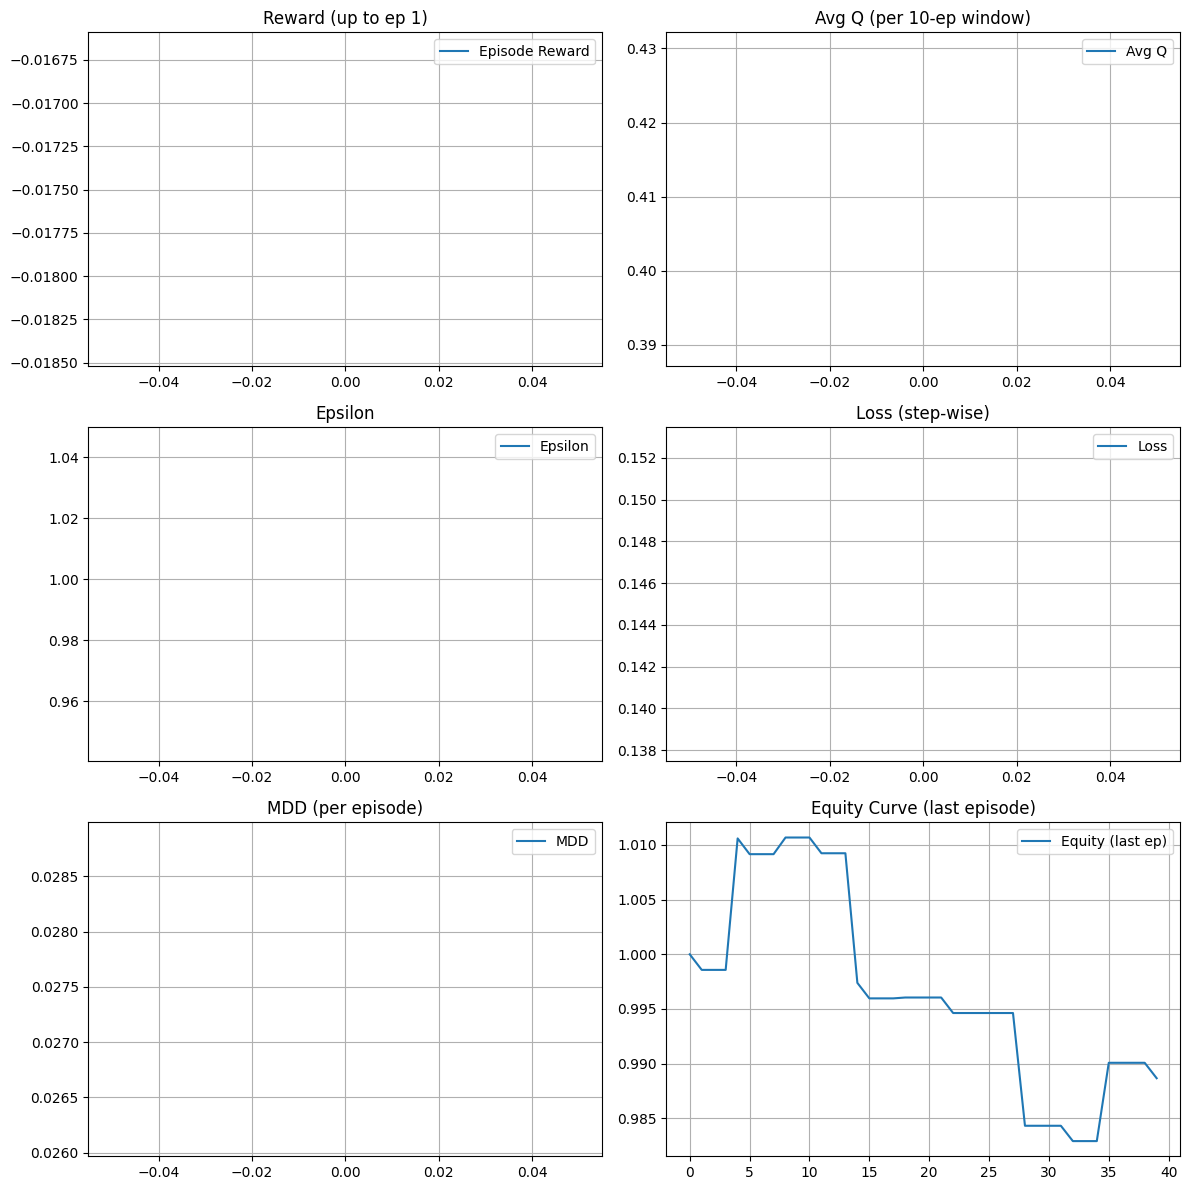

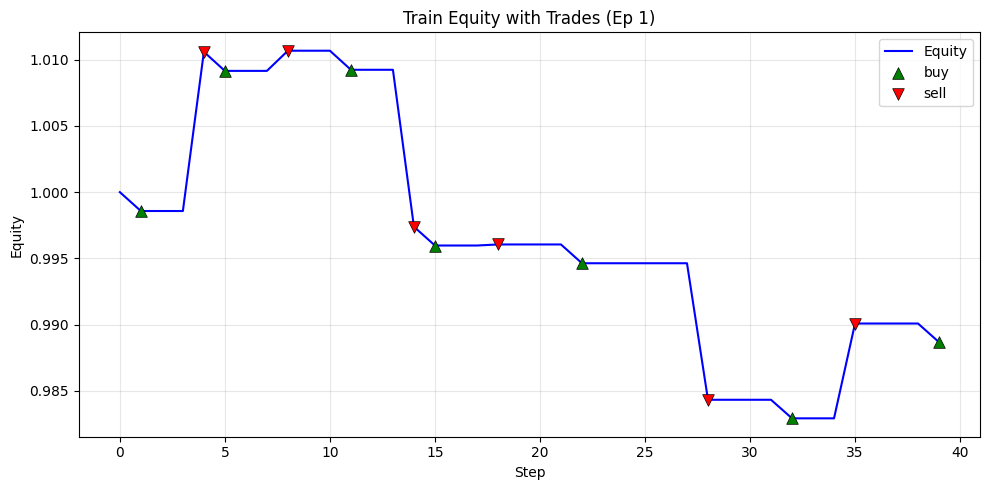

🎯 目標網路已更新 (步數: 200)
[Train] Ep 010 | steps= 40 | ep_reward=+0.0214 | avg_reward(last 10 eps)=-0.0160 | avg_q=0.0410 | epsilon=0.164 | MDD=0.0014


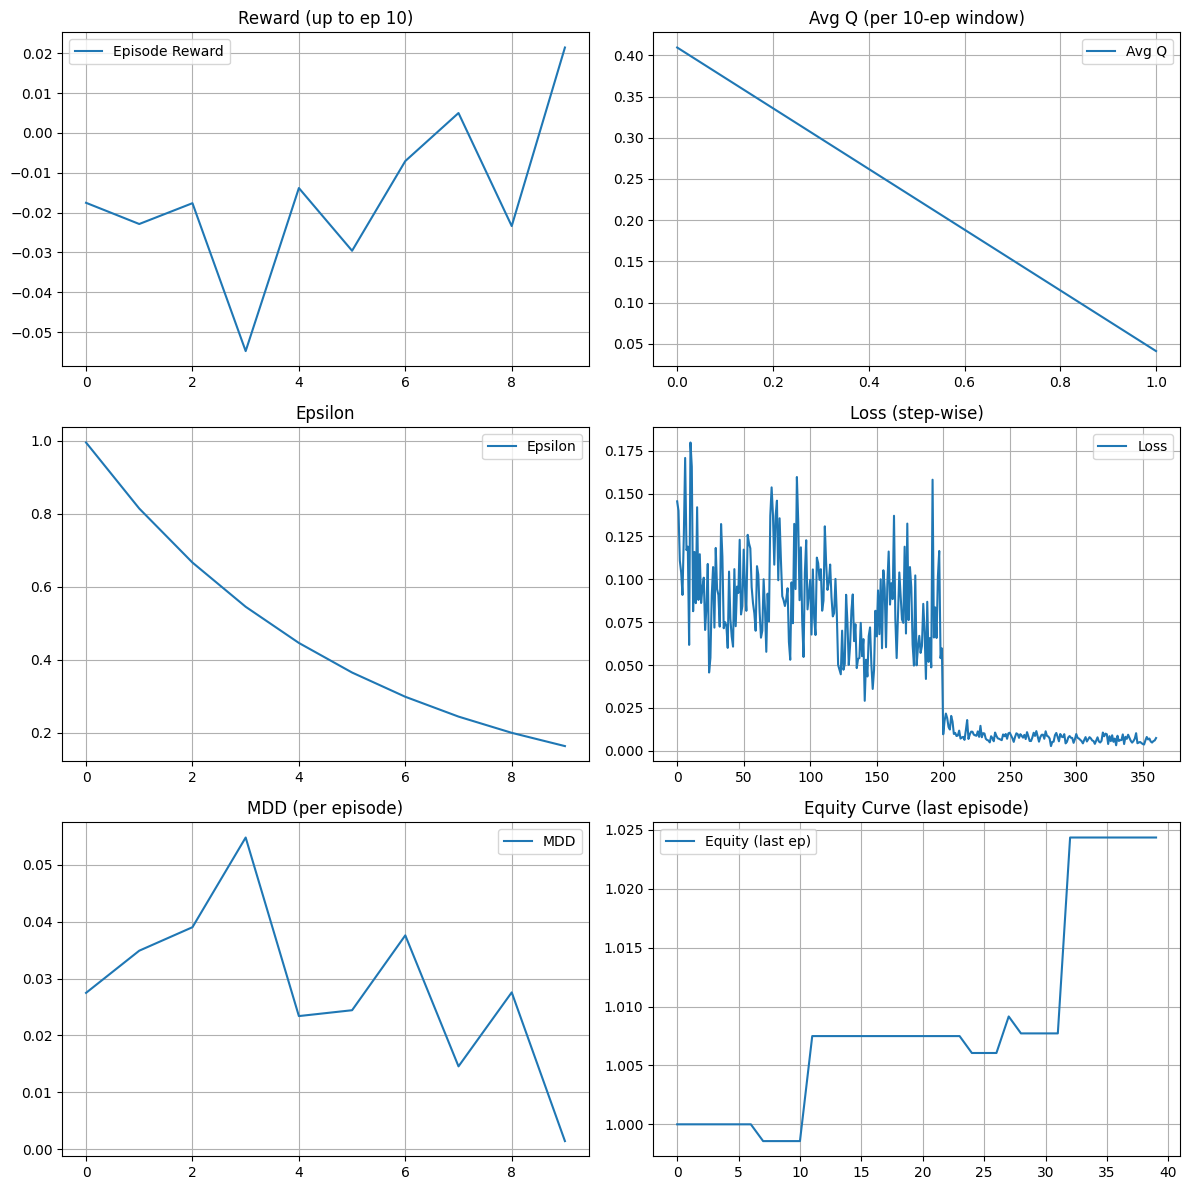

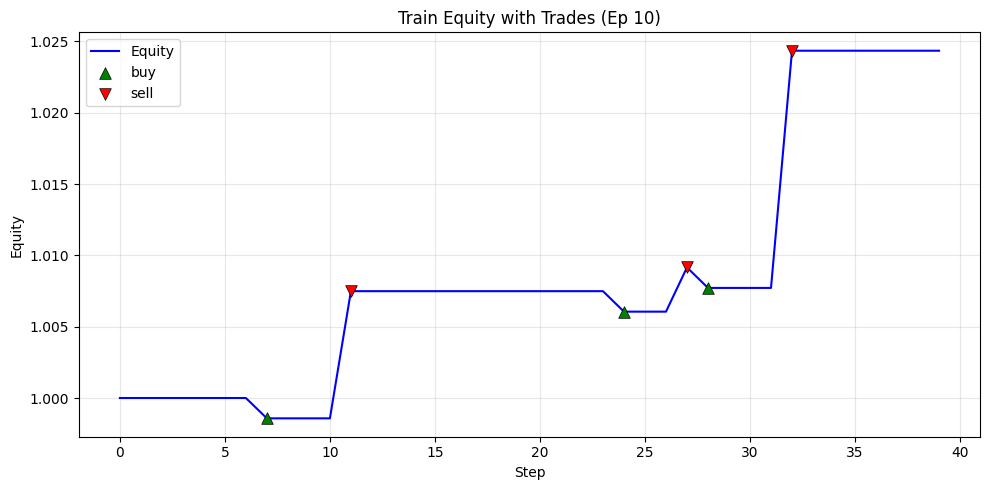

🎯 目標網路已更新 (步數: 400)
🎯 目標網路已更新 (步數: 600)
[Train] Ep 020 | steps= 40 | ep_reward=-0.0219 | avg_reward(last 10 eps)=-0.0006 | avg_q=0.0793 | epsilon=0.050 | MDD=0.0205


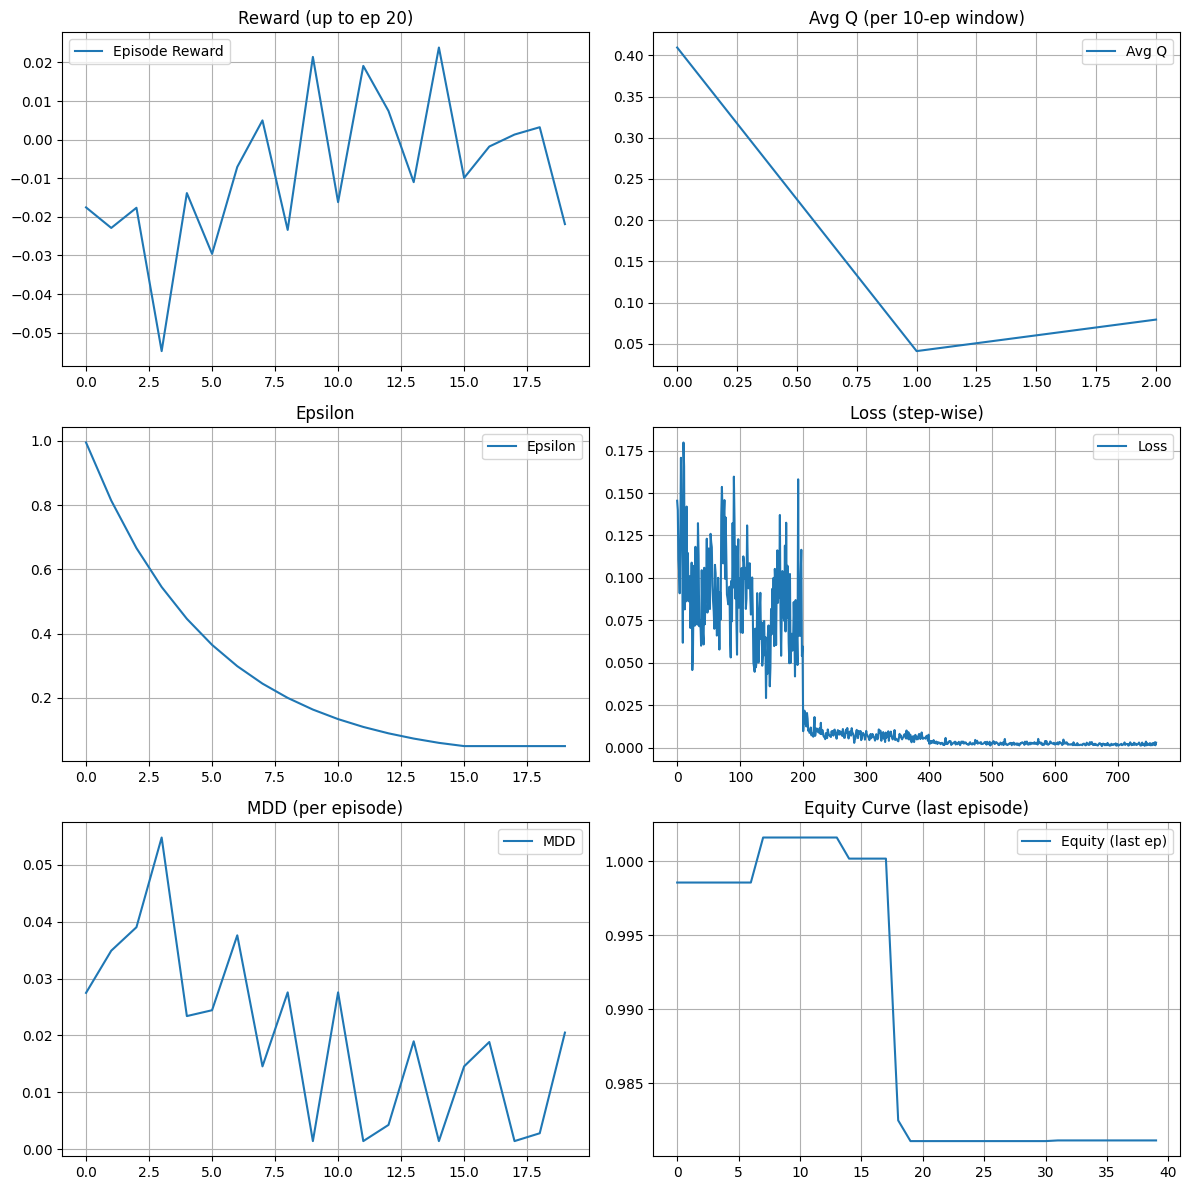

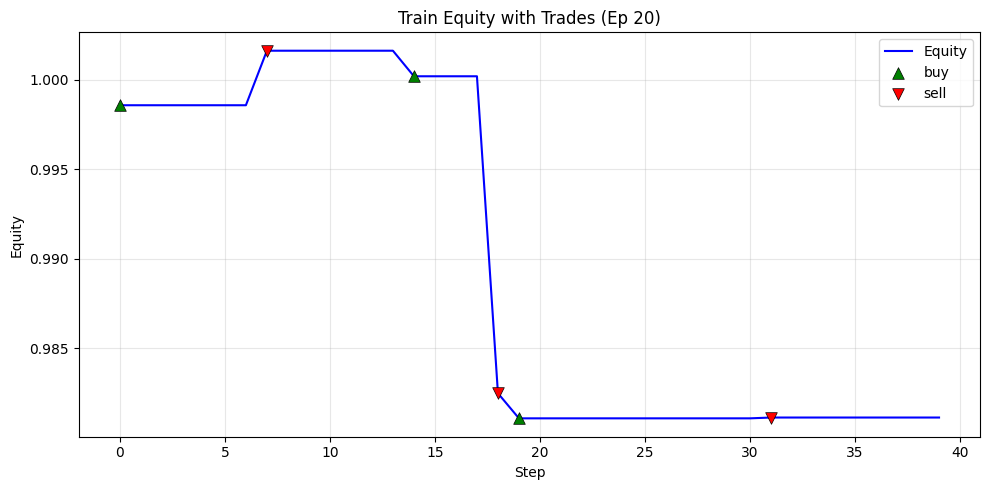

🎯 目標網路已更新 (步數: 800)
🎯 目標網路已更新 (步數: 1000)
[Train] Ep 030 | steps= 40 | ep_reward=-0.0209 | avg_reward(last 10 eps)=-0.0097 | avg_q=0.1014 | epsilon=0.050 | MDD=0.0249


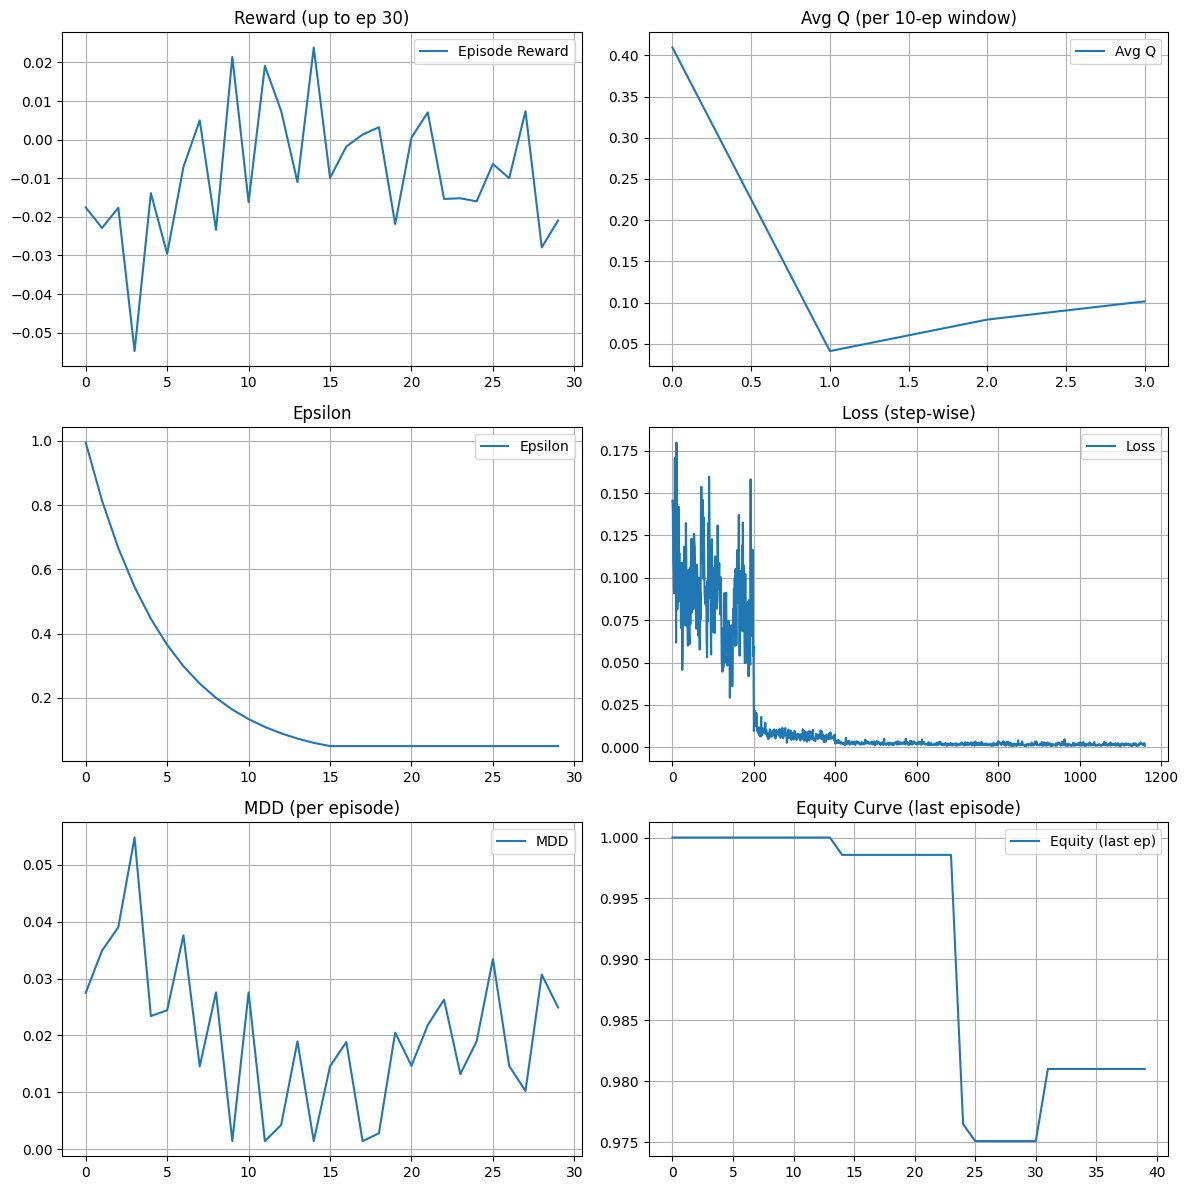

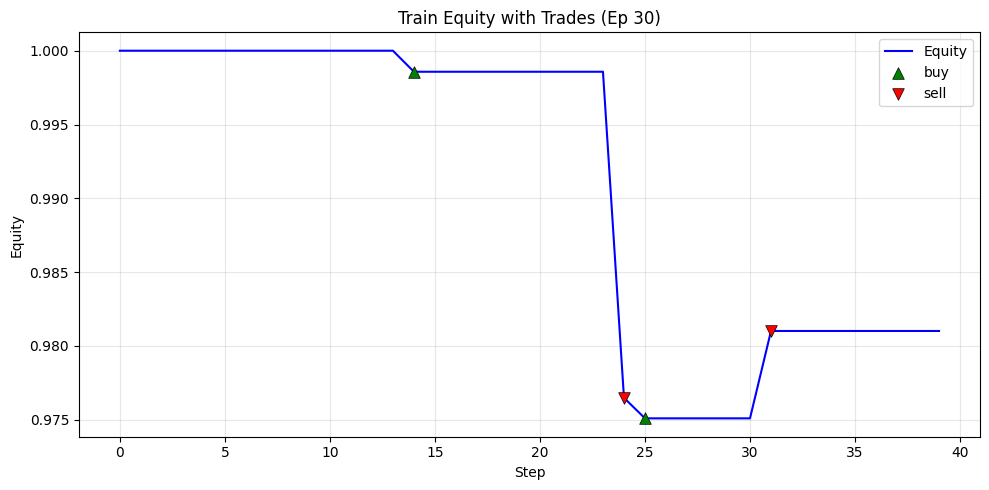

🎯 目標網路已更新 (步數: 1200)
🎯 目標網路已更新 (步數: 1400)
[Train] Ep 040 | steps= 40 | ep_reward=+0.0268 | avg_reward(last 10 eps)=+0.0012 | avg_q=0.1115 | epsilon=0.050 | MDD=0.0014


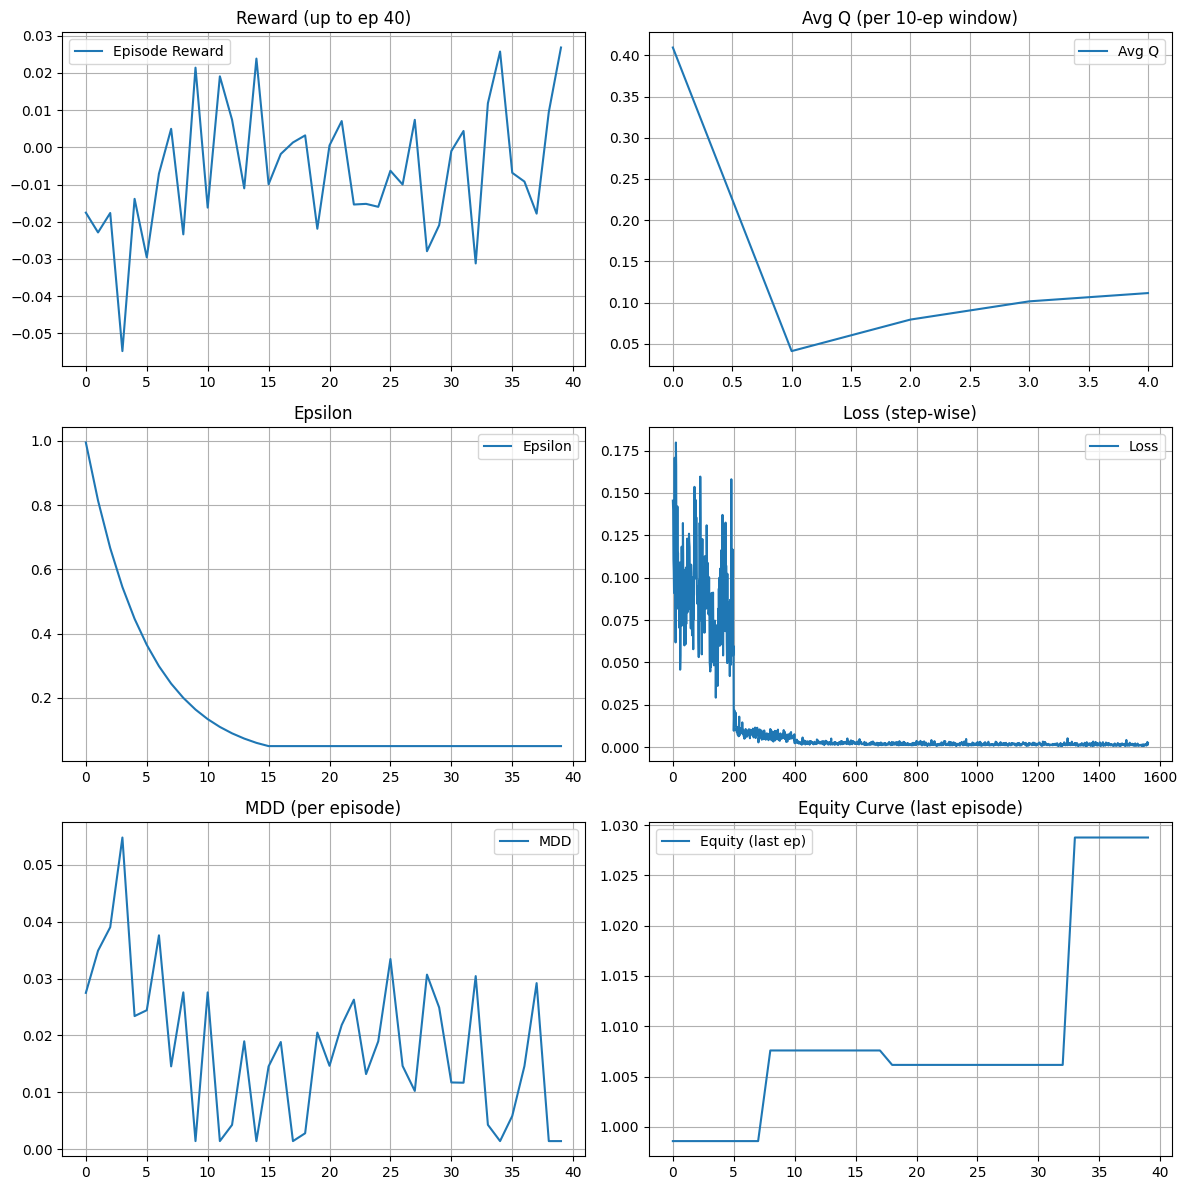

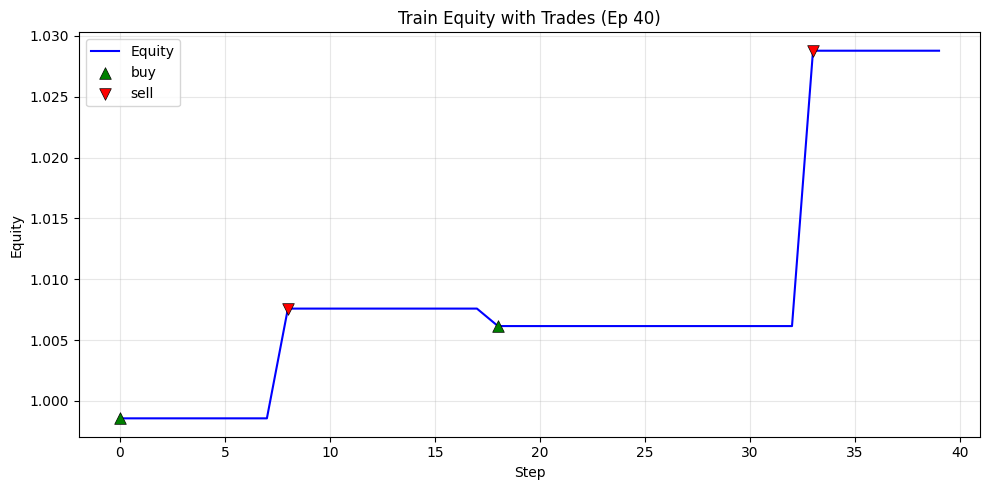

🎯 目標網路已更新 (步數: 1600)
🎯 目標網路已更新 (步數: 1800)
[Train] Ep 050 | steps= 40 | ep_reward=+0.0067 | avg_reward(last 10 eps)=+0.0124 | avg_q=0.1213 | epsilon=0.050 | MDD=0.0014


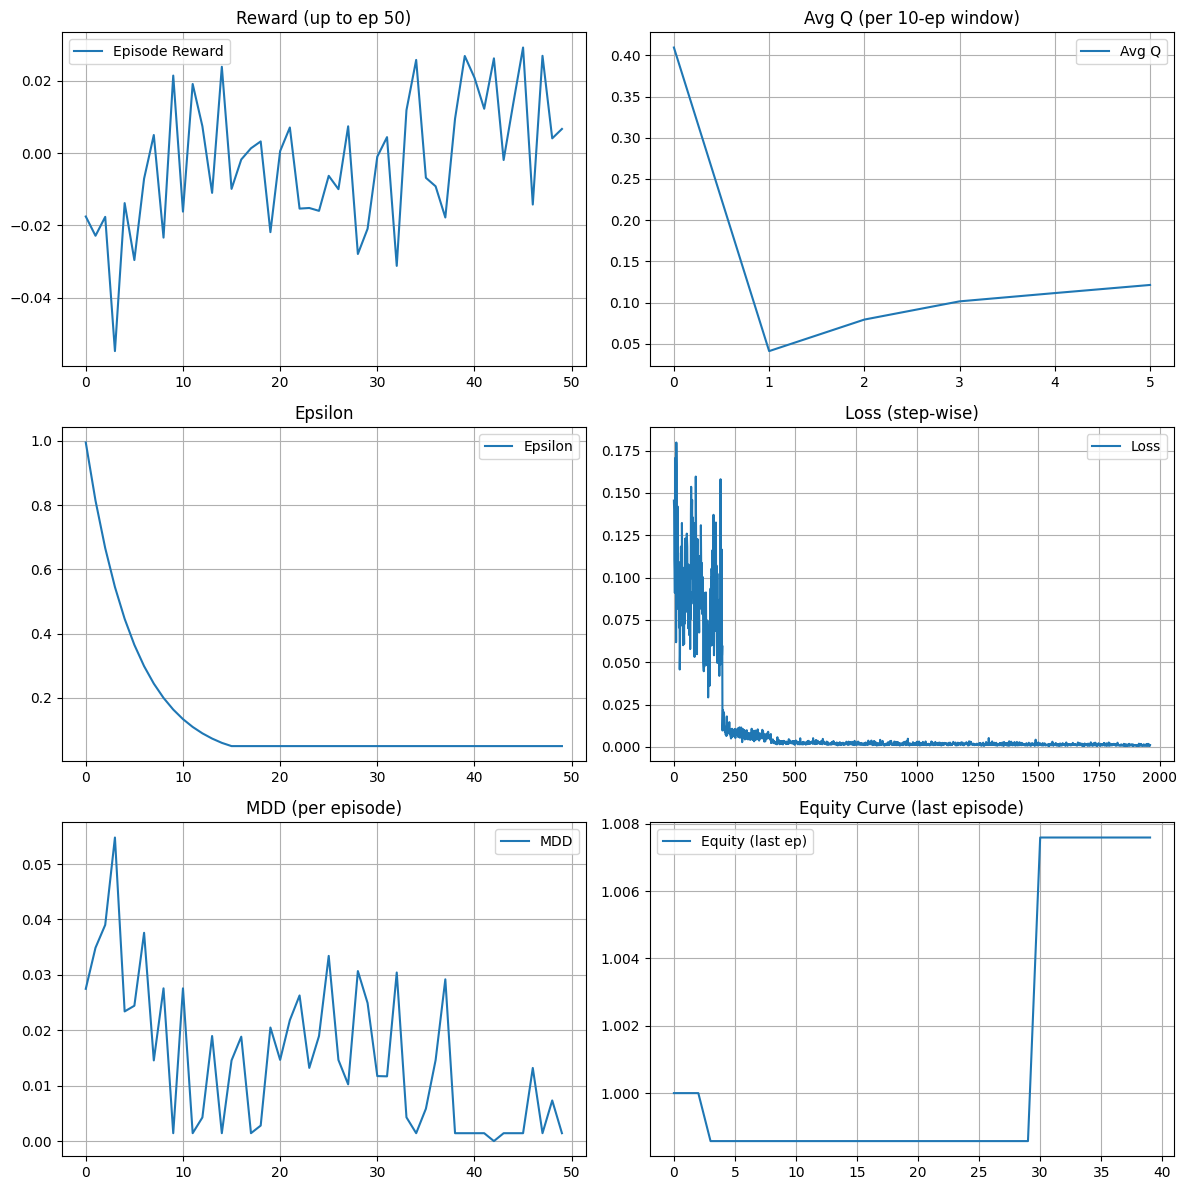

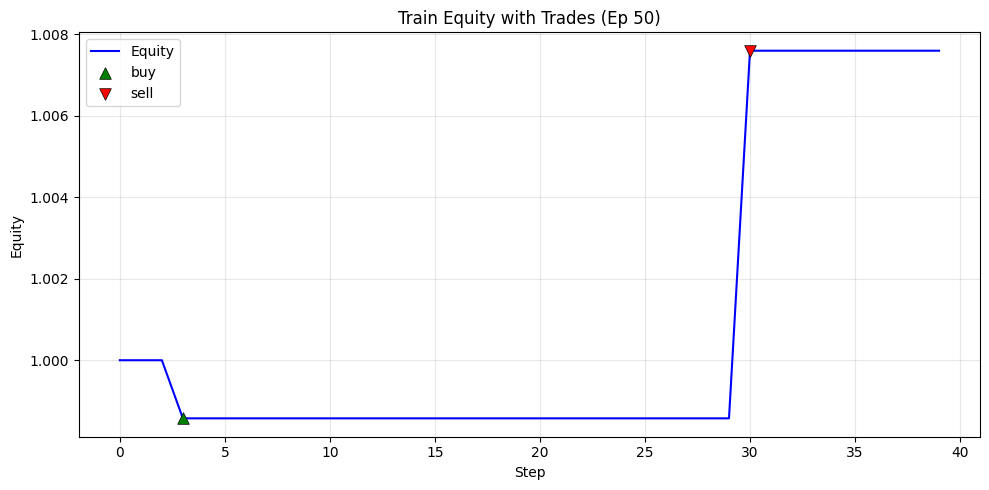

訓練完成。
開始測試...


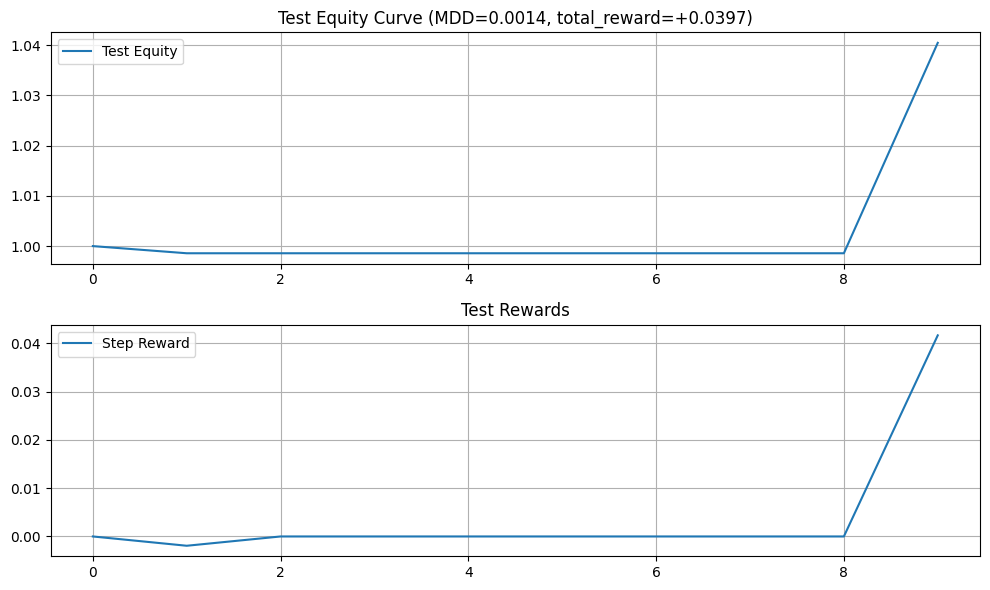

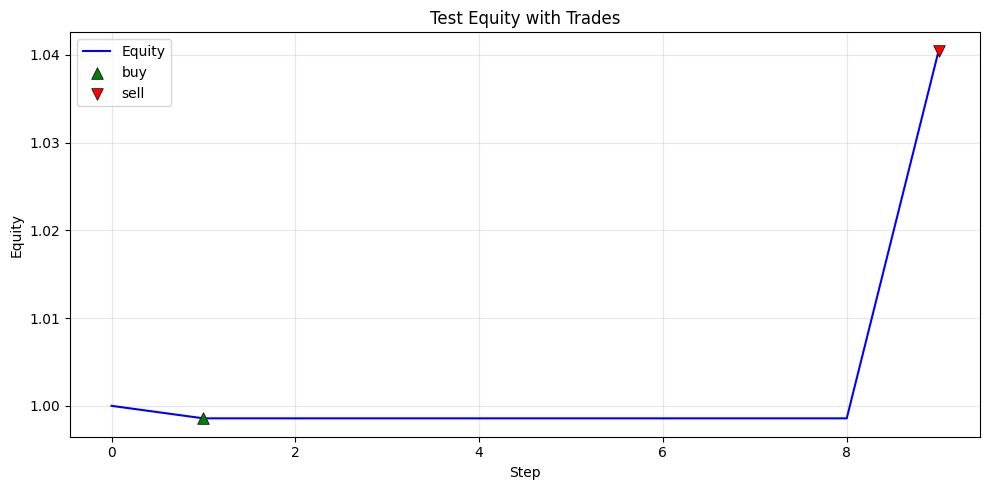

[Test] steps=10 total_reward=+0.0397 MDD=0.0014
Total trades: 2
Step    1 | 2023-03-20 | BUY  @ price=61.20139694213867
Step    9 | 2023-03-30 | SELL @ price=64.0521240234375


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import deque
import pandas as pd
from typing import List, Dict

# 假設你已經有以下物件/函式可用：
# - SingleStockEnv
# - LSTMAgent
# - load_and_preprocess_data
# 並且 stock_data, marco_df, industry_df 已經 load 好
# 若尚未有，請先執行你前面的資料載入與環境定義 cells

# -----------------------------
# 參數
# -----------------------------
ticker_list = sorted(list(stock_data.keys()))
ticker_to_idx = {t: i for i, t in enumerate(ticker_list)}
target_ticker = ticker_list[0]  # 選第一檔做小量訓練
train_start = pd.Timestamp('2023-01-01')
train_end   = pd.Timestamp('2023-03-15')
test_start  = pd.Timestamp('2023-03-16')
test_end    = pd.Timestamp('2023-03-31')

sequence_length = 30
episodes = 50          # 小量訓練回合數
max_steps_per_ep = 1000
log_interval = 10

# LSTM agent 超參
hidden_size = 128
num_layers = 1
learning_rate = 1e-3
batch_size = 32
memory_size = 200      # episode-based capacity（內部是用 episode 存儲，但此值越大可存更多可採樣段）
chunk_len = 4
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
target_update_freq = 200

# -----------------------------
# 建立訓練與測試環境
# -----------------------------
def build_env(stock_data, marco_df, industry_df, ticker, start, end, sequence_length=1):
    env = SingleStockEnv(
        stock_df=stock_data[ticker].copy(),
        marco_df=marco_df.copy(),
        industry_df=industry_df.copy(),
        ticker=ticker,
        ticker_to_idx=ticker_to_idx,
        start_date=start,
        end_date=end,
        sequence_length=sequence_length,
        min_holding_days=3,
        stop_loss_pct=0.12,
        cooldown_days_after_force_sell=3,
        take_profit_pct=None,
        max_holding_days=60,
        penalty_config={'trade_penalty': 0.0005, 'large_loss_penalty': 0.002}
    )
    return env

env_train = build_env(stock_data, marco_df, industry_df, target_ticker, train_start, train_end, sequence_length)
env_test  = build_env(stock_data, marco_df, industry_df, target_ticker, test_start, test_end, sequence_length)

# 狀態維度（單一觀測向量長度）
if sequence_length > 1:
    state_size = env_train.observation_space.shape[-1]
else:
    state_size = env_train.observation_space.shape[0]
action_size = env_train.action_space.n

# -----------------------------
# 建立 LSTMAgent
# -----------------------------
agent = LSTMAgent(
    state_size=state_size,
    action_size=action_size,
    sequence_length=sequence_length,
    hidden_size=hidden_size,
    num_layers=num_layers,
    learning_rate=learning_rate,
    batch_size=batch_size,
    memory_size=memory_size,
    chunk_len=chunk_len,
    gamma=gamma,
    epsilon=epsilon,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
    target_update_freq=target_update_freq,
    device=None,         # 自動選擇
    use_noisy=False,     # 初期關閉 NoisyNet，使用 epsilon
    reset_epsilon_each_episode=False
)

# -----------------------------
# 訓練 loop（小量）
# -----------------------------
episode_rewards = []
episode_mdds = []
avg_q_history = []
epsilon_history = []
loss_history_accum = []  # 收集所有 step 的 loss（內部 agent 有 loss_history，我們也收集做平均）

def extract_trades(trade_infos: List[dict]):
    # 回傳列表中每筆交易的 (step_index, event, price, date)
    steps, events, prices, dates = [], [], [], []
    for idx, info in enumerate(trade_infos):
        evt = info.get('event', 'hold')
        if evt in ('buy', 'sell'):
            steps.append(idx)
            events.append(evt)
            prices.append(info.get('event_price', None))
            dates.append(info.get('observation_date', None))
    return steps, events, prices, dates

def plot_equity_with_trades(equity_curve: List[float], trade_infos: List[dict], title: str = "Equity with Trades"):
    xs = np.arange(len(equity_curve))
    plt.figure(figsize=(10, 5))
    plt.plot(xs, equity_curve, label='Equity', color='blue', linewidth=1.5)

    # 收集 buy/sell 索引
    buy_idx, sell_idx = [], []
    for i, info in enumerate(trade_infos):
        evt = info.get('event', 'hold')
        if evt == 'buy':
            buy_idx.append(i)
        elif evt == 'sell':
            sell_idx.append(i)

    # 分組一次性標示，避免覆蓋和圖例混亂
    if buy_idx:
        plt.scatter(buy_idx, [equity_curve[i] for i in buy_idx],
                    color='green', marker='^', s=70, label='buy', zorder=3, edgecolor='k', linewidths=0.5)
    if sell_idx:
        plt.scatter(sell_idx, [equity_curve[i] for i in sell_idx],
                    color='red', marker='v', s=70, label='sell', zorder=3, edgecolor='k', linewidths=0.5)

    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Equity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compute_mdd_from_equity(equity: List[float]) -> float:
    arr = np.array(equity, dtype=float)
    if len(arr) == 0:
        return 0.0
    peak = np.maximum.accumulate(arr)
    dd = (peak - arr) / np.clip(peak, 1e-8, None)
    return float(np.max(dd)) if len(dd) > 0 else 0.0

def plot_metrics(ep, rewards, avg_q, eps_list, loss_hist, mdd_hist, equity_curve):
    # 每 10 episodes 繪圖一次
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes = axes.ravel()

    # Reward
    axes[0].plot(rewards, label="Episode Reward")
    axes[0].set_title(f"Reward (up to ep {ep})")
    axes[0].legend(); axes[0].grid(True)

    # Avg Q
    axes[1].plot(avg_q, label="Avg Q")
    axes[1].set_title("Avg Q (per 10-ep window)")
    axes[1].legend(); axes[1].grid(True)

    # Epsilon
    axes[2].plot(eps_list, label="Epsilon")
    axes[2].set_title("Epsilon")
    axes[2].legend(); axes[2].grid(True)

    # Loss
    axes[3].plot(loss_hist, label="Loss")
    axes[3].set_title("Loss (step-wise)")
    axes[3].legend(); axes[3].grid(True)

    # MDD
    axes[4].plot(mdd_hist, label="MDD")
    axes[4].set_title("MDD (per episode)")
    axes[4].legend(); axes[4].grid(True)

    # Equity Curve（最近一個 episode）
    if len(equity_curve) > 0:
        axes[5].plot(equity_curve, label="Equity (last ep)")
    axes[5].set_title("Equity Curve (last episode)")
    axes[5].legend(); axes[5].grid(True)

    plt.tight_layout()
    plt.show()

def print_trades(trade_infos: List[dict], max_print: int = 50):
    steps, events, prices, dates = extract_trades(trade_infos)
    print(f"Total trades: {len(steps)}")
    for i, (s, e, p, d) in enumerate(zip(steps, events, prices, dates)):
        if i >= max_print:
            print(f"... (more {len(steps)-max_print} trades)")
            break
        print(f"Step {s:4d} | {str(d)[:10] if d is not None else 'NA'} | {e.upper():4s} @ price={p}")

def summarize_trades(trade_infos: List[dict]):
    buys = sum(1 for x in trade_infos if x.get('event') == 'buy')
    sells = sum(1 for x in trade_infos if x.get('event') == 'sell')
    holds = sum(1 for x in trade_infos if x.get('event') == 'hold')
    print(f"Trades summary: buy={buys}, sell={sells}, hold={holds}")


print("開始訓練...")
for ep in range(1, episodes + 1):
    state = env_train.reset()
    agent.start_episode()
    done = False
    total_reward = 0.0
    step_count = 0
    q_values_accum = []
    equity_curve = []
    trade_infos = []     # 新增：收集每步 info 以標示交易

    base_loss_len = len(agent.loss_history)

    while not done and step_count < max_steps_per_ep:
        action = agent.get_action(state, training=True, keep_hidden=True)
        next_state, reward, done, info = env_train.step(action)
        total_reward += reward
        step_count += 1

        agent.store_transition(state, action, reward, next_state, done)
        agent.train()

        with torch.no_grad():
            st = torch.as_tensor(state, dtype=torch.float32, device=agent.device)
            if st.dim() == 1:
                st = st.unsqueeze(0).unsqueeze(0)
            elif st.dim() == 2:
                st = st.unsqueeze(0)
            qv, _ = agent.q_network(st)
            q_values_accum.append(float(qv.max().item()))

        equity_curve.append(info.get('equity', env_train.cumulative_return))
        trade_infos.append(info)   # 新增：收集 info

        state = next_state

    agent.end_episode()

    episode_rewards.append(total_reward)
    mdd_ep = compute_mdd_from_equity(equity_curve)
    episode_mdds.append(mdd_ep)
    avg_q_ep = float(np.mean(q_values_accum)) if len(q_values_accum) > 0 else 0.0
    epsilon_history.append(agent.epsilon)
    new_losses = agent.loss_history[base_loss_len:]
    loss_history_accum.extend(new_losses)

    if ep % log_interval == 0 or ep == 1:
        window_rewards = episode_rewards[-log_interval:] if len(episode_rewards) >= log_interval else episode_rewards
        avg_reward = float(np.mean(window_rewards))
        avg_q_history.append(avg_q_ep)
        print(f"[Train] Ep {ep:03d} | steps={step_count:3d} | ep_reward={total_reward:+.4f} | "
              f"avg_reward(last {len(window_rewards)} eps)={avg_reward:+.4f} | "
              f"avg_q={avg_q_ep:.4f} | epsilon={agent.epsilon:.3f} | MDD={mdd_ep:.4f}")

        plot_metrics(
            ep=ep,
            rewards=episode_rewards,
            avg_q=avg_q_history,
            eps_list=epsilon_history,
            loss_hist=loss_history_accum,
            mdd_hist=episode_mdds,
            equity_curve=equity_curve
        )
        # 額外畫交易點（最近一集）
        plot_equity_with_trades(equity_curve, trade_infos, title=f"Train Equity with Trades (Ep {ep})")

print("訓練完成。")

# -----------------------------
# 測試 loop（不訓練，僅評估與畫圖）
# -----------------------------
def run_test(env, agent, render=False):
    state = env.reset()
    agent.reset_hidden()  # 關鍵：測試開始時重置 hidden
    done = False
    total_reward = 0.0
    equity_curve = []
    rewards = []
    steps = 0
    trade_infos = []

    while not done and steps < 5000:
        action = agent.get_action(state, training=False, keep_hidden=True)  # 關鍵：沿用 LSTM 記憶
        next_state, reward, done, info = env.step(action)
        state = next_state
        total_reward += reward
        rewards.append(reward)
        equity_curve.append(info.get('equity', env.cumulative_return))
        trade_infos.append(info)
        steps += 1
        if render and steps % 50 == 0:
            env.render()

    mdd = compute_mdd_from_equity(equity_curve)

    # 畫測試的資產與 reward
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    axes[0].plot(equity_curve, label="Test Equity")
    axes[0].set_title(f"Test Equity Curve (MDD={mdd:.4f}, total_reward={total_reward:+.4f})")
    axes[0].legend(); axes[0].grid(True)
    axes[1].plot(rewards, label="Step Reward")
    axes[1].set_title("Test Rewards")
    axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    plt.show()

    # 畫交易點
    plot_equity_with_trades(equity_curve, trade_infos, title="Test Equity with Trades")

    print(f"[Test] steps={steps} total_reward={total_reward:+.4f} MDD={mdd:.4f}")
    return {
        'total_reward': total_reward,
        'mdd': mdd,
        'equity': equity_curve,
        'rewards': rewards,
        'trades': trade_infos
    }
print("開始測試...")
test_summary = run_test(env_test, agent, render=False)
print_trades(test_summary['trades'])


# 大量

In [ ]:
# ===== Training Cell =====
import os
import time
import random
import glob
import numpy as np
import pandas as pd
import torch

# 請先確保已執行：
# - drive.mount('/content/drive')（若在 Colab）
# - 你已在本 Notebook 前面定義：SingleStockEnv、LSTMAgent、load_and_preprocess_data()

# 固定隨機種子（可重現）
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 1) 載入資料
stock_data, marco_df, industry_df = load_and_preprocess_data()

# 2) 參數與日期設定
tickers = sorted(list(stock_data.keys()))
ticker_to_idx = {t: i for i, t in enumerate(tickers)}

sequence_length = 60
# 注意：資料從 2020-01-01 開始，為滿足序列長度 60，訓練開始設為 2020-03-01
train_start = pd.Timestamp('2020-03-01')
train_end   = pd.Timestamp('2023-06-30')
val_start   = pd.Timestamp('2023-07-01')
val_end     = pd.Timestamp('2023-12-31')

# 3) LSTM Agent 參數（大訓練）
agent_cfg = dict(
    state_size=None,
    action_size=3,
    sequence_length=sequence_length,
    hidden_size=256,
    num_layers=2,
    learning_rate=1e-4,
    batch_size=64,
    memory_size=2000,
    chunk_len=8,
    gamma=0.99,
    epsilon=1.0,
    epsilon_min=0.02,
    epsilon_decay=0.999,
    target_update_freq=2000,
    device=None,
    use_noisy=False,
    reset_epsilon_each_episode=False
)

# 4) 建立訓練/驗證環境
def build_env(ticker, start, end):
    return SingleStockEnv(
        stock_df=stock_data[ticker].copy(),
        marco_df=marco_df.copy(),
        industry_df=industry_df.copy(),
        ticker=ticker,
        ticker_to_idx=ticker_to_idx,
        start_date=start,
        end_date=end,
        sequence_length=sequence_length,
        penalty_config={'trade_penalty': 0.0005, 'large_loss_penalty': 0.002, 'overtrade_penalty': 0.001},
        min_holding_days=3,
        stop_loss_pct=0.12,
        cooldown_days_after_force_sell=3,
        take_profit_pct=None,
        max_holding_days=60
    )

# 5) 用第一個 ticker 初始化 state_size 與 agent
if len(tickers) == 0:
    raise RuntimeError("stock_data 為空，請確認 load_and_preprocess_data() 有讀到資料")

env_probe = build_env(tickers[0], train_start, train_end)
state_size = env_probe.observation_space.shape[-1] if sequence_length > 1 else env_probe.observation_space.shape[0]
agent_cfg['state_size'] = state_size
agent = LSTMAgent(**agent_cfg)

# 6) 儲存目錄（請確認已 mount Google Drive）
ckpt_dir = "/content/drive/MyDrive/Kai/envtest/checkpoints_large"
os.makedirs(ckpt_dir, exist_ok=True)
log_csv = os.path.join(ckpt_dir, "training_log.csv")

if not os.path.exists(log_csv):
    pd.DataFrame(columns=[
        'time','epoch','ticker','episode','steps','ep_reward','mdd','epsilon',
        'val_reward','val_steps','val_mdd','ep_avg_loss'
    ]).to_csv(log_csv, index=False)

# 狀態變數
last_save_time = time.time()
best_val_reward = -1e18
best_val_mdd = 1e18

def consume_episode_loss(prev_len):
    new_losses = agent.loss_history[prev_len:]
    if len(new_losses) == 0:
        return None
    return float(np.mean(new_losses))

def run_episode(env, train=True):
    state = env.reset()
    if train:
        agent.start_episode()
        base_len = len(agent.loss_history)  # 標記本 episode 前的 loss 長度
    else:
        agent.reset_hidden()
        base_len = len(agent.loss_history)

    done = False
    total_reward = 0.0
    steps = 0
    equity_curve = []
    while not done:
        action = agent.get_action(state, training=train, keep_hidden=True)
        next_state, reward, done, info = env.step(action)
        if train:
            agent.store_transition(state, action, reward, next_state, done)
            agent.train()
        total_reward += reward
        state = next_state
        steps += 1
        equity_curve.append(info.get('equity', env.cumulative_return))
        if steps > 20000:
            break
    if train:
        agent.end_episode()

    eq = np.array(equity_curve, dtype=float) if len(equity_curve)>0 else np.array([1.0])
    peak = np.maximum.accumulate(eq)
    mdd = float(np.max((peak - eq)/np.clip(peak,1e-8,None))) if len(eq)>0 else 0.0
    ep_avg_loss = consume_episode_loss(base_len) if train else None
    return total_reward, steps, mdd, ep_avg_loss

def save_periodic(epoch_tag):
    global last_save_time
    if time.time() - last_save_time > 300:  # 每 5 分鐘
        ckpt_path = os.path.join(ckpt_dir, f"lstm_{epoch_tag}_{int(time.time())}.pth")
        agent.save_model(ckpt_path)
        last_save_time = time.time()

def save_best(tag):
    ckpt_path = os.path.join(ckpt_dir, f"lstm_best_{tag}.pth")
    agent.save_model(ckpt_path)

def latest_ckpt(path=ckpt_dir):
    files = sorted(glob.glob(os.path.join(path, "lstm_*.pth")), key=os.path.getmtime)
    return files[-1] if files else None

# 7) 嘗試自動續訓（若已有最近 checkpoint）
try:
    last = latest_ckpt()
    if last:
        print(f"嘗試載入最近的 checkpoint: {last}")
        agent.load_model(last, strict=False)
except Exception as e:
    print(f"續訓載入失敗（忽略並從頭開始）: {e}")

# 8) 主訓練
total_epochs = 50               # 視資源可調
episodes_per_ticker = 10        # 每個 ticker 每輪 episode 數

try:
    for epoch in range(1, total_epochs+1):
        random.shuffle(tickers)
        epoch_val_rewards = []
        epoch_val_mdds = []

        for tk in tickers:
            # 建立訓練/驗證環境
            env_train = build_env(tk, train_start, train_end)
            env_val   = build_env(tk, val_start, val_end)

            for ep in range(1, episodes_per_ticker+1):
                ep_reward, steps, mdd, ep_avg_loss = run_episode(env_train, train=True)
                val_reward, val_steps, val_mdd, _ = run_episode(env_val, train=False)
                epoch_val_rewards.append(val_reward)
                epoch_val_mdds.append(val_mdd)

                # 記錄
                row = {
                    'time': pd.Timestamp.now().isoformat(),
                    'epoch': epoch,
                    'ticker': tk,
                    'episode': ep,
                    'steps': steps,
                    'ep_reward': round(ep_reward,6),
                    'mdd': round(mdd,6),
                    'epsilon': round(agent.epsilon,4),
                    'val_reward': round(val_reward,6),
                    'val_steps': int(val_steps),
                    'val_mdd': round(val_mdd,6),
                    'ep_avg_loss': (round(ep_avg_loss,6) if ep_avg_loss is not None else None)
                }
                pd.DataFrame([row]).to_csv(log_csv, mode='a', header=False, index=False)

                # 更新 best checkpoint
                if val_reward > best_val_reward:
                    best_val_reward = val_reward
                    save_best("reward")
                if val_mdd < best_val_mdd:
                    best_val_mdd = val_mdd
                    save_best("mdd")

                # 週期性保存
                save_periodic(f"epoch{epoch}")

        print(f"[Epoch {epoch}] avg val reward={np.mean(epoch_val_rewards):+.6f}, avg val mdd={np.mean(epoch_val_mdds):.6f}")

except KeyboardInterrupt:
    print("⛔ 偵測到手動中斷，保存當前模型...")
    agent.save_model(os.path.join(ckpt_dir, f"lstm_interrupted_{int(time.time())}.pth"))
    print("已保存，可稍後續訓。")
except Exception as e:
    print(f"❗訓練時發生例外：{e}")
    agent.save_model(os.path.join(ckpt_dir, f"lstm_error_{int(time.time())}.pth"))
    raise
finally:
    # 最終保存
    final_path = os.path.join(ckpt_dir, "lstm_final.pth")
    agent.save_model(final_path)
    print("大規模訓練完成／結束！日誌位於：", log_csv)

/tmp/ipython-input-3362306555.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-3362306555.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-3362306555.py:170: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.industry_df = self.industry_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version.

🔥 LSTMAgent使用設備: cpu
嘗試載入最近的 checkpoint: /content/drive/MyDrive/Kai/envtest/checkpoints_large/lstm_final.pth


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


續訓載入失敗（忽略並從頭開始）: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load

/tmp/ipython-input-3362306555.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-3362306555.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-3362306555.py:170: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.industry_df = self.industry_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version.

💾 LSTM模型已保存: /content/drive/MyDrive/Kai/envtest/checkpoints_large/lstm_best_reward.pth
💾 LSTM模型已保存: /content/drive/MyDrive/Kai/envtest/checkpoints_large/lstm_best_mdd.pth
⛔ 偵測到手動中斷，保存當前模型...
💾 LSTM模型已保存: /content/drive/MyDrive/Kai/envtest/checkpoints_large/lstm_interrupted_1756063132.pth
已保存，可稍後續訓。
💾 LSTM模型已保存: /content/drive/MyDrive/Kai/envtest/checkpoints_large/lstm_final.pth
大規模訓練完成／結束！日誌位於： /content/drive/MyDrive/Kai/envtest/checkpoints_large/training_log.csv


# Testing

In [ ]:
stock_data, marco_df, industry_df = load_and_preprocess_data()

In [11]:
import os
import glob
import numpy as np
import pandas as pd
import torch

# 1) 路徑與資料
ckpt_dir = "/content/drive/MyDrive/Kai/envtest/checkpoints_large"
assert os.path.isdir(ckpt_dir), f"找不到目錄：{ckpt_dir}，請確認已掛載 Google Drive 並完成訓練或有現成 checkpoint"


tickers = sorted(list(stock_data.keys()))
ticker_to_idx = {t: i for i, t in enumerate(tickers)}

# 2) 測試區間與 sequence_length
sequence_length = 60
test_start = pd.Timestamp('2025-01-01')
test_end   = pd.Timestamp('2025-08-07')

# 3) 構建測試環境（選擇要測試的 ticker，預設第1檔；可改成 '2330' 等）
if len(tickers) == 0:
    raise RuntimeError("stock_data 為空，無法測試。")

test_ticker = tickers[9]  # 改成你想測的代碼也可以，例如 '2330'
env_test = SingleStockEnv(
    stock_df=stock_data[test_ticker].copy(),
    marco_df=marco_df.copy(),
    industry_df=industry_df.copy(),
    ticker=test_ticker,
    ticker_to_idx=ticker_to_idx,
    start_date=test_start,
    end_date=test_end,
    sequence_length=sequence_length,
    penalty_config={'trade_penalty': 0.0005, 'large_loss_penalty': 0.002, 'overtrade_penalty': 0.001},
    min_holding_days=3,
    stop_loss_pct=0.12,
    cooldown_days_after_force_sell=3,
    take_profit_pct=None,
    max_holding_days=60
)

# 4) 建立 agent 並載入最佳或最終 checkpoint
state_size = env_test.observation_space.shape[-1] if sequence_length > 1 else env_test.observation_space.shape[0]
agent = LSTMAgent(
    state_size=state_size,
    action_size=3,
    sequence_length=sequence_length,
    hidden_size=256,
    num_layers=2,
    learning_rate=1e-4,
    batch_size=64,
    memory_size=2000,
    chunk_len=8,
    gamma=0.99,
    epsilon=0.0,                # 測試用，不探索
    epsilon_min=0.0,
    epsilon_decay=1.0,
    target_update_freq=2000,
    device=None,
    use_noisy=False,
    reset_epsilon_each_episode=False
)

def pick_checkpoint(path: str):
    # 優先使用最佳表現；否則找 final；再不行找最新的 lstm_*.pth
    candidates = [
        os.path.join(path, "lstm_best_reward.pth"),
        os.path.join(path, "lstm_best_mdd.pth"),
        os.path.join(path, "lstm_final.pth"),
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    files = sorted(glob.glob(os.path.join(path, "lstm_*.pth")), key=os.path.getmtime)
    return files[-1] if files else None

ckpt = pick_checkpoint(ckpt_dir)
if ckpt is None:
    raise FileNotFoundError(f"在 {ckpt_dir} 找不到任何 checkpoint")
print("載入 checkpoint:", ckpt)

# 方案A：顯式 weights_only=False 載入（適用於你自己保存的完整 checkpoint）
ckpt_obj = torch.load(ckpt, map_location=agent.device, weights_only=False)
agent.q_network.load_state_dict(ckpt_obj['q_network_state_dict'], strict=False)
agent.target_network.load_state_dict(ckpt_obj['target_network_state_dict'], strict=False)
# 測試時不需要 optimizer/buffer，以下可省略
agent.epsilon = 0.0
agent.training_step = ckpt_obj.get('training_step', 0)

# 5) 執行測試
def run_test(env, agent, render=False, max_steps=20000):
    state = env.reset()
    agent.reset_hidden()
    done = False
    total_reward = 0.0
    equity_curve = []
    rewards = []
    steps = 0
    trade_infos = []
    while not done and steps < max_steps:
        action = agent.get_action(state, training=False, keep_hidden=True)
        next_state, reward, done, info = env.step(action)
        # print(next_state, "next state")
        # print(reward, "reward")
        # print(done, "done")
        # print(info, "info")
        state = next_state
        total_reward += reward
        rewards.append(reward)
        equity_curve.append(info.get('equity', env.cumulative_return))
        trade_infos.append(info)
        steps += 1
        if render and steps % 100 == 0:
            env.render()
    # 計算 MDD
    arr = np.array(equity_curve, dtype=float) if len(equity_curve) > 0 else np.array([1.0])
    peak = np.maximum.accumulate(arr)
    mdd = float(np.max((peak - arr) / np.clip(peak, 1e-8, None))) if len(arr) > 0 else 0.0
    return {
        'total_reward': float(total_reward),
        'mdd': float(mdd),
        'equity': equity_curve,
        'rewards': rewards,
        'trades': trade_infos
    }

summary = run_test(env_test, agent, render=False)
print(f"[Test] ticker={test_ticker} steps={len(summary['equity'])} total_reward={summary['total_reward']:+.6f} MDD={summary['mdd']:.6f}")

# 若要畫圖，可解除以下註解（注意：長序列可能輸出較多圖，建議只在分析階段使用）


/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.industry_df = self.industry_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version.

載入 checkpoint: /content/drive/MyDrive/Kai/envtest/checkpoints_large/lstm_best_reward.pth


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[Test] ticker=2383 steps=141 total_reward=+0.594647 MDD=0.208511


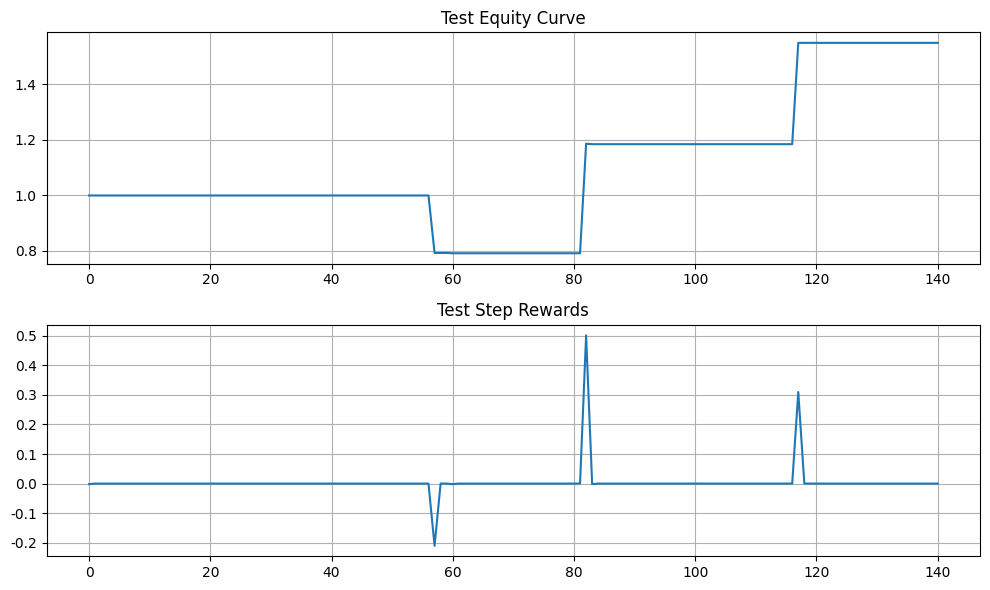

In [39]:
import matplotlib.pyplot as plt
eq = summary['equity']
r  = summary['rewards']
fig, axes = plt.subplots(2,1, figsize=(10,6))
axes[0].plot(eq); axes[0].set_title("Test Equity Curve"); axes[0].grid(True)
axes[1].plot(r);  axes[1].set_title("Test Step Rewards"); axes[1].grid(True)
plt.tight_layout(); plt.show()

In [12]:
import os
import glob
import numpy as np
import pandas as pd
import torch


# 1) 路徑與資料
ckpt_dir = "/content/drive/MyDrive/Kai/envtest/checkpoints_large"
assert os.path.isdir(ckpt_dir), f"找不到目錄：{ckpt_dir}，請確認已掛載 Google Drive 並完成訓練或有現成 checkpoint"


tickers = sorted(list(stock_data.keys()))
ticker_to_idx = {t: i for i, t in enumerate(tickers)}

# 2) 測試區間與 sequence_length
sequence_length = 60
test_start = pd.Timestamp('2025-01-01')
test_end   = pd.Timestamp('2025-08-07')
def pick_checkpoint(path: str):
    # 優先使用最佳表現；否則找 final；再不行找最新的 lstm_*.pth
    candidates = [
        os.path.join(path, "lstm_best_reward.pth"),
        os.path.join(path, "lstm_best_mdd.pth"),
        os.path.join(path, "lstm_final.pth"),
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    files = sorted(glob.glob(os.path.join(path, "lstm_*.pth")), key=os.path.getmtime)
    return files[-1] if files else None

def run_test(env, agent, render=False, max_steps=20000):
    state = env.reset()
    agent.reset_hidden()
    done = False
    total_reward = 0.0
    equity_curve = []
    rewards = []
    steps = 0
    trade_infos = []
    while not done and steps < max_steps:
        action = agent.get_action(state, training=False, keep_hidden=True)
        next_state, reward, done, info = env.step(action)
        state = next_state
        total_reward += reward
        rewards.append(reward)
        equity_curve.append(info.get('equity', env.cumulative_return))
        trade_infos.append(info)
        steps += 1
        if render and steps % 100 == 0:
            env.render()
    # 計算 MDD
    arr = np.array(equity_curve, dtype=float) if len(equity_curve) > 0 else np.array([1.0])
    peak = np.maximum.accumulate(arr)
    mdd = float(np.max((peak - arr) / np.clip(peak, 1e-8, None))) if len(arr) > 0 else 0.0
    return {
        'total_reward': float(total_reward),
        'mdd': float(mdd),
        'equity': equity_curve,
        'rewards': rewards,
        'trades': trade_infos
    }

if len(tickers) == 0:
    raise RuntimeError("stock_data 為空，無法測試。")
for test_ticker in tickers:
    env_test = SingleStockEnv(
        stock_df=stock_data[test_ticker].copy(),
        marco_df=marco_df.copy(),
        industry_df=industry_df.copy(),
        ticker=test_ticker,
        ticker_to_idx=ticker_to_idx,
        start_date=test_start,
        end_date=test_end,
        sequence_length=sequence_length,
        penalty_config={'trade_penalty': 0.0005, 'large_loss_penalty': 0.002, 'overtrade_penalty': 0.001},
        min_holding_days=3,
        stop_loss_pct=0.12,
        cooldown_days_after_force_sell=3,
        take_profit_pct=None,
        max_holding_days=60
    )

    # 4) 建立 agent 並載入最佳或最終 checkpoint
    state_size = env_test.observation_space.shape[-1] if sequence_length > 1 else env_test.observation_space.shape[0]
    agent = LSTMAgent(
        state_size=state_size,
        action_size=3,
        sequence_length=sequence_length,
        hidden_size=256,
        num_layers=2,
        learning_rate=1e-4,
        batch_size=64,
        memory_size=2000,
        chunk_len=8,
        gamma=0.99,
        epsilon=0.0,                # 測試用，不探索
        epsilon_min=0.0,
        epsilon_decay=1.0,
        target_update_freq=2000,
        device=None,
        use_noisy=False,
        reset_epsilon_each_episode=False
    )
    ckpt = pick_checkpoint(ckpt_dir)
    if ckpt is None:
        raise FileNotFoundError(f"在 {ckpt_dir} 找不到任何 checkpoint")
    print("載入 checkpoint:", ckpt)

    # 方案A：顯式 weights_only=False 載入（適用於你自己保存的完整 checkpoint）
    ckpt_obj = torch.load(ckpt, map_location=agent.device, weights_only=False)
    agent.q_network.load_state_dict(ckpt_obj['q_network_state_dict'], strict=False)
    agent.target_network.load_state_dict(ckpt_obj['target_network_state_dict'], strict=False)
    # 測試時不需要 optimizer/buffer，以下可省略
    agent.epsilon = 0.0
    agent.training_step = ckpt_obj.get('training_step', 0)
    summary = run_test(env_test, agent, render=False)
    print("-"* 60)
    print(f"[Test] ticker={test_ticker} steps={len(summary['equity'])} total_reward={summary['total_reward']:+.6f} MDD={summary['mdd']:.6f}")
    print("-"* 60)



/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.industry_df = self.industry_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version.

載入 checkpoint: /content/drive/MyDrive/Kai/envtest/checkpoints_large/lstm_best_reward.pth


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------------------------
[Test] ticker=1216 steps=141 total_reward=+0.078757 MDD=0.045813
------------------------------------------------------------


/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.industry_df = self.industry_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version.

...

------------------------------------------------------------
[Test] ticker=5880 steps=141 total_reward=+0.023049 MDD=0.026342
------------------------------------------------------------


/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.industry_df = self.industry_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version.

載入 checkpoint: /content/drive/MyDrive/Kai/envtest/checkpoints_large/lstm_best_reward.pth


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------------------------
[Test] ticker=6669 steps=141 total_reward=+0.250043 MDD=0.272706
------------------------------------------------------------


Will test 30 tickers: ['1216', '2303', '2308', '2317', '2330', '2345', '2357', '2379', '2382', '2383']...


Testing tickers:   0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.industry_df = self.industry_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is de

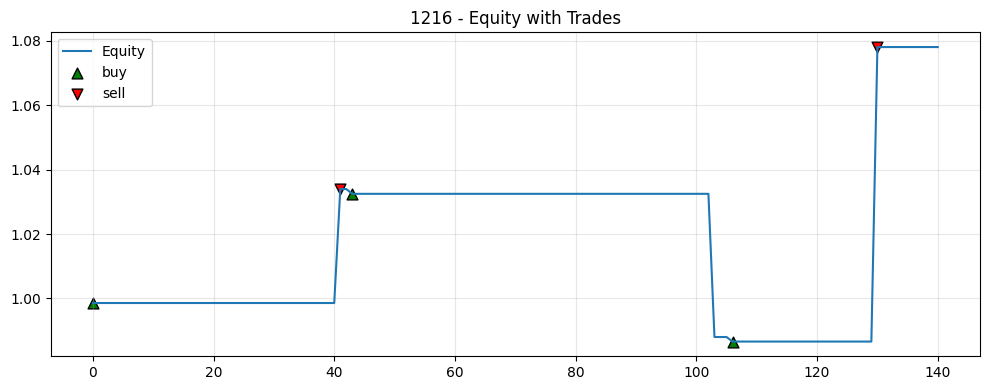

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:   3%|▎         | 1/30 [00:01<00:41,  1.44s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna wi

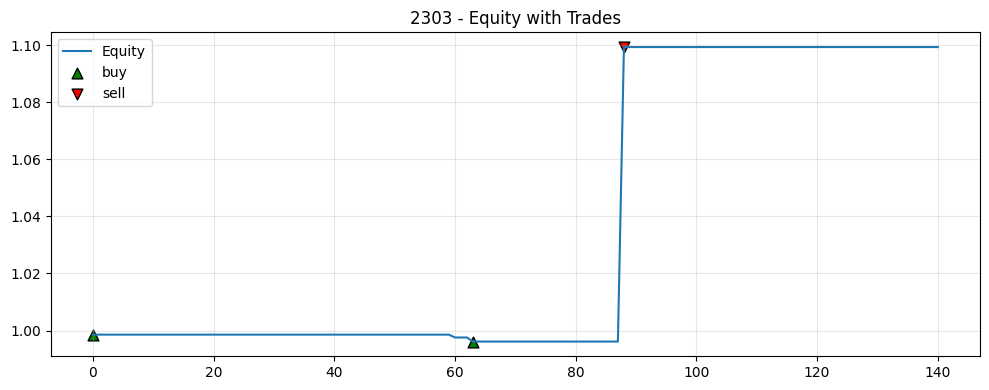

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:   7%|▋         | 2/30 [00:02<00:37,  1.33s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna wi

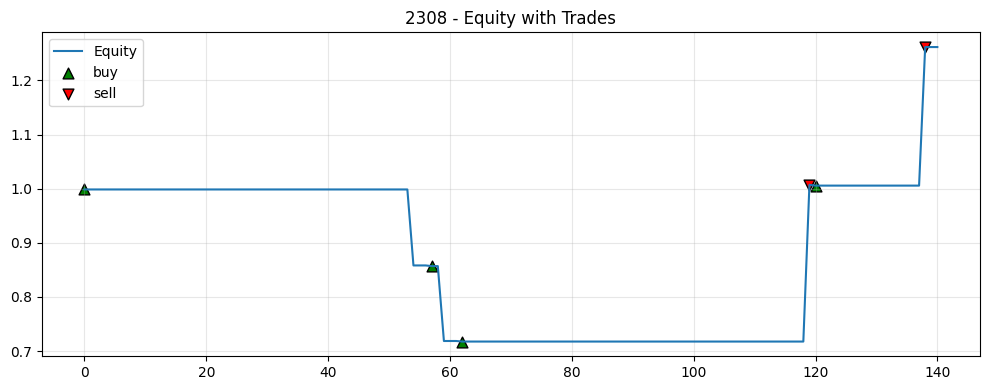

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  10%|█         | 3/30 [00:03<00:35,  1.30s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna wi

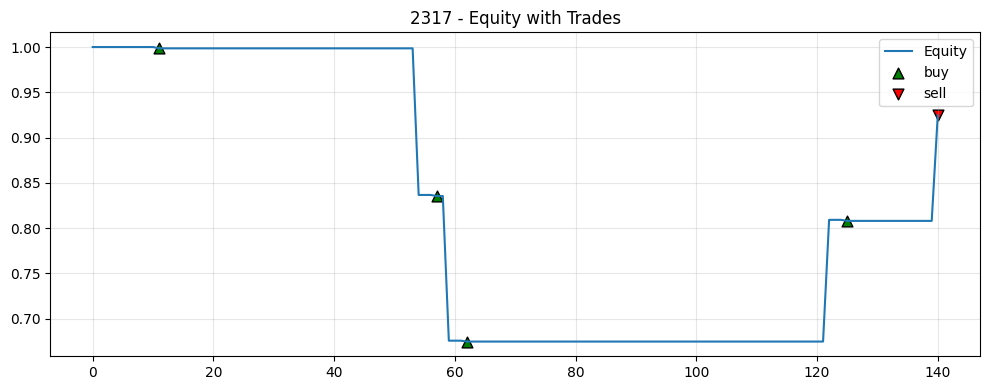

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  13%|█▎        | 4/30 [00:05<00:33,  1.28s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna wi

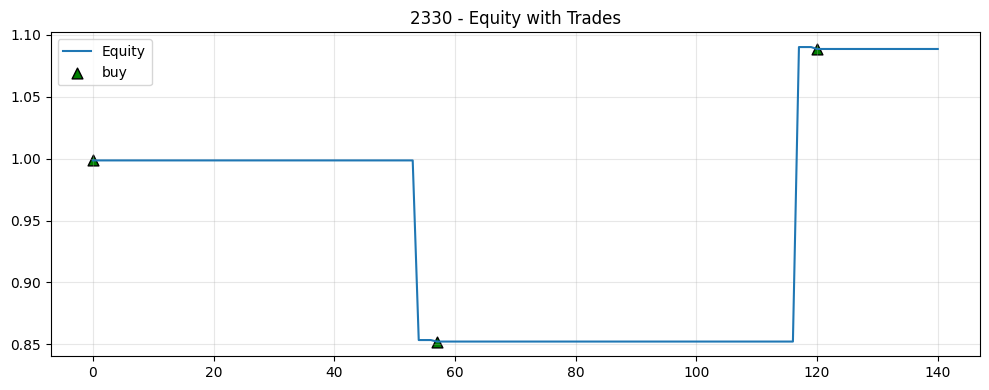

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  17%|█▋        | 5/30 [00:06<00:31,  1.26s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna wi

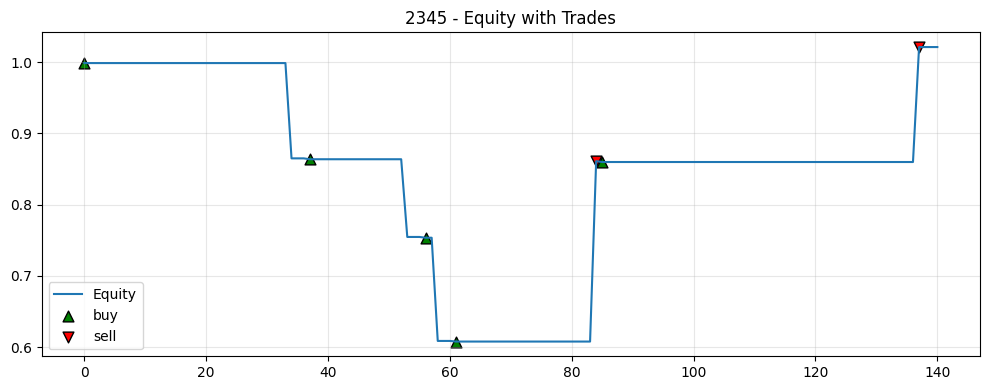

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  20%|██        | 6/30 [00:07<00:30,  1.26s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna wi

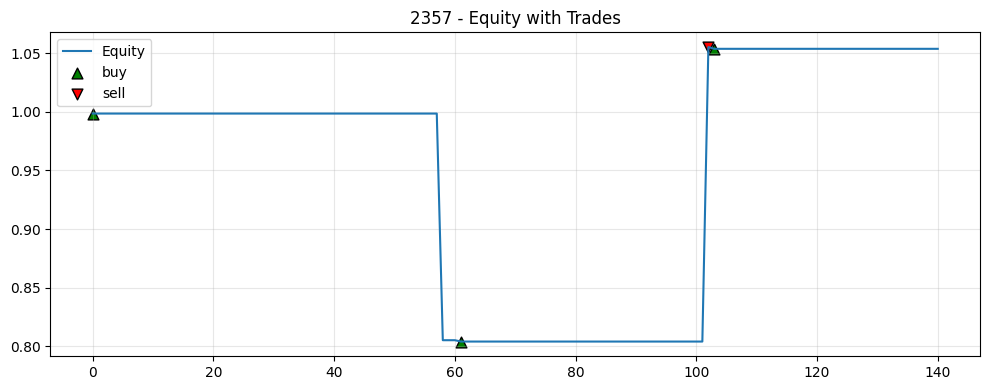

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  23%|██▎       | 7/30 [00:08<00:28,  1.25s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna wi

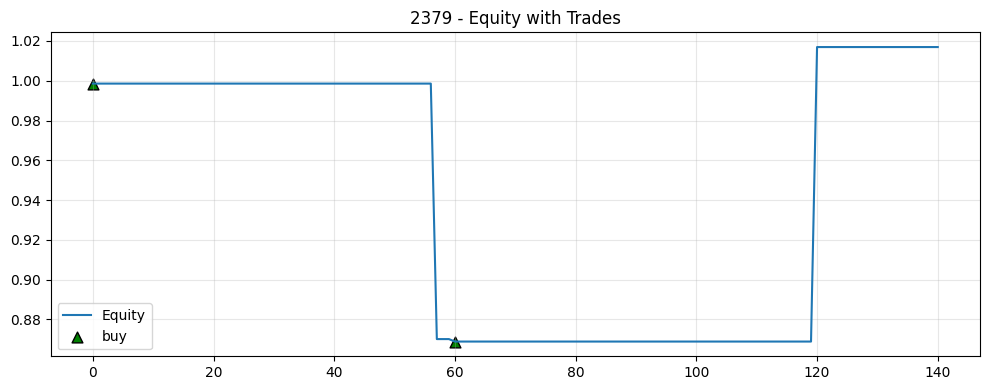

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  27%|██▋       | 8/30 [00:10<00:27,  1.24s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna wi

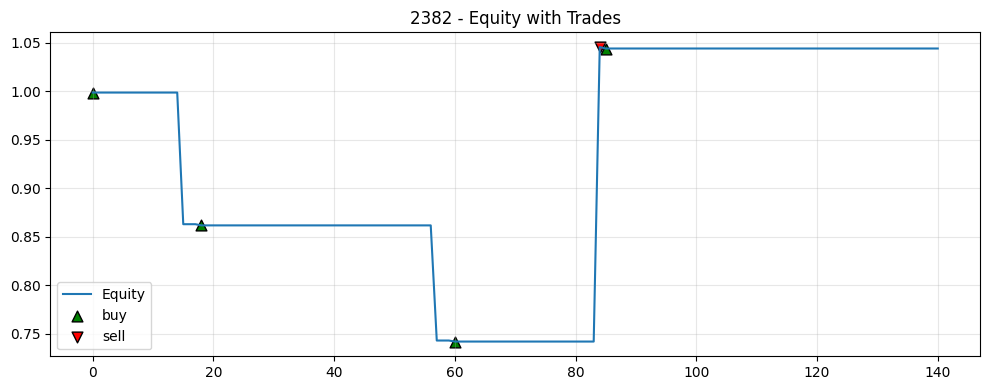

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  30%|███       | 9/30 [00:11<00:26,  1.25s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna wi

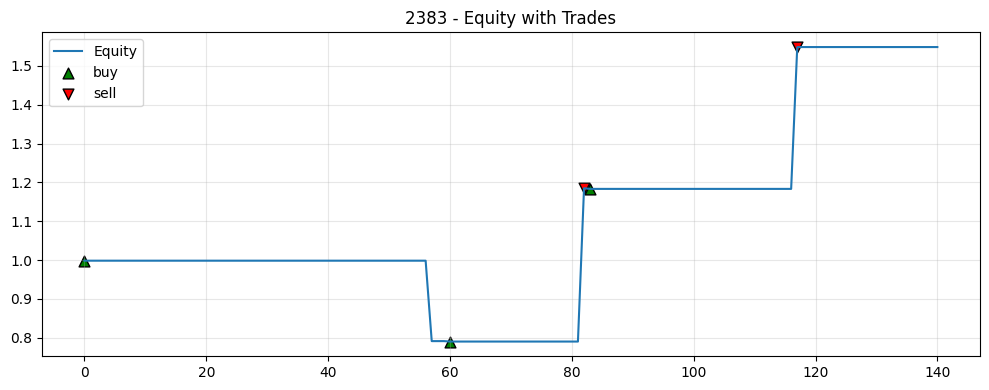

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  33%|███▎      | 10/30 [00:12<00:25,  1.29s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

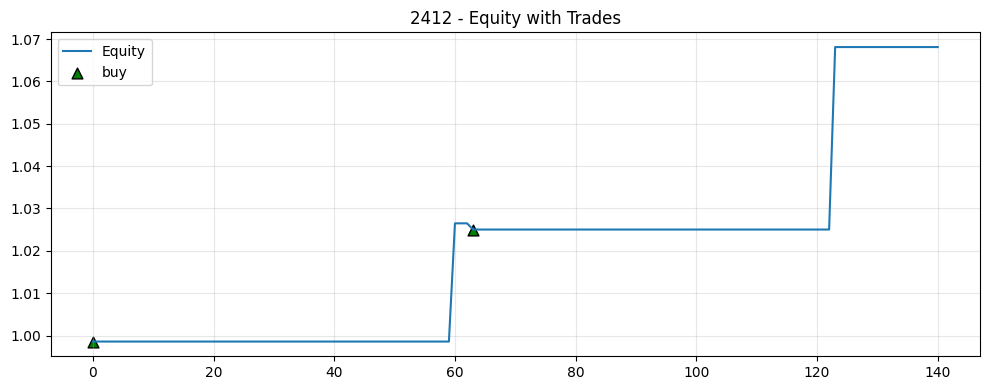

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  37%|███▋      | 11/30 [00:14<00:24,  1.28s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

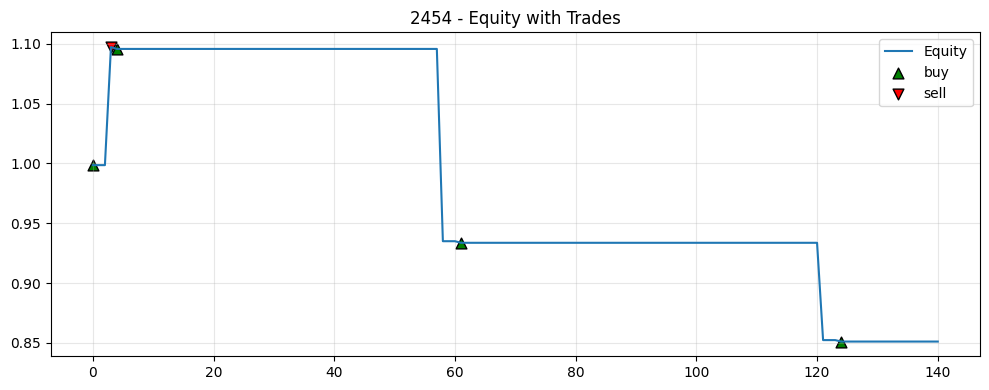

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  40%|████      | 12/30 [00:15<00:22,  1.28s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

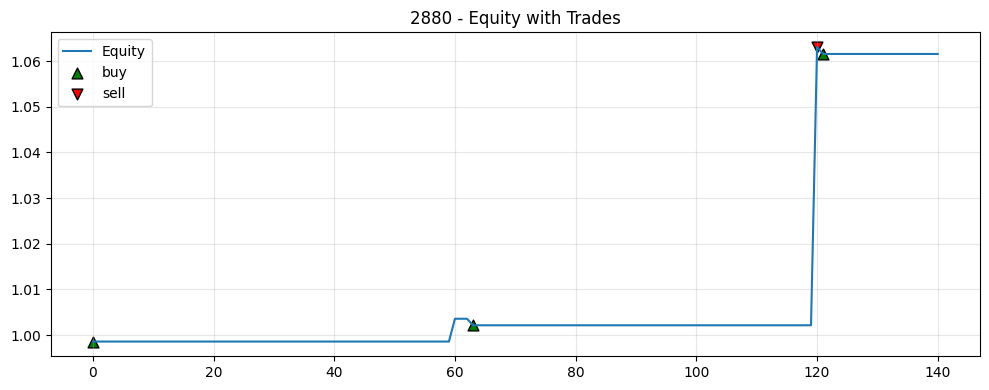

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  43%|████▎     | 13/30 [00:16<00:21,  1.27s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

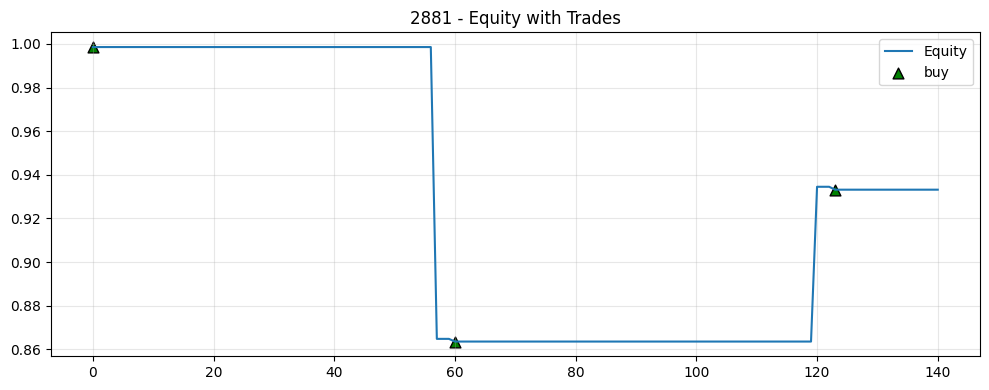

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  47%|████▋     | 14/30 [00:17<00:20,  1.26s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

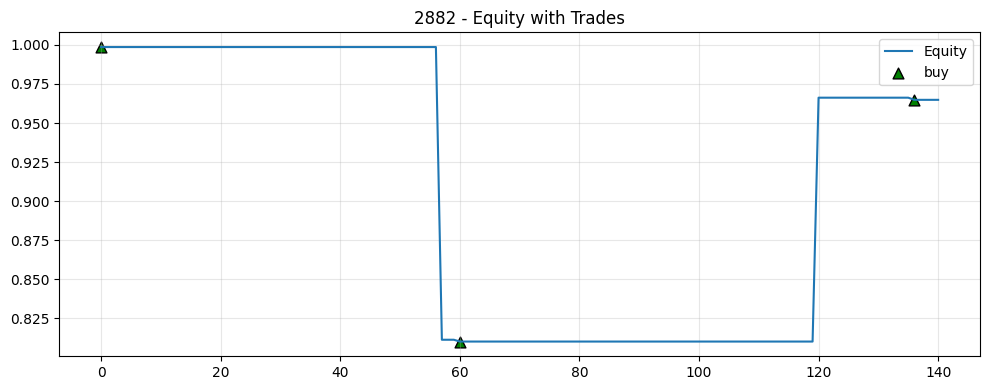

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  50%|█████     | 15/30 [00:18<00:18,  1.24s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

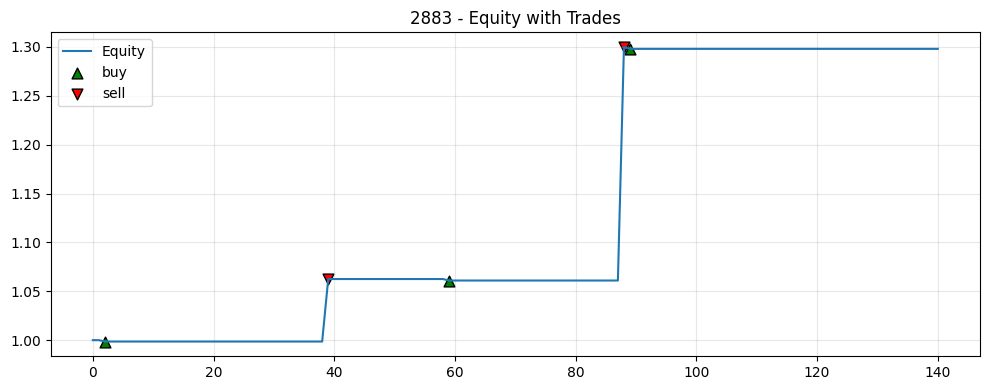

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  53%|█████▎    | 16/30 [00:20<00:17,  1.24s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

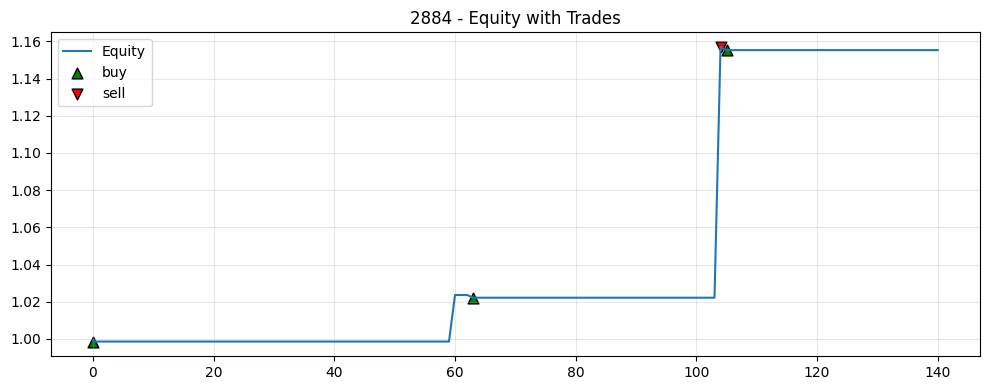

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  57%|█████▋    | 17/30 [00:21<00:16,  1.25s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

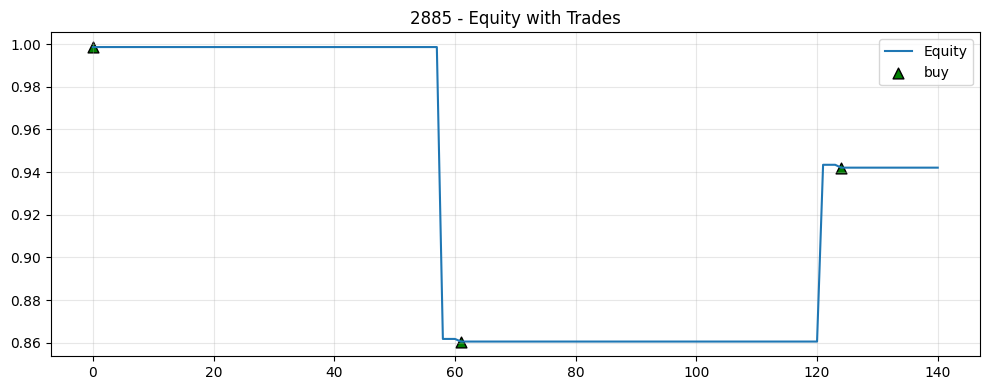

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  60%|██████    | 18/30 [00:22<00:14,  1.25s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

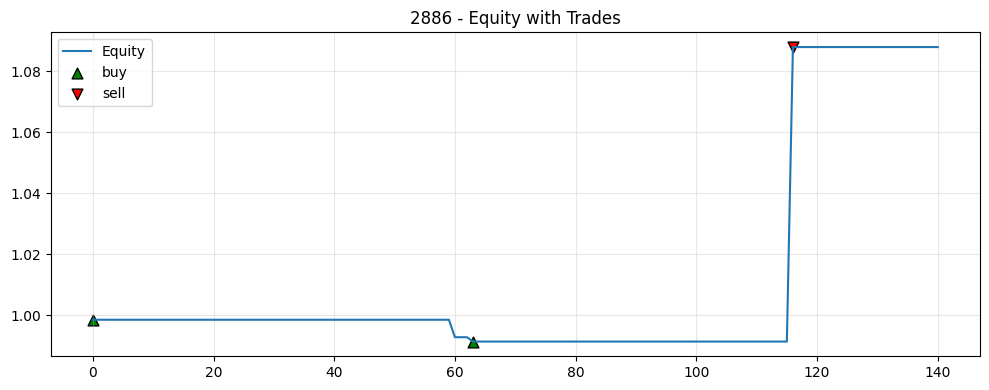

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  63%|██████▎   | 19/30 [00:24<00:14,  1.32s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

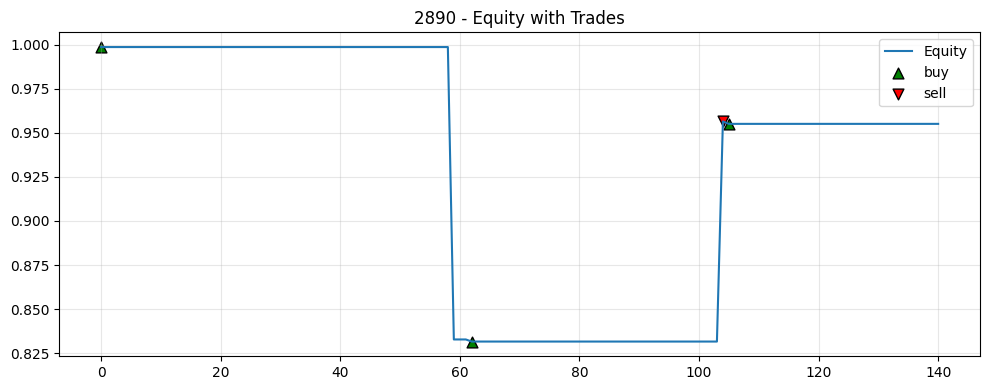

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  67%|██████▋   | 20/30 [00:25<00:13,  1.30s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

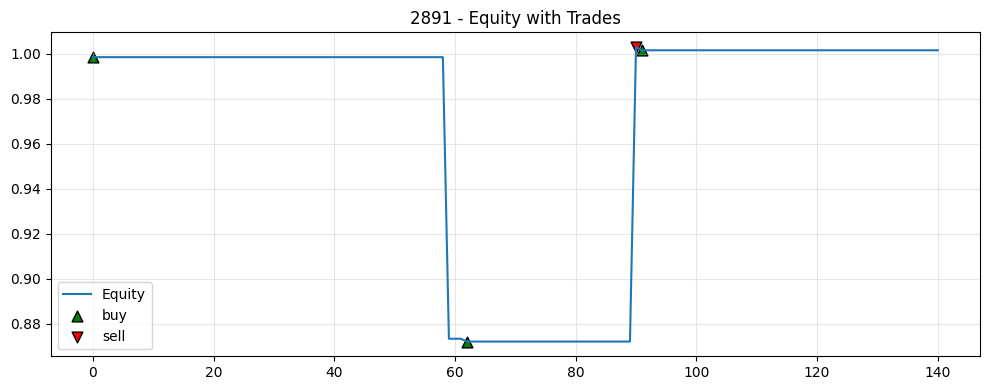

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  70%|███████   | 21/30 [00:26<00:11,  1.29s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

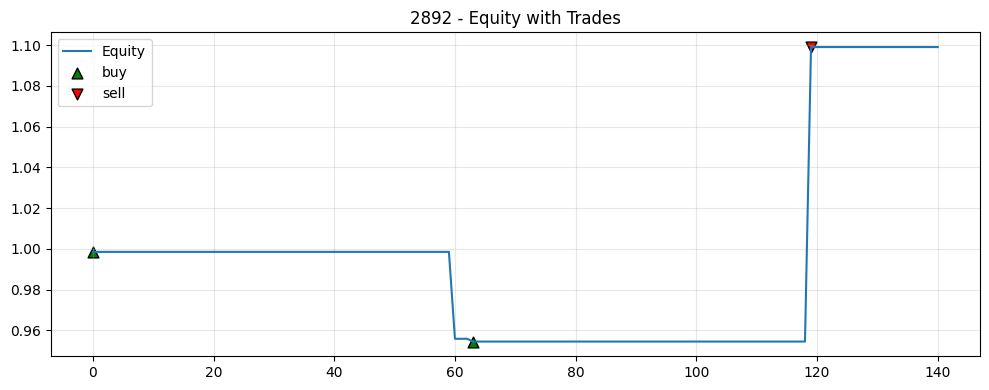

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  73%|███████▎  | 22/30 [00:27<00:10,  1.27s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

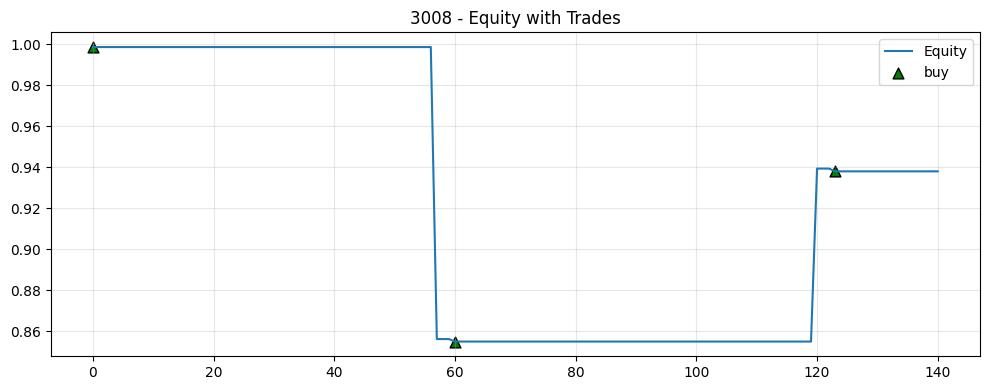

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  77%|███████▋  | 23/30 [00:29<00:09,  1.38s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

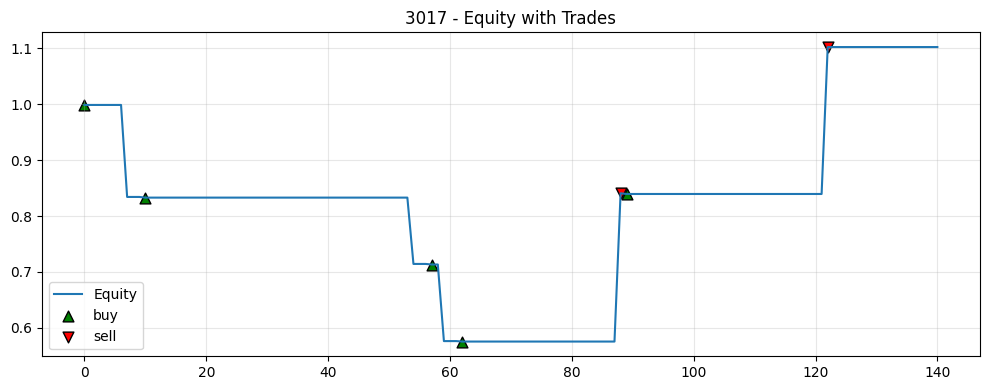

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  80%|████████  | 24/30 [00:30<00:08,  1.33s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

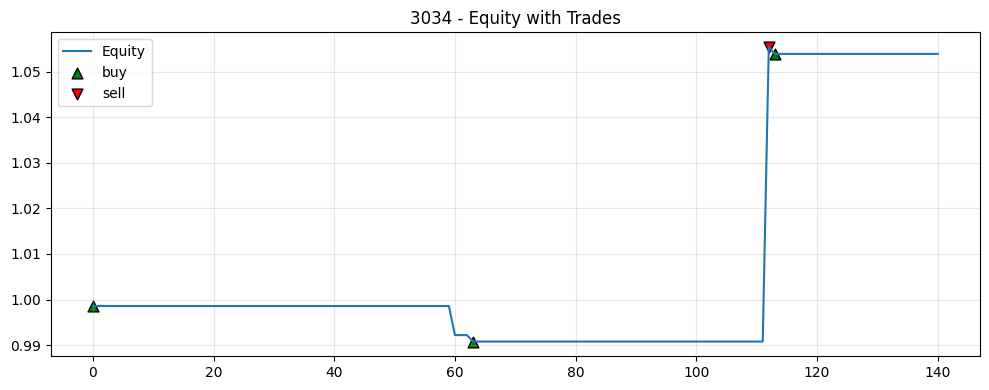

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  83%|████████▎ | 25/30 [00:32<00:06,  1.31s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

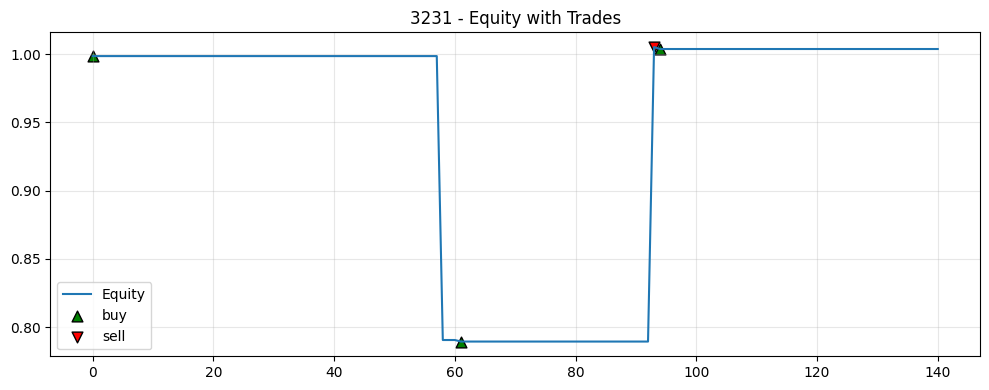

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  87%|████████▋ | 26/30 [00:33<00:05,  1.28s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

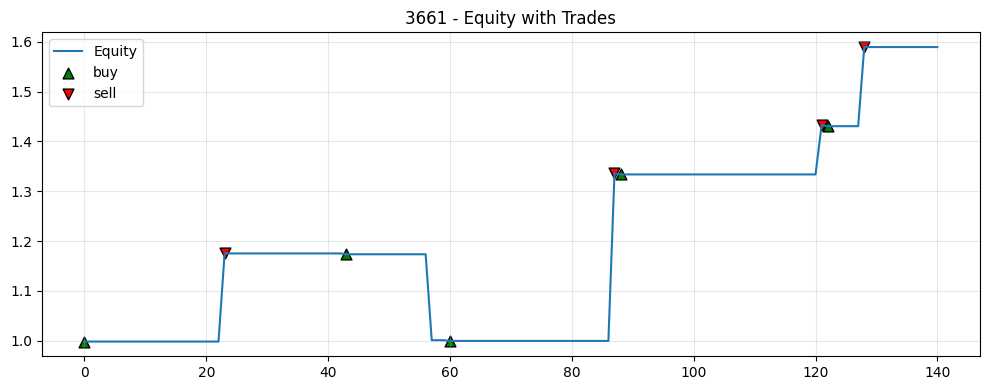

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  90%|█████████ | 27/30 [00:34<00:03,  1.28s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

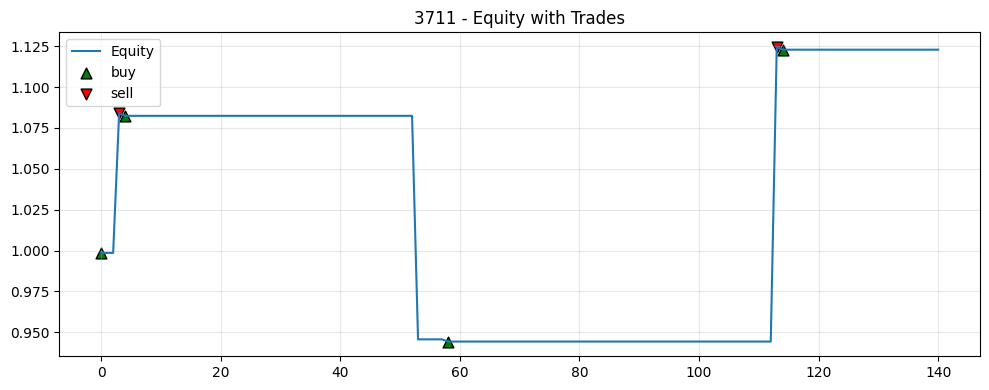

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  93%|█████████▎| 28/30 [00:35<00:02,  1.28s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

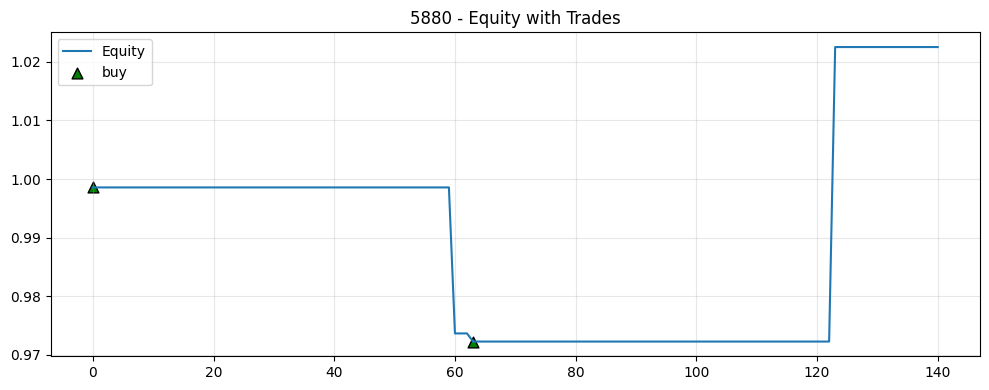

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers:  97%|█████████▋| 29/30 [00:37<00:01,  1.27s/it]/tmp/ipython-input-2978039777.py:168: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.stock_df = self.stock_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:169: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.marco_df = self.marco_df.sort_values('date').fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2978039777.py:170: FutureWarning: DataFrame.fillna w

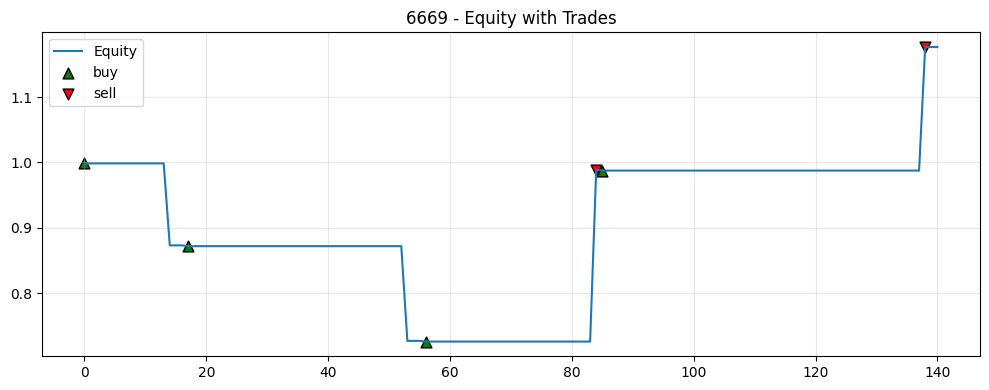

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Testing tickers: 100%|██████████| 30/30 [00:38<00:00,  1.28s/it]


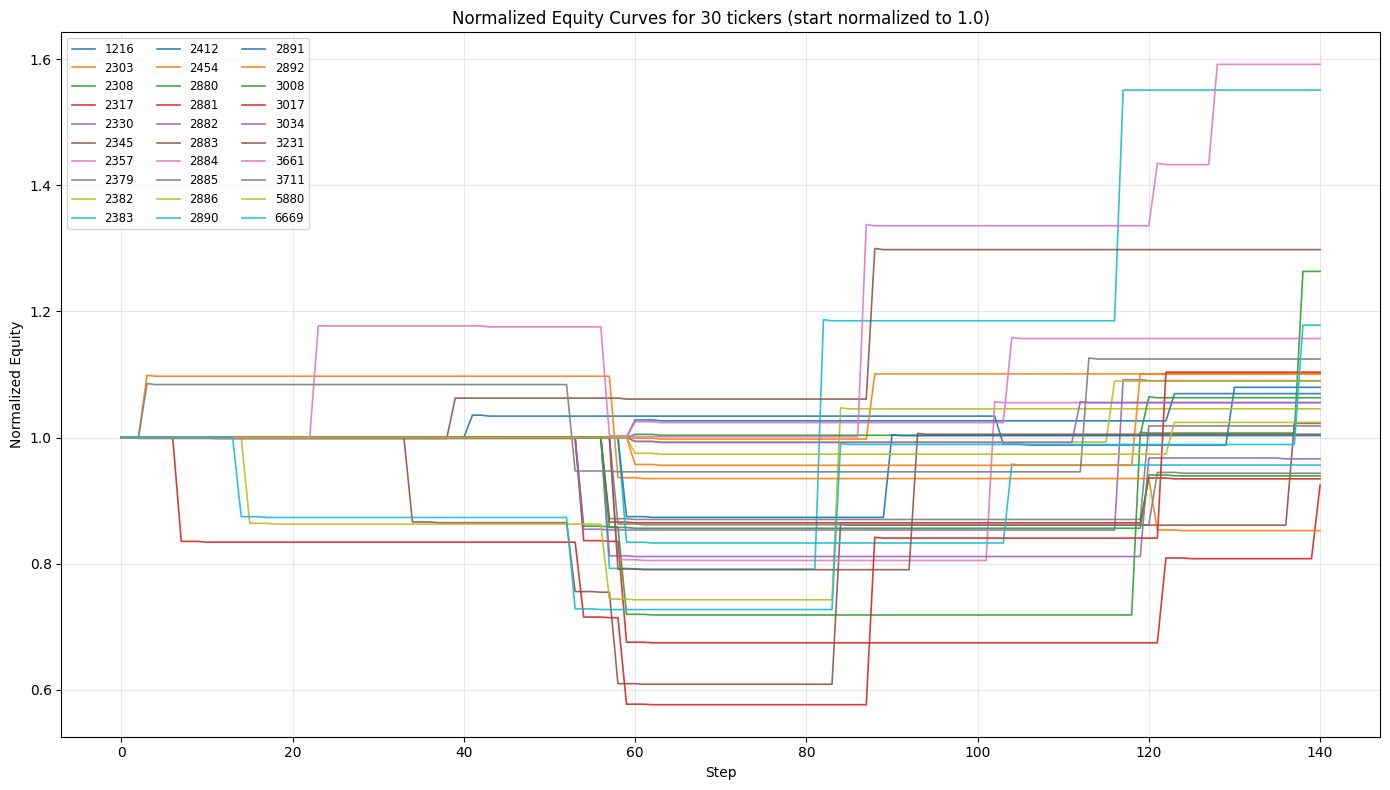

In [13]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

N = 30
tickers_to_test = tickers[:N] if len(tickers) >= N else tickers.copy()
print(f"Will test {len(tickers_to_test)} tickers: {tickers_to_test[:10]}{'...' if len(tickers_to_test)>10 else ''}")

def run_test_single_env(env, agent, max_steps=20000):
    state = env.reset()
    agent.reset_hidden()
    done = False
    total_reward = 0.0
    equity_curve = []
    rewards = []
    steps = 0
    trade_infos = []
    while not done and steps < max_steps:
        action = agent.get_action(state, training=False, keep_hidden=True)
        next_state, reward, done, info = env.step(action)
        state = next_state
        total_reward += reward
        rewards.append(reward)
        equity_curve.append(info.get('equity', env.cumulative_return))
        trade_infos.append(info)
        steps += 1
    # compute mdd
    arr = np.array(equity_curve, dtype=float) if len(equity_curve) > 0 else np.array([1.0])
    peak = np.maximum.accumulate(arr)
    mdd = float(np.max((peak - arr) / np.clip(peak, 1e-8, None))) if len(arr) > 0 else 0.0
    return {
        'total_reward': float(total_reward),
        'mdd': float(mdd),
        'equity': equity_curve,
        'rewards': rewards,
        'trades': trade_infos
    }

# 儲存所有結果
all_results = {}

# 逐檔測試並繪圖（單檔：equity 與買賣點）
for tk in tqdm(tickers_to_test, desc="Testing tickers"):
    env = SingleStockEnv(
        stock_df=stock_data[tk].copy(),
        marco_df=marco_df.copy(),
        industry_df=industry_df.copy(),
        ticker=tk,
        ticker_to_idx=ticker_to_idx,
        start_date=test_start,
        end_date=test_end,
        sequence_length=sequence_length,
        penalty_config={'trade_penalty': 0.0005, 'large_loss_penalty': 0.002, 'overtrade_penalty': 0.001},
        min_holding_days=3,
        stop_loss_pct=0.12,
        cooldown_days_after_force_sell=3,
        take_profit_pct=None,
        max_holding_days=60
    )

    res = run_test_single_env(env, agent, max_steps=20000)
    all_results[tk] = res

    eq = res['equity']
    if len(eq) == 0:
        print(f"{tk}: no steps/equity returned.")
        continue

    try:
        plot_equity_with_trades(eq, res['trades'], title=f"{tk} - Equity with Trades (len={len(eq)})")
    except Exception as e:
        # fallback simple plot
        xs = range(len(eq))
        plt.figure(figsize=(10,4))
        plt.plot(xs, eq, label='Equity')
        buy_idx = [i for i,info in enumerate(res['trades']) if info.get('event')=='buy']
        sell_idx = [i for i,info in enumerate(res['trades']) if info.get('event')=='sell']
        if buy_idx:
            plt.scatter(buy_idx, [eq[i] for i in buy_idx], color='g', marker='^', s=60, label='buy', edgecolor='k')
        if sell_idx:
            plt.scatter(sell_idx, [eq[i] for i in sell_idx], color='r', marker='v', s=60, label='sell', edgecolor='k')
        plt.title(f"{tk} - Equity with Trades")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# 現在畫 30 檔股票的資產成長圖（同一張圖）
plt.figure(figsize=(14,8))
for i, tk in enumerate(tickers_to_test):
    res = all_results[tk]
    eq = np.array(res['equity'], dtype=float)
    if len(eq) == 0:
        continue
    # 常態化：讓每條曲線起點為 1.0（或保留原值）
    eq_norm = eq / eq[0] if eq[0] != 0 else eq
    plt.plot(eq_norm, label=tk, linewidth=1.2, alpha=0.9)

plt.title(f"Normalized Equity Curves for {len(tickers_to_test)} tickers (start normalized to 1.0)")
plt.xlabel("Step")
plt.ylabel("Normalized Equity")
plt.legend(ncol=3, fontsize='small', loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 若你想要把每檔的 equity/trades 存為 CSV，下面是範例（可選）
save_csv = False
if save_csv:
    out_dir = "/content/drive/MyDrive/Kai/envtest/test_results"
    os.makedirs(out_dir, exist_ok=True)
    for tk, res in all_results.items():
        df = pd.DataFrame({
            'equity': pd.Series(res['equity']),
            'reward': pd.Series(res['rewards'])
        })
        # 將 trades info 展平（只存 event 與 price 與 date 每 step）
        events = [t.get('event') if isinstance(t, dict) else None for t in res['trades']]
        prices = [t.get('event_price') if isinstance(t, dict) else None for t in res['trades']]
        dates  = [t.get('observation_date') if isinstance(t, dict) else None for t in res['trades']]
        df['event'] = events
        df['event_price'] = prices
        df['date'] = dates
        df.to_csv(os.path.join(out_dir, f"{tk}_test.csv"), index=False)
    print("Saved CSVs to", out_dir)

Found 23 profitable tickers (final equity > 1.0).
Plotting single equity+trade charts for: ['1216', '2303', '2308', '2330', '2345', '2357', '2379', '2382', '2383', '2412', '2880', '2883', '2884', '2886', '2891', '2892', '3017', '3034', '3231', '3661', '3711', '5880', '6669']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


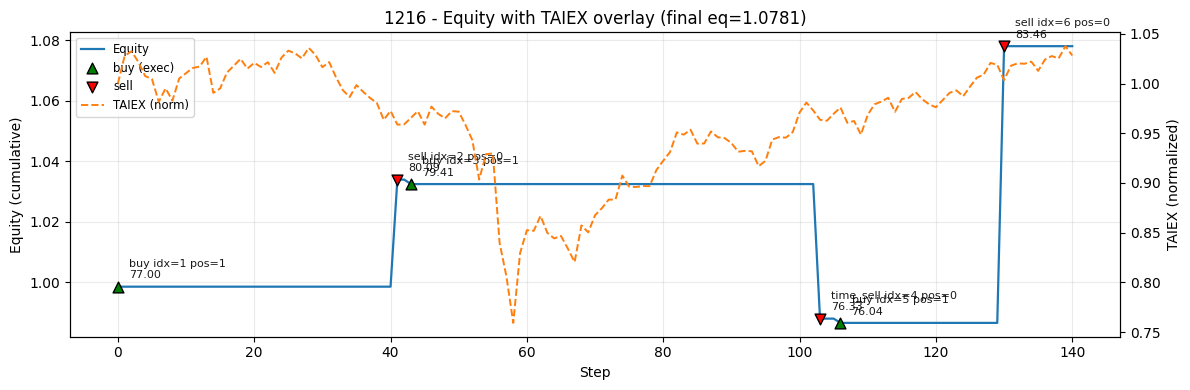

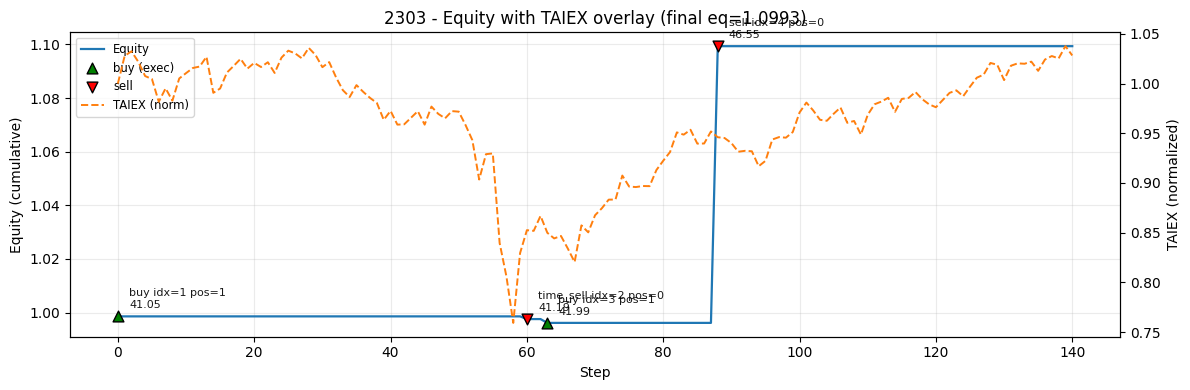

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


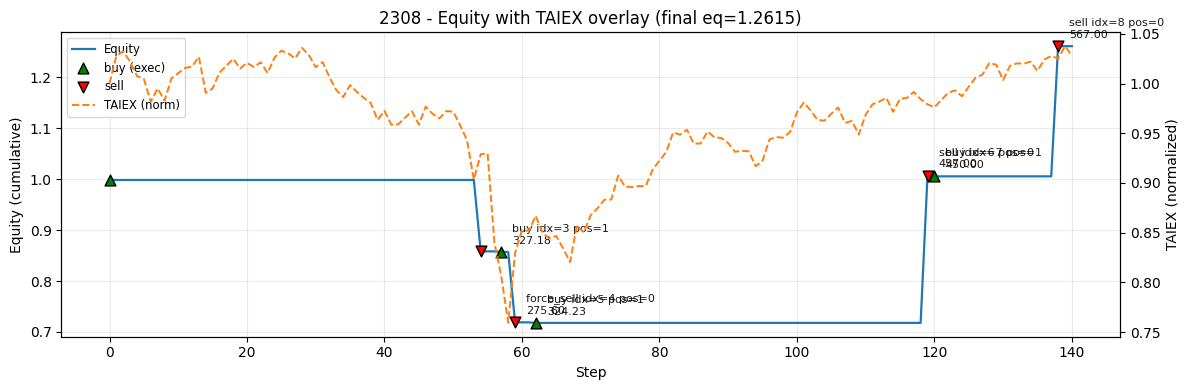

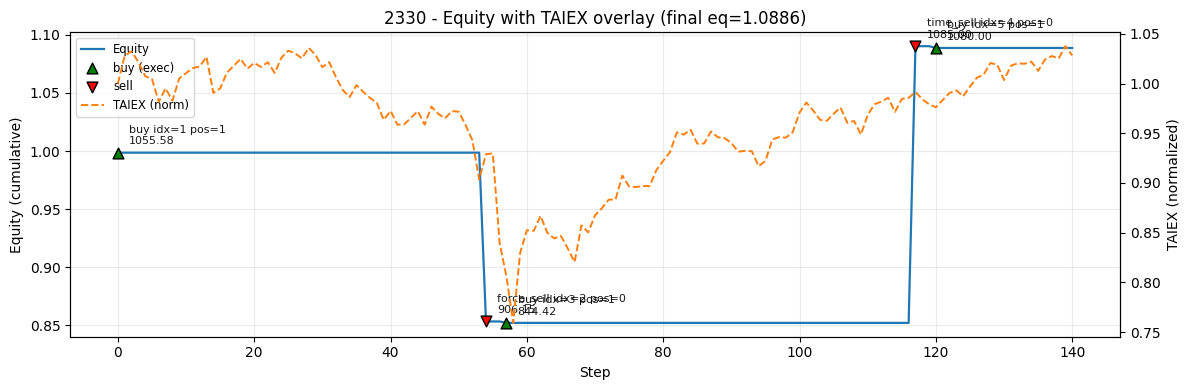

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


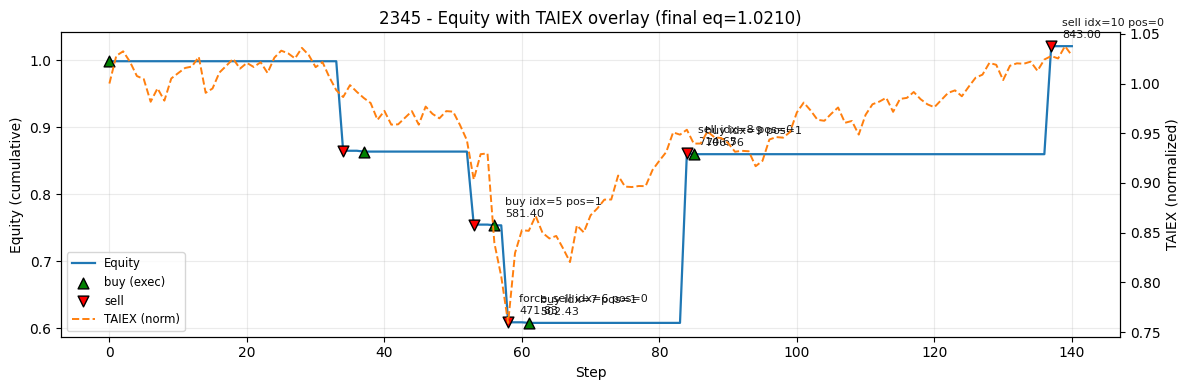

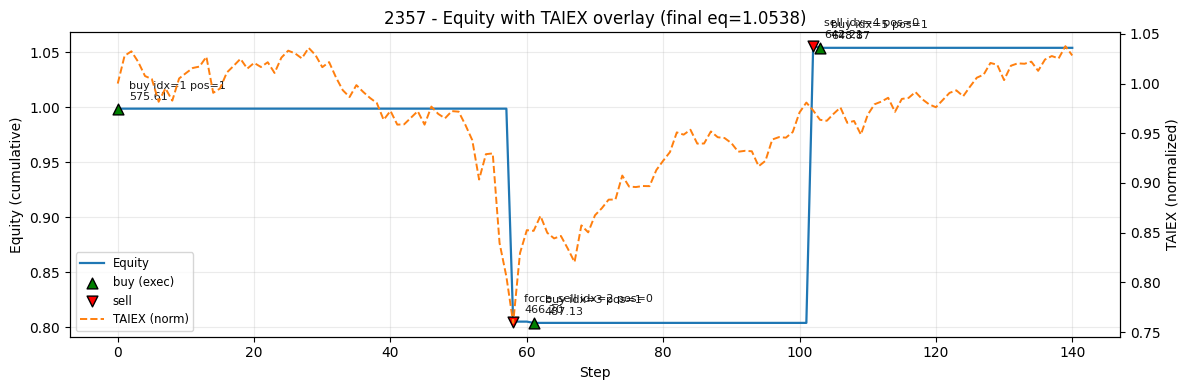

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


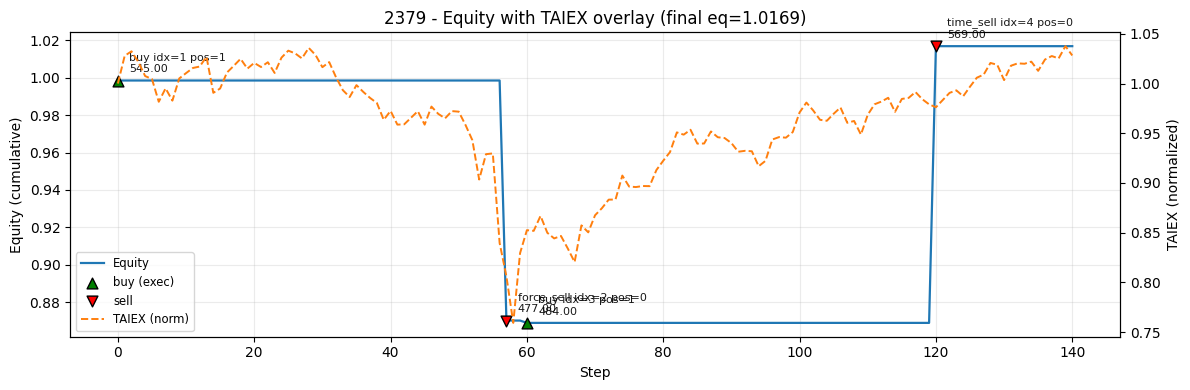

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


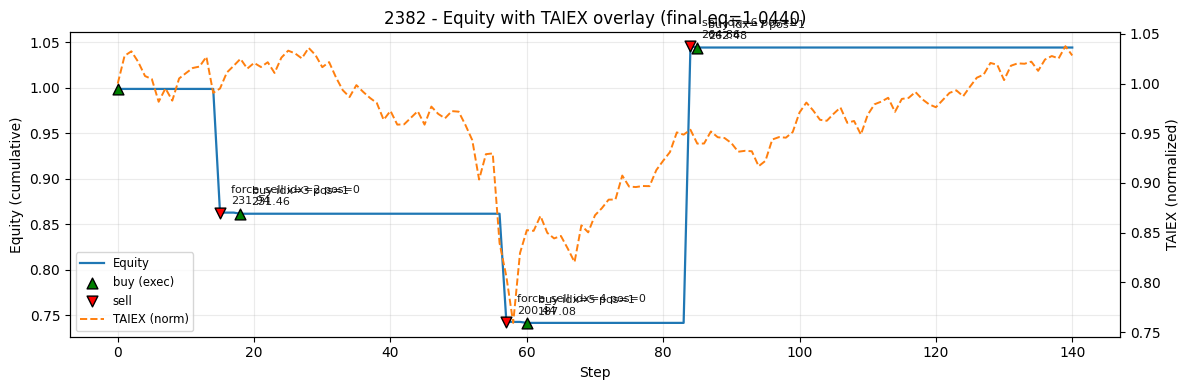

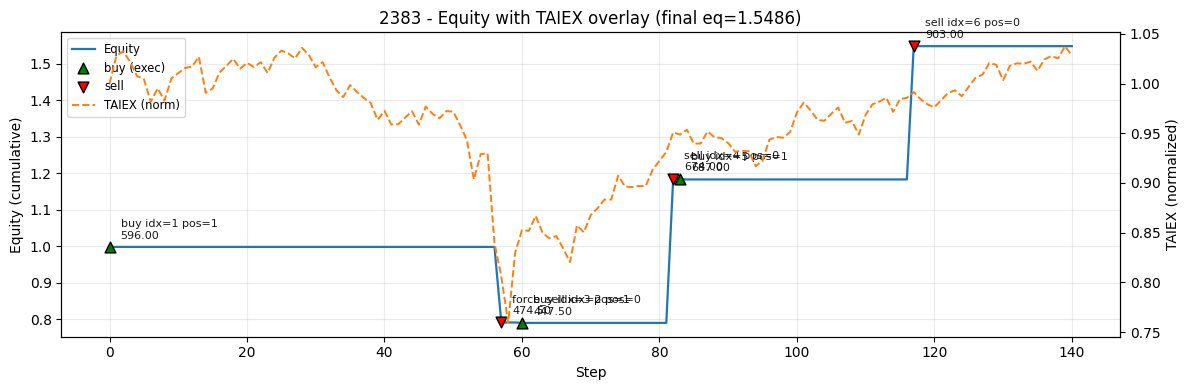

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


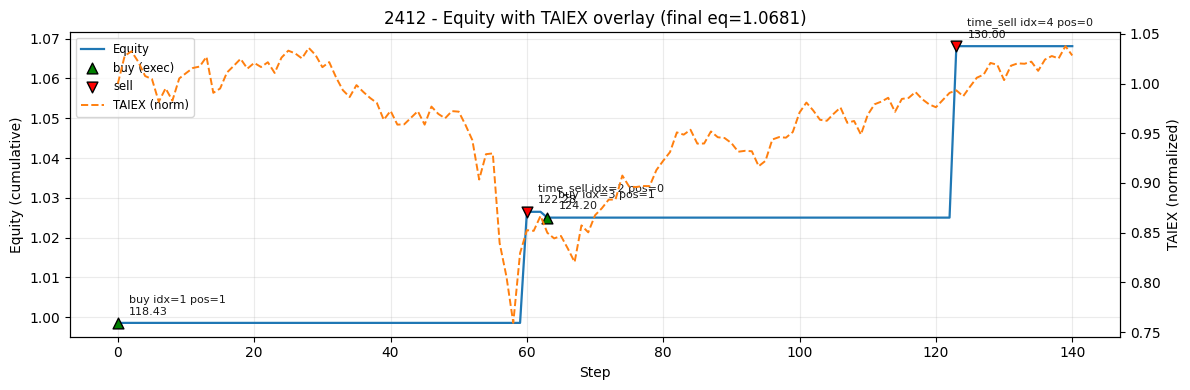

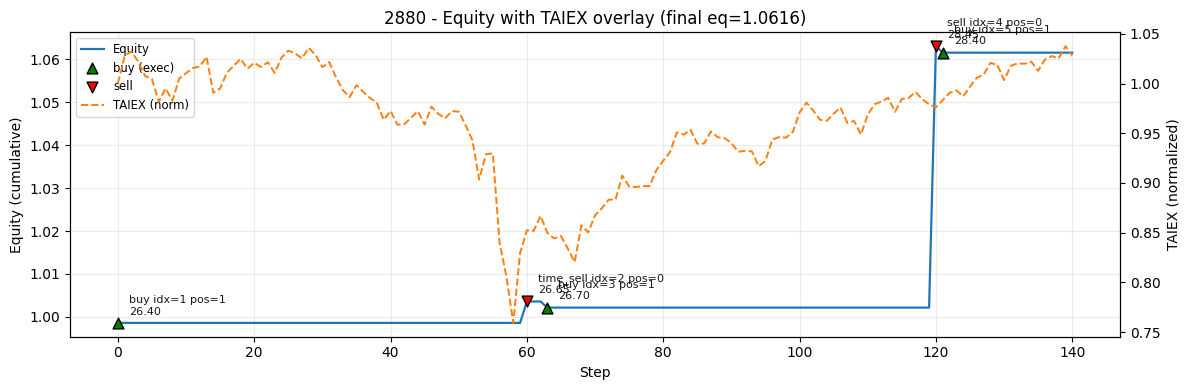

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


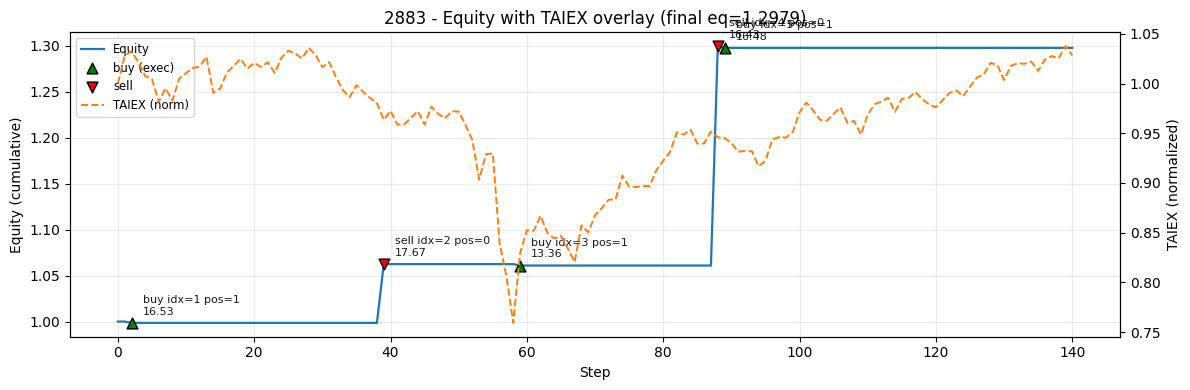

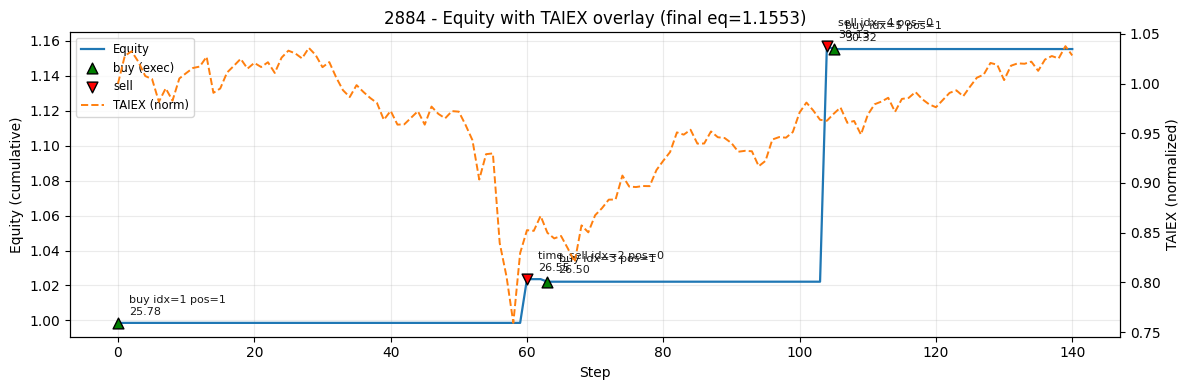

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


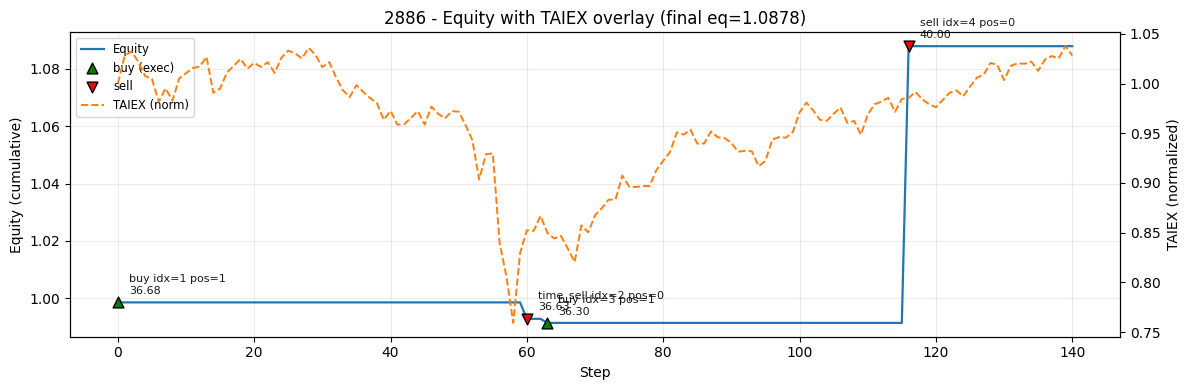

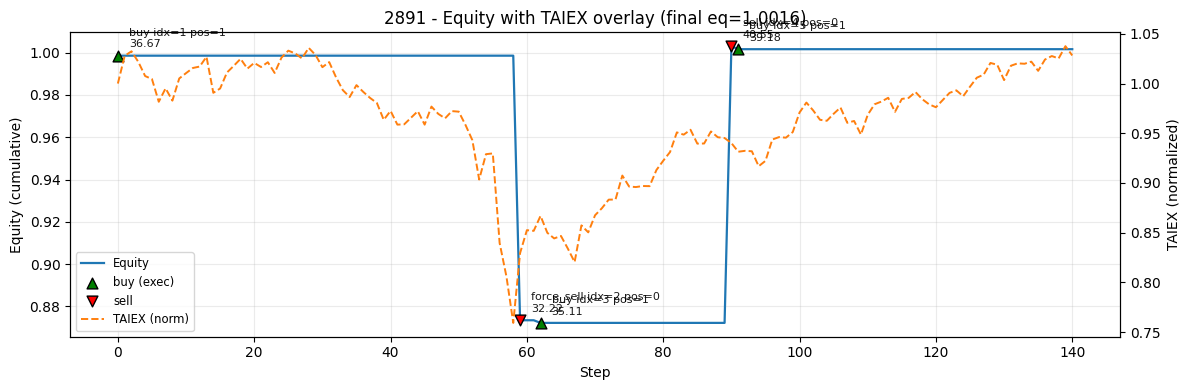

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


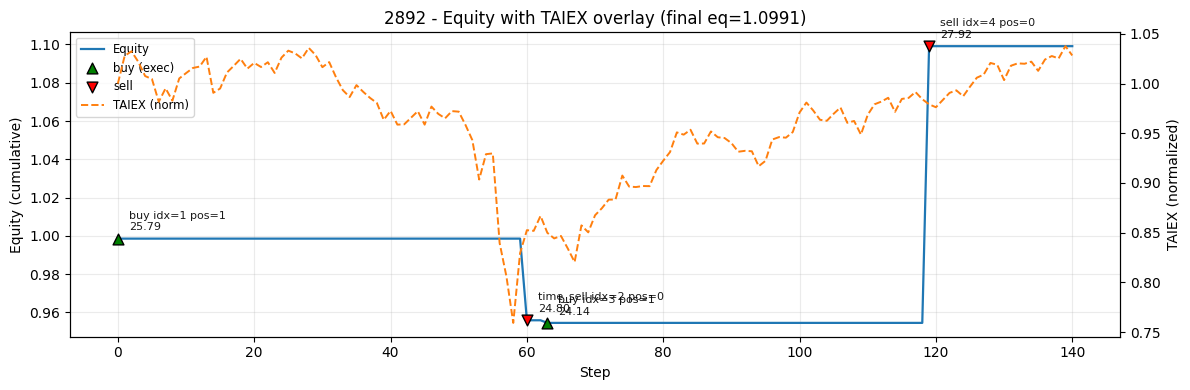

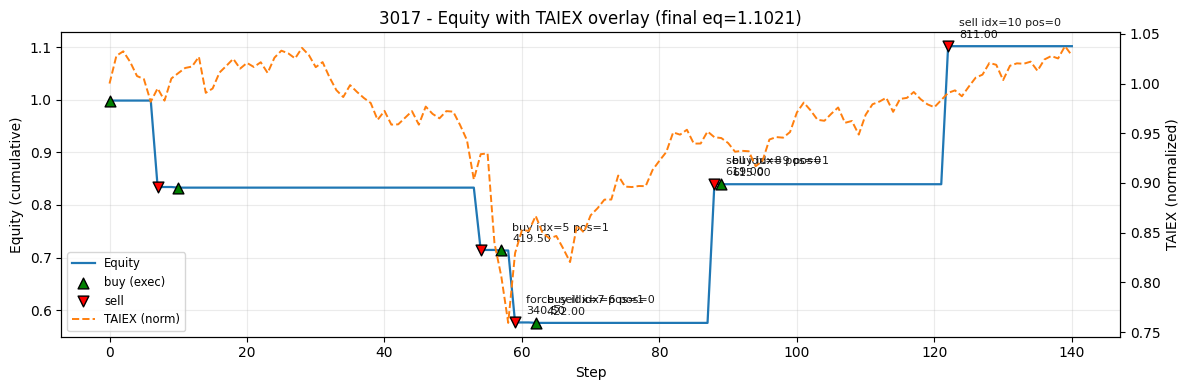

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


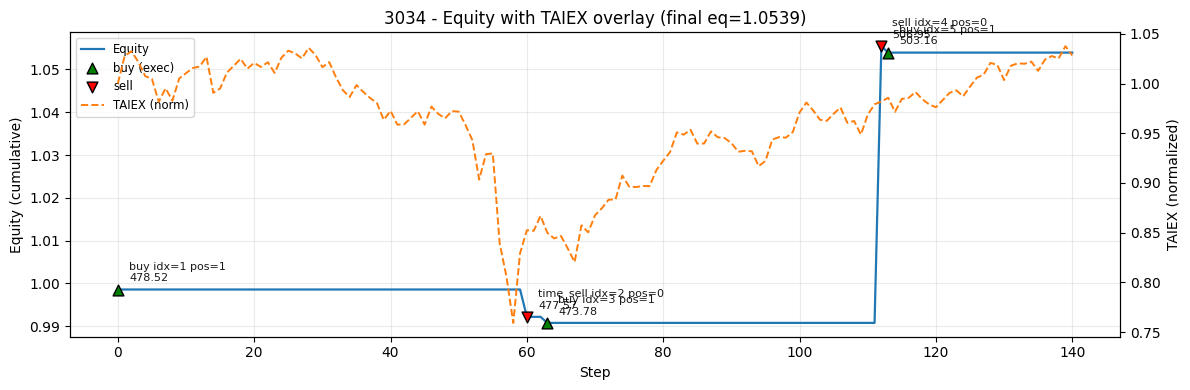

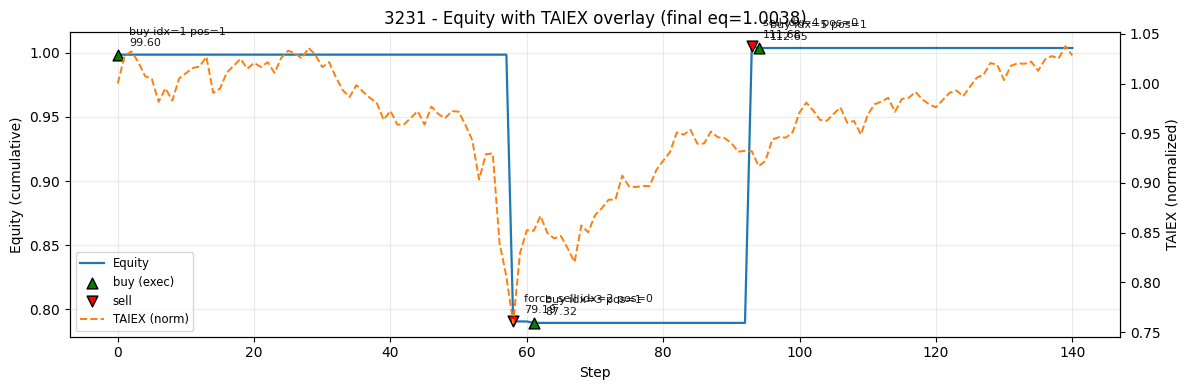

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


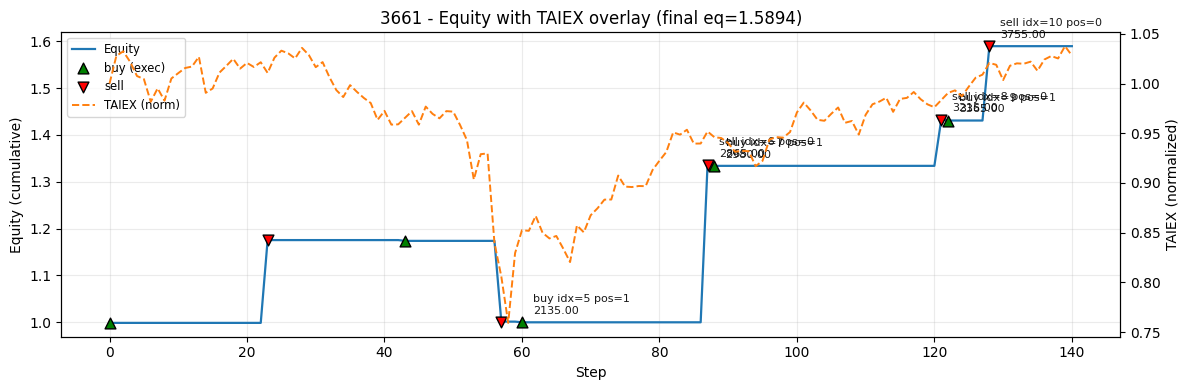

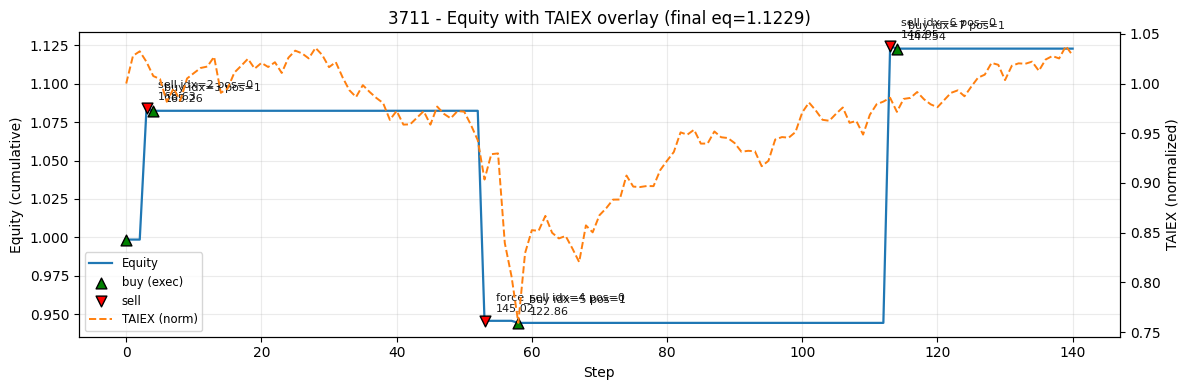

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


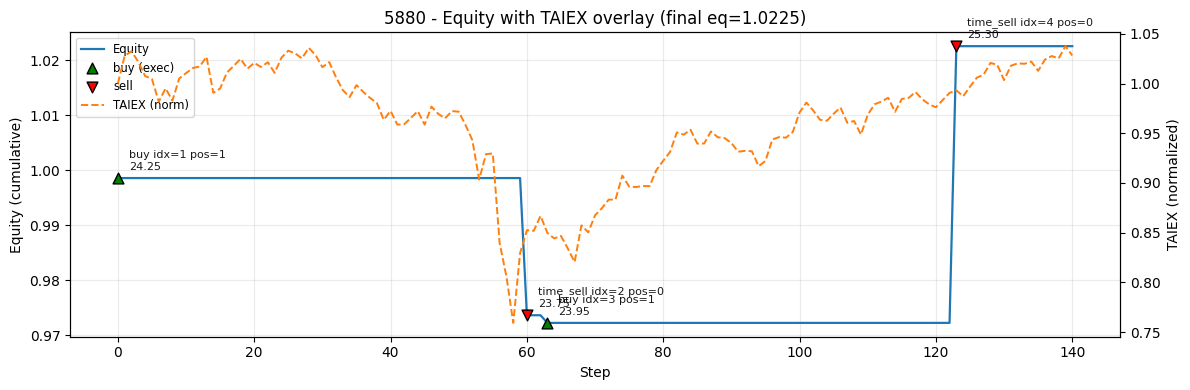

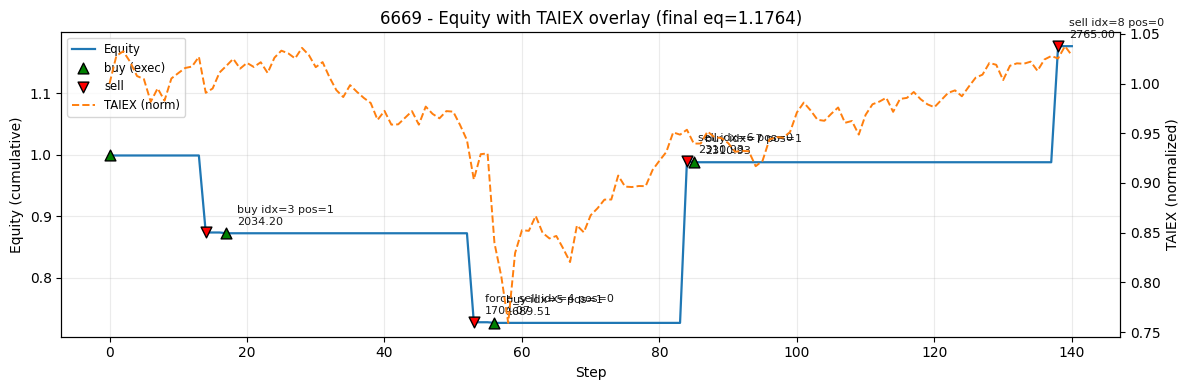

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


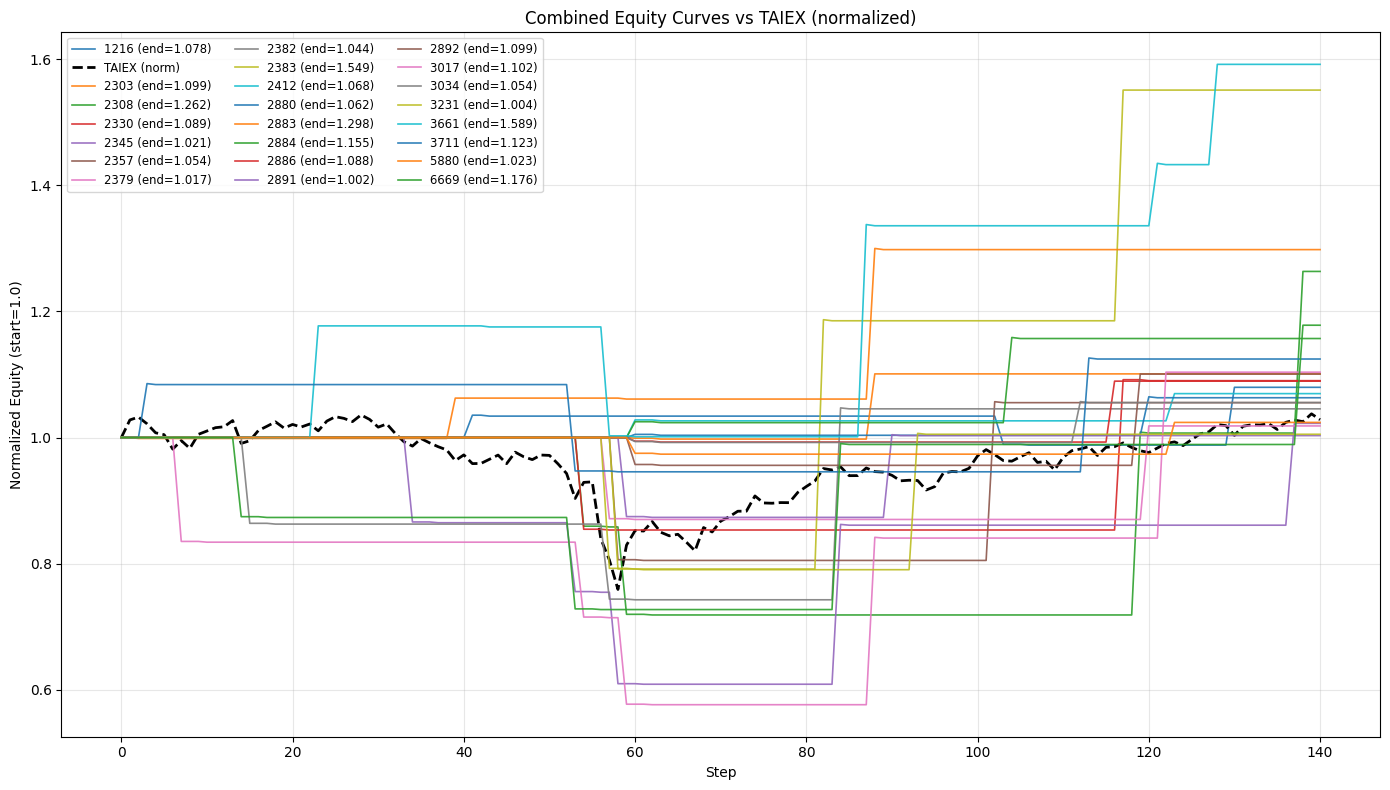

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import List, Dict

# 若沒有 all_results，嘗試用 single summary
try:
    all_results
except NameError:
    try:
        all_results = {test_ticker: summary}
        print("Wrapped single summary into all_results.")
    except Exception as e:
        raise RuntimeError("找不到 all_results，也沒有 summary/test_ticker 可用。請先執行測試迴圈產生 all_results 或傳入 summary/test_ticker。") from e

# 確認 industry_df 有 date 欄位
if 'date' not in industry_df.columns and 'Date' in industry_df.columns:
    industry_df = industry_df.rename(columns={'Date':'date'})
industry_df['date'] = pd.to_datetime(industry_df['date'])

# helper: 將 trades list 轉成 DataFrame
def trades_to_df(trades: List[dict]) -> pd.DataFrame:
    rows = []
    cum_trades = 0
    for i, t in enumerate(trades):
        evt = t.get('event', 'hold')
        price = t.get('event_price', None)
        date = t.get('observation_date', None) or t.get('date', None)
        pos = t.get('position', None)
        blocked = bool(t.get('blocked_by_cooldown', False))
        realized = t.get('realized_pnl', None)
        cum_ret = t.get('cumulative_return', None)
        if evt in ('buy', 'sell', 'force_sell', 'tp_sell', 'time_sell'):
            cum_trades += 1
        rows.append({
            'step': i,
            'date': pd.to_datetime(date) if date is not None else pd.NaT,
            'event': evt,
            'price': price,
            'position': pos,
            'blocked': blocked,
            'realized_pnl': realized,
            'cumulative_return': cum_ret,
            'cum_trade_idx': cum_trades
        })
    return pd.DataFrame(rows)

# helper: 從 trades 取得日期 list
def trades_dates_from_trades(trades: List[dict]) -> List[pd.Timestamp]:
    return [ (pd.to_datetime(t.get('observation_date', None) or t.get('date', None)) if (t.get('observation_date', None) or t.get('date', None)) is not None else pd.NaT) for t in trades ]

# helper: 根據日期序列從 industry_df 取得 TAIEX path（還原 logdiff 或累乘 pct_chg）
def get_taiex_series_for_dates(dates: List[pd.Timestamp], industry_df: pd.DataFrame, method_prefer='logdiff'):
    if dates is None or len(dates) == 0:
        return None
    df = industry_df.copy().set_index('date', drop=False)
    # 找欄名
    col = None
    # prefer logdiff
    candidates = [c for c in df.columns if c.lower() == 'taiex_logdiff'.lower() or 'taiex_logdiff' in c.lower()]
    if candidates:
        col = candidates[0]
    elif 'TAIEX_pct_chg' in df.columns or any('taiex_pct_chg' in c.lower() for c in df.columns):
        # fallback to pct_chg
        candidates = [c for c in df.columns if 'taiex_pct_chg' in c.lower()]
        col = candidates[0] if candidates else None

    if col is None:
        # give up
        return None

    vals = []
    last_valid = None
    for d in dates:
        if d is pd.NaT or pd.isna(d):
            vals.append(np.nan)
            continue
        if d in df.index:
            v = df.loc[d, col]
            if isinstance(v, pd.Series):
                v = v.iloc[0]
            vals.append(float(v) if pd.notna(v) else np.nan)
            last_valid = vals[-1]
        else:
            prior_idx = df.index[df.index <= d]
            if len(prior_idx) > 0:
                v = df.loc[prior_idx[-1], col]
                if isinstance(v, pd.Series):
                    v = v.iloc[0]
                vals.append(float(v) if pd.notna(v) else np.nan)
                last_valid = vals[-1]
            else:
                vals.append(np.nan)
    arr = np.array(vals, dtype=float)
    # if this column is logdiff-like, reconstruct series
    if 'logdiff' in col.lower():
        arr_filled = np.where(np.isnan(arr), 0.0, arr)
        cum = np.cumsum(arr_filled)
        idx = np.exp(cum)
        return idx
    else:
        arr_filled = np.where(np.isnan(arr), 0.0, arr)
        idx = np.cumprod(1.0 + arr_filled)
        return idx

# 改良畫單檔與 TAIEX 疊圖函式
def plot_single_with_taiex(ticker: str, equity: List[float], trades: List[dict],
                           industry_df: pd.DataFrame, figsize=(12,5), annotate_recent=6):
    df = trades_to_df(trades)
    xs = np.arange(len(equity))
    eq = np.array(equity, dtype=float)

    dates = trades_dates_from_trades(trades)
    taiex = get_taiex_series_for_dates(dates, industry_df)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.plot(xs, eq, label='Equity', color='tab:blue', linewidth=1.6)
    buy_mask = (df['event'] == 'buy') & (~df['blocked'])
    sell_mask = df['event'].isin(['sell', 'force_sell', 'tp_sell', 'time_sell'])
    blocked_buy_mask = (df['event'] == 'buy') & (df['blocked'])

    if buy_mask.any():
        bx = df.loc[buy_mask, 'step'].values
        by = eq[bx]
        ax1.scatter(bx, by, marker='^', color='green', s=60, edgecolor='k', zorder=5, label='buy (exec)')
    if sell_mask.any():
        sx = df.loc[sell_mask, 'step'].values
        sy = eq[sx]
        ax1.scatter(sx, sy, marker='v', color='red', s=60, edgecolor='k', zorder=5, label='sell')
    if blocked_buy_mask.any():
        bbx = df.loc[blocked_buy_mask, 'step'].values
        bby = eq[bbx]
        ax1.scatter(bbx, bby, marker='x', color='gray', s=40, zorder=6, label='buy_blocked')

    ax1.set_xlabel("Step")
    ax1.set_ylabel("Equity (cumulative)")
    ax1.set_title(f"{ticker} - Equity with TAIEX overlay (final eq={eq[-1]:.4f})")
    ax1.grid(True, alpha=0.25)

    if taiex is not None:
        ta = np.array(taiex, dtype=float)
        # align length
        if len(ta) != len(eq):
            # resize to eq length (truncate or pad)
            if len(ta) > len(eq):
                ta = ta[:len(eq)]
            else:
                # pad with last valid
                if len(ta) > 0:
                    pad = np.full(len(eq) - len(ta), ta[-1])
                else:
                    pad = np.ones(len(eq))  # fallback
                ta = np.concatenate([ta, pad])
        ta_norm = ta / ta[0] if (ta[0] != 0 and not np.isnan(ta[0])) else ta
        ax2 = ax1.twinx()
        ax2.plot(xs, ta_norm, color='tab:orange', linestyle='--', linewidth=1.4, label='TAIEX (norm)')
        ax2.set_ylabel("TAIEX (normalized)")
        # combine legends
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1+h2, l1+l2, loc='best', fontsize='small')
    else:
        ax1.legend(loc='best', fontsize='small')

    # annotate recent events
    recent = df.loc[(df['event'] != 'hold')].tail(annotate_recent)
    for _, r in recent.iterrows():
        s = int(r['step'])
        if s < 0 or s >= len(eq):
            continue
        txt = f"{r['event']} idx={int(r['cum_trade_idx'])} pos={r['position']}"
        if not pd.isna(r['price']):
            try:
                txt += f"\n{float(r['price']):.2f}"
            except:
                pass
        ax1.annotate(txt, (s, eq[s]), textcoords="offset points", xytext=(8,6), fontsize=8, alpha=0.9)

    plt.tight_layout()
    plt.show()

# 畫合併圖並疊 TAIEX（用第一個 profitable ticker 的日期來建 TAIEX）
def plot_combined_with_taiex(tickers: List[str], results: Dict[str, dict], industry_df: pd.DataFrame, figsize=(14,8)):
    plt.figure(figsize=figsize)
    taiex_plotted = False
    for tk in tickers:
        res = results[tk]
        eq = np.array(res['equity'], dtype=float)
        if len(eq) == 0:
            continue
        eq_norm = eq / eq[0] if eq[0] != 0 else eq
        plt.plot(eq_norm, label=f"{tk} (end={eq[-1]:.3f})", linewidth=1.2, alpha=0.9)

        if not taiex_plotted:
            dates = trades_dates_from_trades(res['trades'])
            taiex = get_taiex_series_for_dates(dates, industry_df)
            if taiex is not None:
                ta = np.array(taiex, dtype=float)
                if len(ta) != len(eq):
                    if len(ta) > len(eq):
                        ta = ta[:len(eq)]
                    else:
                        pad = np.full(len(eq) - len(ta), ta[-1]) if len(ta)>0 else np.ones(len(eq))
                        ta = np.concatenate([ta, pad])
                ta_norm = ta / ta[0] if (ta[0] != 0 and not np.isnan(ta[0])) else ta
                plt.plot(ta_norm, color='k', linestyle='--', linewidth=2.0, label='TAIEX (norm)')
                taiex_plotted = True

    plt.title("Combined Equity Curves vs TAIEX (normalized)")
    plt.xlabel("Step")
    plt.ylabel("Normalized Equity (start=1.0)")
    plt.legend(ncol=3, fontsize='small', loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------
# 篩出最後為賺錢 (final equity > 1.0) 的股票並繪圖
profitable = []
for tk, res in all_results.items():
    eq = np.array(res.get('equity', []), dtype=float)
    if len(eq) > 0 and eq[-1] > 1.0:
        profitable.append(tk)
print(f"Found {len(profitable)} profitable tickers (final equity > 1.0).")

# 若沒有找到，印出些基本診斷（前幾支的最終 equity）
if len(profitable) == 0:
    print("No profitable tickers. Sample final equities:")
    for tk, res in list(all_results.items())[:10]:
        eq = np.array(res.get('equity', []), dtype=float)
        print(f"{tk}: final_eq = {eq[-1] if len(eq)>0 else 'N/A'}")
else:
    # 畫單檔圖（最多 K 檔避免產生過多圖）
    K = 30
    to_plot = profitable[:K]
    print("Plotting single equity+trade charts for:", to_plot)
    for tk in to_plot:
        plot_single_with_taiex(tk, all_results[tk]['equity'], all_results[tk]['trades'], industry_df, figsize=(12,4), annotate_recent=6)

    # 畫合併圖
    plot_combined_with_taiex(to_plot, all_results, industry_df, figsize=(14,8))

In [18]:
import pandas as pd
import numpy as np

# 確保 all_results 存在（如果只有 summary + test_ticker，會自動包起來）
try:
    all_results
except NameError:
    try:
        all_results = {test_ticker: summary}
        print("Wrapped single summary into all_results.")
    except Exception as e:
        raise RuntimeError("找不到 all_results，也沒有 summary/test_ticker 可用。請先執行測試迴圈產生 all_results 或提供 summary/test_ticker。") from e

rows = []
for tk, res in all_results.items():
    equity = np.array(res.get('equity', []), dtype=float)
    trades = res.get('trades', []) or []
    final_equity = float(equity[-1]) if len(equity) > 0 else np.nan
    final_return = final_equity - 1.0 if not np.isnan(final_equity) else np.nan
    total_reward = res.get('total_reward', np.nan)
    mdd = res.get('mdd', np.nan)
    buy_list, sell_list = [],[]

    # count trades
    buys = sum(1 for t in trades if t.get('event') == 'buy' and not t.get('blocked_by_cooldown', False))
    sells = sum(1 for t in trades if t.get('event') in ('sell','force_sell','tp_sell','time_sell'))
    blocked_buys = sum(1 for t in trades if t.get('event') == 'buy' and t.get('blocked_by_cooldown', False))
    n_trades = buys + sells + blocked_buys  # simple aggregate; adjust if you want different definition

    n_steps = len(equity)

    rows.append({
        'ticker': tk,
        'final_equity': final_equity,
        'final_return': final_return,
        # 'total_reward': total_reward,
        # 'mdd': mdd,
        # 'n_steps': n_steps,
        'n_trades': n_trades,
        'buys': buys,
        'sells': sells,
        'blocked_buys': blocked_buys
    })

df_summary = pd.DataFrame(rows)
# 若希望排序（例如依最終報酬率降冪）
df_summary = df_summary.sort_values(by='final_return', ascending=False).reset_index(drop=True)

# 顯示前幾行並回傳 DataFrame
print("Summary of final returns for tested tickers:")
print(df_summary.head(30))
df_summary

Summary of final returns for tested tickers:
   ticker  final_equity  final_return  n_trades  buys  sells  blocked_buys
0    3661      1.589372      0.589372        10     5      5             0
1    2383      1.548645      0.548645         6     3      3             0
2    2883      1.297937      0.297937         5     3      2             0
3    2308      1.261550      0.261550         8     4      4             0
4    6669      1.176400      0.176400         8     4      4             0
5    2884      1.155334      0.155334         5     3      2             0
6    3711      1.122896      0.122896         7     4      3             0
7    3017      1.102052      0.102052        10     5      5             0
8    2303      1.099344      0.099344         4     2      2             0
9    2892      1.099114      0.099114         4     2      2             0
10   2330      1.088615      0.088615         5     3      2             0
11   2886      1.087849      0.087849         4     2  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,ticker,final_equity,final_return,n_trades,buys,sells,blocked_buys
0,3661,1.589372,0.589372,10,5,5,0
1,2383,1.548645,0.548645,6,3,3,0
2,2883,1.297937,0.297937,5,3,2,0
3,2308,1.261550,0.261550,8,4,4,0
4,6669,1.176400,0.176400,8,4,4,0
5,2884,1.155334,0.155334,5,3,2,0
6,3711,1.122896,0.122896,7,4,3,0
7,3017,1.102052,0.102052,10,5,5,0
8,2303,1.099344,0.099344,4,2,2,0
9,2892,1.099114,0.099114,4,2,2,0


# 畫loss

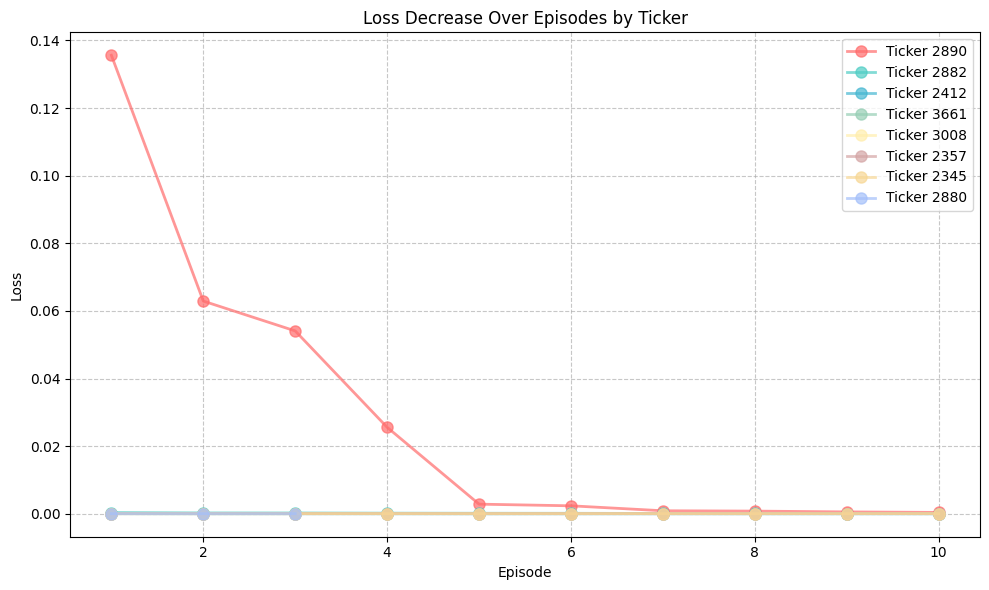

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import os

ckpt_dir = "/content/drive/MyDrive/Kai/envtest/checkpoints_large"
os.makedirs(ckpt_dir, exist_ok=True)
log_csv = os.path.join(ckpt_dir, "training_log.csv")

# Load the CSV file
df = pd.read_csv(log_csv)

# Filter out rows where loss is missing or invalid
df = df[df['ep_avg_loss'].notna() & df['ep_avg_loss'].apply(lambda x: isinstance(x, (int, float)))]

# Get unique tickers
tickers = df['ticker'].unique()

# Updated color palette with three additional colors
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEEAD', '#D4A5A5', '#F7D794', '#A3BFFA', '#C7CEEA']

# Create the line plot
plt.figure(figsize=(10, 6))

for i, ticker in enumerate(tickers):
    # Filter data for the current ticker
    ticker_data = df[df['ticker'] == ticker]
    # Plot loss over episodes with transparency and larger markers
    plt.plot(ticker_data['episode'], ticker_data['ep_avg_loss'],
             label=f'Ticker {ticker}', color=colors[i % len(colors)],
             marker='o', markersize=8, linewidth=2, alpha=0.7)

# Customize the plot
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.title('Loss Decrease Over Episodes by Ticker')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

# 畫單一個股

Starting to plot 2383 stock price and position status (from 2025)...
604.0 buy
492.0 buy
685.0 buy
452.0 sell
687.0 sell
928.0 sell


/tmp/ipython-input-2312891078.py:56: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged['position'] = merged['position'].fillna(method='ffill').fillna(0)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


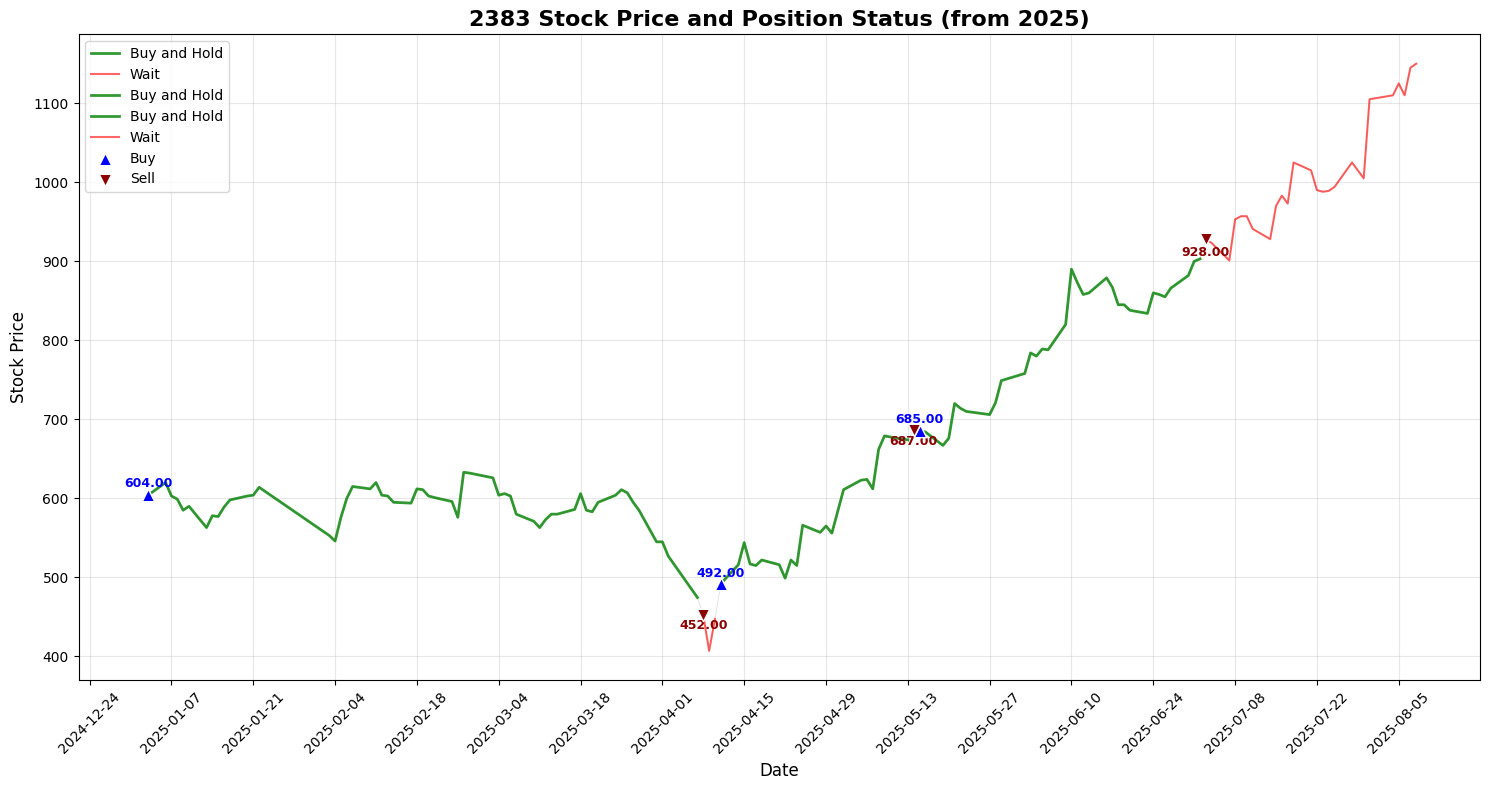


=== 2383 Position Statistics (from 2025) ===
Total trading days: 144
Holding days: 113 (78.5%)
Waiting days: 31 (21.5%)
Buy orders: 3
Sell orders: 3


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import List, Dict
import matplotlib.dates as mdates

# 解決中文顯示問題
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def plot_price_with_positions(ticker: str, trades: List[dict], stock_data: pd.DataFrame,
                                   figsize=(15, 8)):
    """
    Parameters:
    - ticker: 股票代碼
    - trades: 交易紀錄列表
    - stock_data: 包含股價資料的DataFrame，需要有 'date', 'close' 等欄位
    - figsize: 圖片大小
    """

    # 確保stock_data有正確的日期格式
    if 'date' not in stock_data.columns and 'Date' in stock_data.columns:
        stock_data = stock_data.rename(columns={'Date': 'date'})

    stock_data = stock_data.copy()
    stock_data['date'] = pd.to_datetime(stock_data['date'])
    stock_data = stock_data.sort_values('date').reset_index(drop=True)

    # 篩選2025年開始的資料
    stock_data = stock_data[stock_data['date'] >= '2025-01-01'].reset_index(drop=True)

    # 轉換trades為DataFrame，同樣篩選2025年開始的資料
    trades_df = []
    for i, trade in enumerate(trades):
        date = trade.get('observation_date') or trade.get('date')
        if date:
            trade_date = pd.to_datetime(date)
            if trade_date >= pd.Timestamp('2025-01-01'):
                trades_df.append({
                    'step': i,
                    'date': trade_date,
                    'event': trade.get('event', 'hold'),
                    'position': trade.get('position', 0),
                    'price': trade.get('event_price')
                })

    trades_df = pd.DataFrame(trades_df)

    # 合併股價和交易資料
    merged = pd.merge_asof(stock_data.sort_values('date'),
                          trades_df.sort_values('date'),
                          on='date',
                          direction='backward')

    # 填補position資料
    merged['position'] = merged['position'].fillna(method='ffill').fillna(0)

    # 創建持倉狀態：1表示持有，0表示觀望
    merged['holding'] = (merged['position'] > 0).astype(int)

    # 找出持倉狀態的變化點
    merged['position_change'] = merged['holding'].diff().fillna(0)

    fig, ax = plt.subplots(figsize=figsize)

    dates = merged['date'].values
    prices = merged['close'].values if 'close' in merged.columns else merged['Close'].values
    holdings = merged['holding'].values

    # 畫出基礎股價線（細線作為底圖）
    ax.plot(dates, prices, color='gray', linewidth=0.5, alpha=0.3)

    # 分段畫出不同顏色的股價線
    current_pos = 0
    i = 0

    while i < len(holdings):
        # 找到當前段的結束位置
        current_holding = holdings[i]
        start_idx = i

        # 找到持倉狀態改變的位置
        while i < len(holdings) and holdings[i] == current_holding:
            i += 1
        end_idx = i

        # 選擇顏色
        if current_holding == 1:  # 持有
            color = 'green'
            alpha = 0.8
            linewidth = 2.0
            label = 'Buy and Hold' if start_idx == 0 or holdings[start_idx-1] != 1 else None
        else:  # 觀望
            color = 'red'
            alpha = 0.6
            linewidth = 1.5
            label = 'Wait' if start_idx == 0 or holdings[start_idx-1] != 0 else None

        # 畫出這一段
        segment_dates = dates[start_idx:end_idx]
        segment_prices = prices[start_idx:end_idx]

        if len(segment_dates) > 1:
            ax.plot(segment_dates, segment_prices,
                   color=color, linewidth=linewidth, alpha=alpha, label=label)

    # 標記買賣點
    buy_trades = trades_df[trades_df['event'] == 'buy']
    sell_trades = trades_df[trades_df['event'].isin(['sell', 'force_sell', 'tp_sell', 'time_sell'])]

    for idx, trade in buy_trades.iterrows():
        trade_date = trade['date']
        price_idx = np.argmin(np.abs((merged['date'] - trade_date).dt.total_seconds()))
        price = prices[price_idx]
        ax.scatter(trade_date, price, marker='^', color='blue', s=80,
                   edgecolor='white', zorder=5,
                   label='Buy' if idx == buy_trades.index[0] else None)
        # 標上價格文字
        ax.text(trade_date, price * 1.01, f"{price:.2f}", color='blue',
                fontsize=9, ha='center', va='bottom', fontweight='bold')
        print(price, "buy")

    # 標記賣點
    for idx, trade in sell_trades.iterrows():
        trade_date = trade['date']
        price_idx = np.argmin(np.abs((merged['date'] - trade_date).dt.total_seconds()))
        price = prices[price_idx]
        ax.scatter(trade_date, price, marker='v', color='darkred', s=80,
                   edgecolor='white', zorder=5,
                   label='Sell' if idx == sell_trades.index[0] else None)
        print(price,"sell")
        # 標上價格文字
        ax.text(trade_date, price * 0.99, f"{price:.2f}", color='darkred',
                fontsize=9, ha='center', va='top', fontweight='bold')

    # 設置圖表格式
    ax.set_title(f'{ticker} Stock Price and Position Status (from 2025)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Stock Price', fontsize=12)
    ax.grid(True, alpha=0.3)

    # 設置日期格式
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)

    # 圖例
    ax.legend(loc='upper left', fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{ticker}_positions.png", dpi=300, transparent=True)
    plt.show()

    # 計算統計資訊
    total_days = len(merged)
    holding_days = np.sum(holdings)
    waiting_days = total_days - holding_days

    print(f"\n=== {ticker} Position Statistics (from 2025) ===")
    print(f"Total trading days: {total_days}")
    print(f"Holding days: {holding_days} ({holding_days/total_days*100:.1f}%)")
    print(f"Waiting days: {waiting_days} ({waiting_days/total_days*100:.1f}%)")
    print(f"Buy orders: {len(buy_trades)}")
    print(f"Sell orders: {len(sell_trades)}")

# 直接執行繪圖
stock = '2383'
if stock in all_results and stock in stock_data:
    print(f"Starting to plot {stock} stock price and position status (from 2025)...")
    plot_price_with_positions(stock, all_results[stock]['trades'], stock_data[stock])
else:
    if stock not in all_results:
        print(f"Cannot find {stock} trading data in all_results")
    if stock not in stock_data:
        print(f"Cannot find {stock} stock price data in stock_data")